# Optimisation de Tournées de Convoyeurs de Fonds
## Capacitated Vehicle Routing Problem with Forbidden Edges (CVRP-FE)

---

**Titre :** Projet de Recherche Opérationnelle — A3  
**Date :** Avril 2026
**Auteurs** :
- Guyon Clément 
- Cayrac Axel
- Boender Willem  
- Laurent Raphael  

---

### Le Problème Métier

Une société de transport de fonds doit organiser quotidiennement la
**collecte d'argent** dans un ensemble d'agences bancaires réparties
sur un territoire. Plusieurs **camions blindés** partent chaque matin
d'un **dépôt central** (le siège), visitent un sous-ensemble d'agences,
récupèrent les fonds, puis reviennent au dépôt.

**Enjeux :**
- Minimiser les **distances parcourues** (coûts de carburant et d'usure).
- Respecter la **capacité de stockage** de chaque camion.
- Éviter les **routes dangereuses** ou en travaux.
- Garantir que **chaque agence** est visitée au moins une fois.

---
# 1. Modélisation Formelle et Complexité Théorique

## 1.1 Définition du problème

Nous modélisons ce problème comme un **Capacitated Vehicle Routing Problem
with Forbidden Edges (CVRP-FE)**, une variante du CVRP classique où
certaines arêtes du graphe sont interdites.

### Données du problème

Le réseau routier est représenté par un graphe pondéré $G = (V, E)$ :

| Notation | Description |
|----------|-------------|
| $V = \{0, 1, \dots, n\}$ | Ensemble des sommets : $0$ = dépôt central, $\{1, \dots, n\}$ = agences bancaires |
| $N = \{1, 2, \dots, n\}$ | Ensemble des villes (agences) à visiter |
| $E \subseteq V \times V$ | Ensemble des arêtes (routes existantes) |
| $F \subset E$ | Ensemble des **arêtes interdites** (routes coupées ou dangereuses) A VOIR SI ON MET DANS F AVEC LA GOAT |
| $E' = E \setminus F$ | Ensemble des arêtes **utilisables** |
| $d_{ij}$ | Distance associée à l'arête $(i, j) \in E$ |
| $K = \{1, 2, \dots, k\}$ | Ensemble des camions blindés identiques |
| $Q$ | Capacité maximale de stockage d'un camion (en €) |
| $q_i$ | Montant d'argent à collecter à l'agence $i$ ($q_0 = 0$ pour le dépôt) |
| $u_i, u_j$ | Le niveau de remplissage du camion aux points $i$ et $j$ |

## 1.2 Variables de décision

$$x_{ij}^{k} = \begin{cases} 1 & \text{si le camion } k \text{ emprunte la route } (i,j) \\ 0 & \text{sinon} \end{cases} \quad \forall\, (i,j) \in E', \; \forall\, k \in K$$

$$u_i \geq 0 \quad \text{charge cumulée du camion lors de la visite du sommet } i$$

> **Note :** Les variables $u_i$ (dites de *Miller-Tucker-Zemlin*) servent
> à la fois à tracer la charge cumulée et à éliminer les sous-tours.

## 1.3 Fonction objectif

Minimiser la distance totale parcourue par l'ensemble de la flotte :

$$\min \sum_{k \in K} \sum_{(i,j) \in E'} d_{ij} \cdot x_{ij}^{k}$$

## 1.4 Contraintes

**C1 — Visite obligatoire :** Chaque agence doit être visitée au moins
une fois par exactement un camion.

$$\sum_{k \in K} \sum_{j \in V : (i,j) \in E'} x_{ij}^{k} = 1 \quad \forall\, i \in N$$

**C2 — Conservation du flux (continuité du trajet) :** Un camion qui
arrive dans une ville doit obligatoirement en repartir.

$$\sum_{j \in V : (j,i) \in E'} x_{ji}^{k} = \sum_{j \in V : (i,j) \in E'} x_{ij}^{k} \quad \forall\, i \in V, \; \forall\, k \in K$$

**C3 — Départ et retour au dépôt :** Chaque camion part du dépôt et y
revient.

$$\sum_{j \in N : (0,j) \in E'} x_{0j}^{k} \leq 1, \quad \sum_{j \in N : (j,0) \in E'} x_{j0}^{k} \leq 1 \quad \forall\, k \in K$$

**C4 — Respect de la capacité (plafond de collecte) :** La somme des
montants collectés sur une tournée ne dépasse pas la capacité $Q$.

$$\sum_{i \in N} q_i \cdot \sum_{j \in V : (i,j) \in E'} x_{ij}^{k} \leq Q \quad \forall\, k \in K$$

**C5 — Interdiction des routes à éviter :** Les arêtes appartenant à
l'ensemble $F$ sont strictement interdites.

$$x_{ij}^{k} = 0 \quad \forall\, (i,j) \in F, \; \forall\, k \in K$$

> En pratique, cette contrainte est implémentée en **supprimant** les arêtes
> de $F$ du graphe ou en leur attribuant un coût $+\infty$.

## 1.5 Complexité Théorique

### Le CVRP-FE est NP-Difficile

**Théorème :** Le CVRP avec arêtes interdites est NP-difficile.

**Preuve (par réduction depuis le TSP) :**

1. Le **Problème du Voyageur de Commerce (TSP)** est NP-difficile
   (Karp, 1972 [1]).
2. Toute instance du TSP sur $n$ villes peut être réduite en temps
   polynomial à une instance du CVRP-FE en posant :
   - $|K| = 1$ (un seul véhicule),
   - $Q = +\infty$ (capacité infinie),
   - $F = \emptyset$ (aucune arête interdite).
3. La solution optimale du CVRP-FE ainsi construit correspond exactement
   à la solution optimale du TSP.
4. Si le CVRP-FE admettait un algorithme polynomial, on pourrait résoudre
   le TSP en temps polynomial, ce qui contredirait l'hypothèse $P \neq NP$.

Par conséquent, $\text{TSP} \leq_p \text{CVRP-FE}$, et le CVRP-FE est
**NP-difficile**. $\blacksquare$

> **Remarque :** L'ajout des arêtes interdites rend le problème encore
> plus complexe en pratique, car il réduit l'espace des solutions
> réalisables et peut fragmenter le graphe.

### Références bibliographiques

1. **Dantzig, G. B. & Ramser, J. H.** (1959). *The Truck Dispatching
   Problem*. Management Science, 6(1), 80–91. — Article fondateur du VRP.
2. **Toth, P. & Vigo, D.** (2002). *The Vehicle Routing Problem*. SIAM
   Monographs on Discrete Mathematics and Applications. — Ouvrage de
   référence exhaustif.
3. **Karp, R. M.** (1972). *Reducibility Among Combinatorial Problems*.
   Complexity of Computer Computations, pp. 85–103. — Preuve de
   NP-complétude du TSP.
4. **Clarke, G. & Wright, J. W.** (1964). *Scheduling of Vehicles from a
   Central Depot to a Number of Delivery Points*. Operations Research,
   12(4), 568–581. — Heuristique d'épargne (Savings algorithm).
5. **Kirkpatrick, S., Gelatt, C. D. & Vecchi, M. P.** (1983). *Optimization
   by Simulated Annealing*. Science, 220(4598), 671–680.

---
# 2. Imports & Configuration

In [1]:
import math
import random
import time
import copy
import warnings
from dataclasses import dataclass, field
from typing import List, Tuple, Set, Dict, Optional

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.patches as mpatches

import json
import networkx as nx

from pulp import *
import pandas as pd

In [2]:

warnings.filterwarnings("ignore")

# Configuration globale de matplotlib pour des graphiques de qualité
plt.rcParams.update({
    "figure.figsize": (12, 8),
    "font.size": 12,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.family": "serif",
    "axes.facecolor": "#FAFAFA",
})

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

---
# 3. Générateur d'instances

Fonctions utilitaires pour créer les instances VRP.

In [3]:
# ==========================================
# 1. CHARGEMENT DU FICHIER JSON
# ==========================================
try:
    with open('villes.json', 'r', encoding='utf-8') as fichier:
        VILLES_SOURCE = json.load(fichier)
    print(f"✅ {len(VILLES_SOURCE)} villes chargées avec succès depuis 'villes.json'.")
except FileNotFoundError:
    print("❌ Erreur : Le fichier 'villes.json' est introuvable.")
    print("Vérifiez qu'il est bien enregistré dans le même dossier que ce Notebook.")
    VILLES_SOURCE = [] # Liste vide pour éviter de faire planter la suite

✅ 100 villes chargées avec succès depuis 'villes.json'.


In [4]:
def generate_synthetic_cities(N, x_max=100, y_max=100):
    """
    Generates a list of N cities with random (x, y) coordinates.
    Index 0 is always considered the Dépôt.
    """
    cities = []
    
    for i in range(N):
        city = {
            'id': i,
            'nom': f"Dépôt" if i == 0 else f"Ville_{i}",
            'x': round(random.uniform(0, x_max), 2),
            'y': round(random.uniform(0, y_max), 2)
        }
        cities.append(city)
        
    return cities

In [5]:
def create_vrp_city_network(N, X=None, blocking_rate=0.1, city_list=None):
    """
    Creates a connected graph.
    X: total number of routes (defaults to N*3).
    blocking_rate: percentage (0.0 to 1.0) of routes with an INF weight.
    """
    INF = float('inf')
    if X is None:
        X = N * 3
    
    max_possible_routes = (N * (N - 1)) // 2
    X = min(X, max_possible_routes)

    depot = next(city for city in city_list if city['id'] == 0)
    
    autres_villes = [city for city in city_list if city['id'] != 0]
    
    villes_choisies = random.sample(autres_villes, N - 1)
    
    selected_cities = [depot] + villes_choisies

    weight_matrix = np.full((N, N), None) 

    all_distances = []
    for i in range(N):
        for j in range(i + 1, N):
            v1, v2 = selected_cities[i], selected_cities[j]
            dist = np.sqrt((v2['x'] - v1['x'])**2 + (v2['y'] - v1['y'])**2)
            all_distances.append((dist, i, j))
    
    all_distances.sort(key=lambda x: x[0])

    final_routes = []
    parent = list(range(N))
    def find(i):
        if parent[i] == i: return i
        return find(parent[i])

    def union(i, j):
        root_i, root_j = find(i), find(j)
        if root_i != root_j:
            parent[root_i] = root_j
            return True
        return False

    for dist, i, j in all_distances:
        if union(i, j):
            final_routes.append((dist, i, j))
        if len(final_routes) == N - 1:
            break

    for d, i, j in all_distances:
        if len(final_routes) >= X:
            break
        if not any((i == r[1] and j == r[2]) for r in final_routes):
            final_routes.append((d, i, j))

    blocked_count = int(len(final_routes) * blocking_rate)
    blocked_indices = random.sample(range(len(final_routes)), blocked_count)
    
    for idx, (dist, i, j) in enumerate(final_routes):
        weight = INF if idx in blocked_indices else dist
        weight_matrix[i][j] = weight
        weight_matrix[j][i] = weight
        
    return selected_cities, weight_matrix

In [6]:
def assign_city_data(cities, nb_to_visit=None, demand_range=(40, 100)):
    """
    Assigns a demand to exactly 'nb_to_visit' agencies.
    The depot (index 0) always remains at 0.
    """
    N = len(cities)
    if nb_to_visit == None :
        nb_to_visit = int(N * 0.25)
    nb_to_visit = min(nb_to_visit, N - 1)
    
    demands = {i: 0 for i in range(N)}
    
    collection_indices = random.sample(range(1, N), nb_to_visit)
    
    for idx in collection_indices:
        demands[idx] = random.randint(demand_range[0], demand_range[1])
            
    return list(demands.items())

---
# 4. Fonctions de visualisation

In [7]:
def display_vrp_chart(cities_N, weight_matrix, cities_data, prob=None, x=None, K=None):
    """
    Displays the VRP network. 
    If prob, x, and K are provided, also displays the optimized truck routes.
    """
    NUMBER_OF_CITIES_N = len(cities_N)
    INF_THRESHOLD = 1e8

    # --- 1. Preparation of Roles ---
    collection_pts = [idx for idx, q_i in cities_data if q_i > 0 and idx != 0]
    transit_pts = [idx for idx, q_i in cities_data if q_i == 0 and idx != 0]
    q = {idx: q_i for idx, q_i in cities_data}

    # --- 2. Graph Construction ---
    G = nx.DiGraph() # DiGraph for route arrows
    pos = {i: (v['x'], v['y']) for i, v in enumerate(cities_N)}
    city_names = {i: v['nom'] for i, v in enumerate(cities_N)}
    
    active_routes = []
    blocked_routes = []
    weight_labels = {}

    for i in range(NUMBER_OF_CITIES_N):
        for j in range(NUMBER_OF_CITIES_N):
            if i != j:
                p = weight_matrix[i][j]
                if p is not None:
                    if p >= INF_THRESHOLD:
                        if i < j: blocked_routes.append((i, j))
                    else:
                        if i < j: 
                            active_routes.append((i, j))
                            weight_labels[(i, j)] = f"{float(p):.1f}"

    # --- 3. Visualization ---
    plt.figure(figsize=(16, 11))

    # A. Nodes: DEPOT, COLLECTION, TRANSIT
    nx.draw_networkx_nodes(G, pos, nodelist=[0], node_color='#f39c12', 
                           node_size=1100, edgecolors='black', linewidths=2)
    nx.draw_networkx_nodes(G, pos, nodelist=collection_pts, node_color='#2ecc71', 
                           node_size=800, edgecolors='black', alpha=0.9)
    nx.draw_networkx_nodes(G, pos, nodelist=transit_pts, node_color='#bdc3c7', 
                           node_size=600, edgecolors='black', alpha=0.7)

    # B. Base edges: BLOCKED and ACTIVE
    nx.draw_networkx_edges(G, pos, edgelist=blocked_routes, edge_color='#e74c3c', 
                           width=3, style='--', alpha=0.4)
    nx.draw_networkx_edges(G, pos, edgelist=active_routes, edge_color='#2c3e50', 
                           width=1.5, alpha=0.2) # Subtle to let truck routes show through

    # C. TRUCK ROUTES (If solver has finished)
    truck_colors = ['#3498db', '#9b59b6', '#e67e22', '#1abc9c', '#e74c3c']
    route_handles = []
    
    if prob and x and K and prob.status == 1:
        for k in K:
            segments = [(i, j) for i in range(NUMBER_OF_CITIES_N) for j in range(NUMBER_OF_CITIES_N)
                        if value(x[k][i][j]) is not None and value(x[k][i][j]) > 0.9]
            if segments:
                color = truck_colors[k % len(truck_colors)]
                nx.draw_networkx_edges(G, pos, edgelist=segments, edge_color=color, 
                                       width=4, arrowstyle='-|>', arrowsize=20)
                route_handles.append(mpatches.Patch(color=color, label=f'Trajet Camion {k}'))

    # D. Labels: Cities and Weights
    city_labels = {idx: f"{city_names[idx]}\n({q_i}€)" if q_i > 0 else city_names[idx] 
                     for idx, q_i in cities_data}
    
    label_pos = {i: (coords[0], coords[1] + 0.4) for i, coords in pos.items()}
    nx.draw_networkx_labels(G, label_pos, labels=city_labels, font_size=9, font_weight='bold',
                            bbox=dict(facecolor='white', edgecolor='none', alpha=0.6, boxstyle='round,pad=0.2'))

    nx.draw_networkx_edge_labels(G, pos, edge_labels=weight_labels, font_size=7, 
                                 font_color='#2980b9', font_weight='bold', alpha=0.5)

    # E. Title and Legend
    status_str = " (Résultat Optimisé)" if (prob and prob.status == 1) else " (Carte Initiale)"
    plt.title(f"Visualisation VRP{status_str} : {len(collection_pts)} Agences", fontsize=15, pad=20)
    
    base_legend = [
        mpatches.Patch(color='#f39c12', label='Dépôt (0)'),
        mpatches.Patch(color='#2ecc71', label='Collecte (q_i > 0)'),
        mpatches.Patch(color='#bdc3c7', label='Transit (q_i = 0)'),
        mpatches.Patch(color='#2c3e50', label='Route Active'),
        mpatches.Patch(color='#e74c3c', label='Route Bloquée (∞)', linestyle='--')
    ]
    
    plt.legend(handles=base_legend + route_handles, loc='upper left', fontsize=9, frameon=True)

    plt.axis('off')
    plt.tight_layout()
    plt.show()

In [8]:
def visualize_final_vrp(cities_N, weight_matrix, cities_data, routes, title="Solution VRP", real_dist=None):
    """
    Universal function to display any VRP solution.
    'routes' must be a list of index lists: [[0, 1, 2, 0], [0, 3, 0], ...]
    """
    NUMBER_OF_CITIES_N = len(cities_N)
    INF_THRESHOLD = 1e8

    # --- 1. Data Preparation ---
    collection_pts = [idx for idx, q_i in cities_data if q_i > 0 and idx != 0]
    transit_pts = [idx for idx, q_i in cities_data if q_i == 0 and idx != 0]
    q = {idx: q_i for idx, q_i in cities_data}
    
    # Coordinates and names
    pos = {i: (v['x'], v['y']) for i, v in enumerate(cities_N)}
    city_names = {i: v['nom'] for i, v in enumerate(cities_N)}

    # --- 2. Base Graph Construction (Infrastructure) ---
    G = nx.DiGraph()
    active_routes = []
    blocked_routes = []
    weight_labels = {}

    for i in range(NUMBER_OF_CITIES_N):
        for j in range(i + 1, NUMBER_OF_CITIES_N):
            p = weight_matrix[i][j]
            if p is not None:
                if p >= INF_THRESHOLD:
                    blocked_routes.append((i, j))
                else:
                    active_routes.append((i, j))
                    weight_labels[(i, j)] = f"{float(p):.1f}"

    # --- 3. Chart Drawing ---
    plt.figure(figsize=(16, 11))

    # A. Nodes: DEPOT, COLLECTION, TRANSIT
    nx.draw_networkx_nodes(G, pos, nodelist=[0], node_color='#f39c12', 
                           node_size=1100, edgecolors='black', linewidths=2)
    nx.draw_networkx_nodes(G, pos, nodelist=collection_pts, node_color='#2ecc71', 
                           node_size=800, edgecolors='black', alpha=0.9)
    nx.draw_networkx_nodes(G, pos, nodelist=transit_pts, node_color='#bdc3c7', 
                           node_size=600, edgecolors='black', alpha=0.7)

    # B. Infrastructure Edges (Gray and Red)
    nx.draw_networkx_edges(G, pos, edgelist=blocked_routes, edge_color='#e74c3c', 
                           width=2, style='--', alpha=0.4)
    nx.draw_networkx_edges(G, pos, edgelist=active_routes, edge_color='#2c3e50', 
                           width=1, alpha=0.15)

    # C. TRUCK ROUTES (The routes passed as parameters)
    truck_colors = ['#3498db', '#9b59b6', '#e67e22', '#1abc9c', '#e74c3c', '#d35400', '#27ae60']
    route_handles = []
    
    # Pre-calculate real_dist if not provided
    if real_dist is None:
        V = list(range(len(cities_N)))
        real_dist, _ = calculate_all_paths(V, weight_matrix)

    total_distance = 0
    for k, route in enumerate(routes):
        # Create segments (i, j) from the list [0, 5, 3, 0]
        segments = [(route[i], route[i+1]) for i in range(len(route)-1)]

        # Calculate distance via real_dist (Floyd-Warshall) — consistent with calculate_total_distance
        route_dist = sum(real_dist[route[i]][route[i+1]] for i in range(len(route)-1))
        if route_dist >= 1e8:
            route_dist = 0  # invalid route, ignore
        total_distance += route_dist
        
        if segments:
            color = truck_colors[k % len(truck_colors)]
            nx.draw_networkx_edges(G, pos, edgelist=segments, edge_color=color, 
                                   width=4, arrowstyle='-|>', arrowsize=25)
            route_handles.append(mpatches.Patch(color=color, label=f'Camion {k+1} ({route_dist:.1f} km)'))

    # D. Labels: Cities and Weights
    city_labels = {idx: f"{city_names[idx]}\n({q_i}€)" if q_i > 0 else city_names[idx] 
                     for idx, q_i in cities_data}
    
    label_pos = {i: (coords[0], coords[1] + 0.5) for i, coords in pos.items()}
    nx.draw_networkx_labels(G, label_pos, labels=city_labels, font_size=9, font_weight='bold',
                            bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, boxstyle='round,pad=0.2'))

    # E. Title and Legend
    plt.title(f"{title}\nDistance Totale : {total_distance:.2f} km | {len(routes)} Camions", fontsize=16, pad=20)
    
    base_legend = [
        mpatches.Patch(color='#f39c12', label='Dépôt (0)'),
        mpatches.Patch(color='#2ecc71', label='Collecte (q_i > 0)'),
        mpatches.Patch(color='#bdc3c7', label='Transit (q_i = 0)'),
        mpatches.Patch(color='#e74c3c', label='Route Bloquée (∞)', linestyle='--')
    ]
    
    plt.legend(handles=base_legend + route_handles, loc='upper left', fontsize=9, frameon=True, shadow=True)

    plt.axis('off')
    plt.tight_layout()
    plt.show()

---
# 5. Solveur Exact — Programmation Linéaire (PuLP)

Résolution exacte du CVRP sur petites instances (N ≤ 20) via un modèle ILP.
Sert de référence de qualité pour les heuristiques.

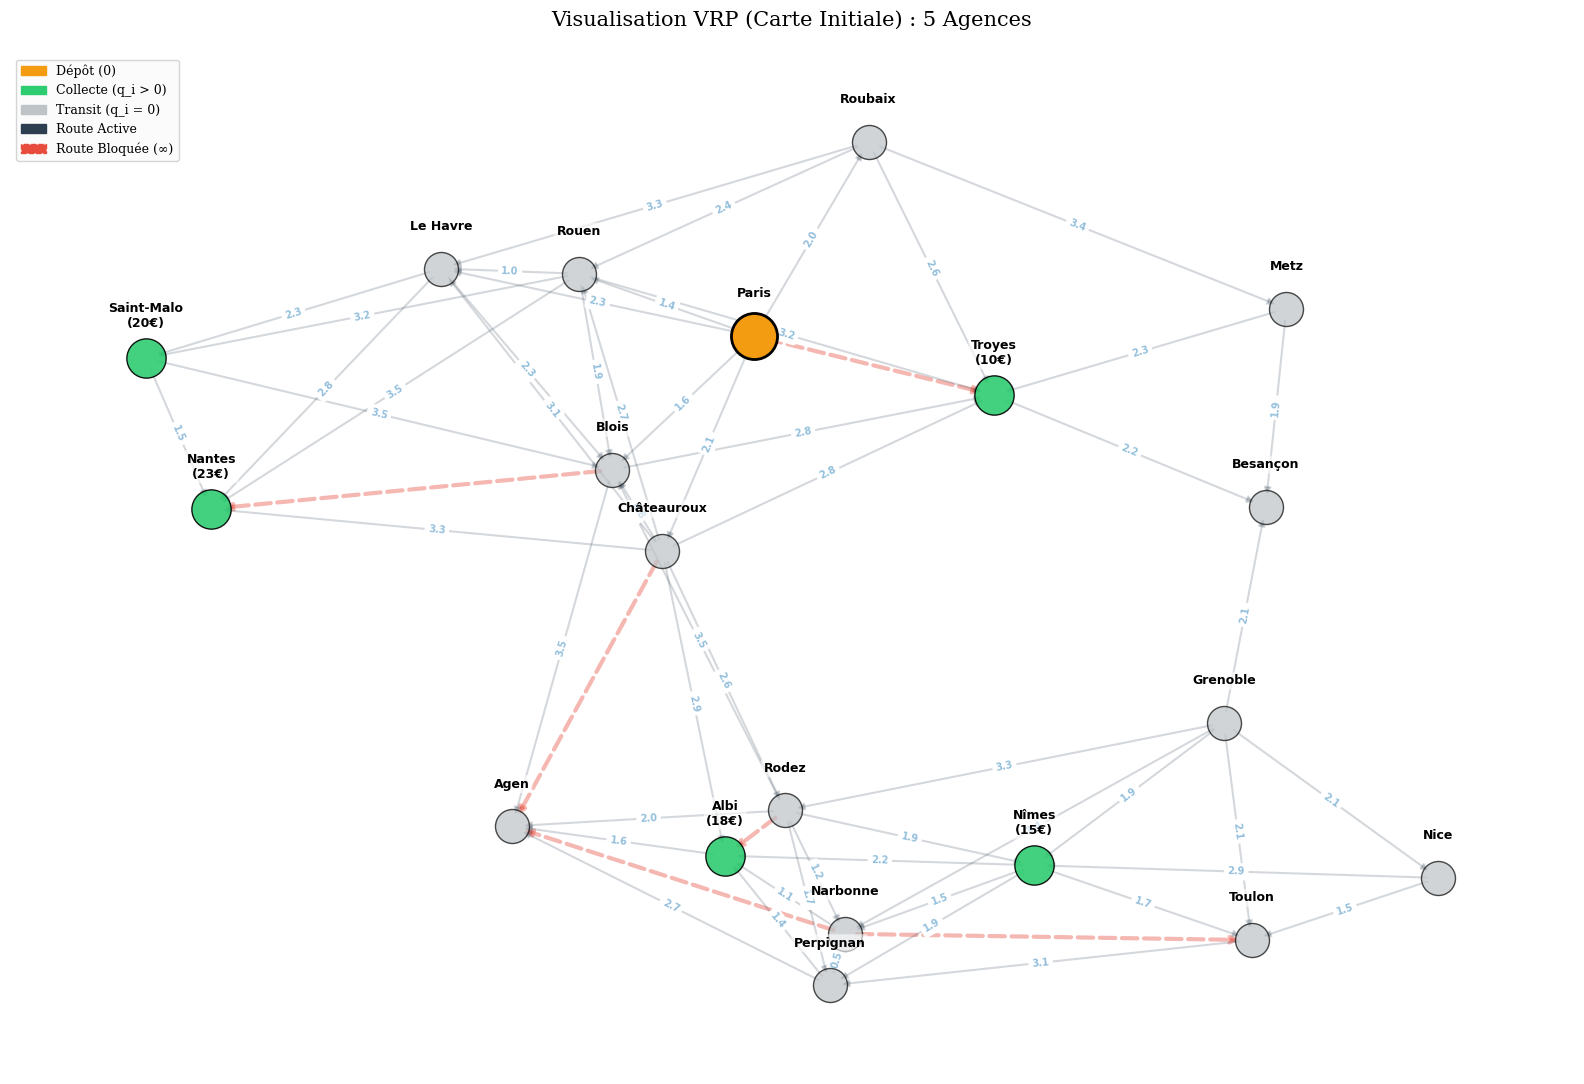

In [9]:
cities_N, weight_matrix = create_vrp_city_network(20, city_list=VILLES_SOURCE)
cities_data = assign_city_data(cities_N, demand_range=(10,25))

display_vrp_chart(cities_N, weight_matrix, cities_data)

V = [idx for idx, q_i in cities_data] 
N = [idx for idx, q_i in cities_data if q_i > 0 and idx != 0]
K = range(5) 
Q = 100
q = {idx: q_i for idx, q_i in cities_data} 

E_prime = []
F = []
for i in V:
    for j in V:
        if i != j and weight_matrix[i][j] is not None:
            if weight_matrix[i][j] < 1e8:
                E_prime.append((i, j))
            else:
                F.append((i, j))


In [10]:
prob = LpProblem("CVRP_Final_Conveyor", LpMinimize)

x = LpVariable.dicts("x", (K, V, V), cat=LpBinary)
u = LpVariable.dicts("u", V, lowBound=0, upBound=Q, cat=LpContinuous)

prob += lpSum(weight_matrix[i][j] * x[k][i][j] for k in K for (i, j) in E_prime if weight_matrix[i][j] is not None)

In [11]:
# C1 — Mandatory visit: Each agency in N visited once
for i in N:
    prob += lpSum(x[k][i][j] for k in K for j in V if (i, j) in E_prime) == 1

# C2 — Flow conservation: What enters must leave
for k in K:
    for i in V:
        prob += lpSum(x[k][j][i] for j in V if (j, i) in E_prime) == \
                lpSum(x[k][i][j] for j in V if (i, j) in E_prime)

# C3 — Departure and return to depot (0)
for k in K:
    prob += lpSum(x[k][0][j] for j in V if (0, j) in E_prime) <= 1
    prob += lpSum(x[k][j][0] for j in V if (j, 0) in E_prime) <= 1

# C4 — Capacity Q compliance
for k in K:
    prob += lpSum(q[i] * lpSum(x[k][i][j] for j in V if (i, j) in E_prime) for i in N) <= Q

# C5 — Sub-tour elimination (MTZ)
for k in K:
    for i in V:
        for j in V:
            if i != 0 and j != 0 and i != j and (i, j) in E_prime:
                # The max(1, q[j]) forces the return to depot even if collection=0
                prob += u[i] - u[j] + Q * x[k][i][j] <= Q - max(1, q[j])

# C6 — Prohibition of routes (Set F)
for (i, j) in F:
    for k in K:
        prob += x[k][i][j] == 0

In [12]:
prob.solve(PULP_CBC_CMD(msg=1, gapRel=0.05))

print(f"Statut final : {LpStatus[prob.status]}")
if value(prob.objective):
    print(f"Distance totale optimisée : {value(prob.objective):.2f} km")

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /home/clement/test/venv/lib/python3.12/site-packages/pulp/apis/../solverdir/cbc/linux/i64/cbc /tmp/2381963813074ed388d0697e79393fe1-pulp.mps -ratio 0.05 -timeMode elapsed -branch -printingOptions all -solution /tmp/2381963813074ed388d0697e79393fe1-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 675 COLUMNS
At line 5336 RHS
At line 6007 BOUNDS
At line 6627 ENDATA
Problem MODEL has 670 rows, 619 columns and 2920 elements
Coin0008I MODEL read with 0 errors
ratioGap was changed from 0 to 0.05
Option for timeMode changed from cpu to elapsed
Continuous objective value is 11.8931 - 0.00 seconds
Cgl0002I 60 variables fixed
Cgl0003I 0 fixed, 0 tightened bounds, 130 strengthened rows, 0 substitutions
Cgl0003I 0 fixed, 0 tightened bounds, 130 strengthened rows, 0 substitutions
Cgl0003I 0 fixed, 0 tightened bounds, 130 strengthened rows, 0 substitutions
Cgl0003I 0 fixed, 0 t

---
# 6. Utilitaires communs aux heuristiques


C'est la fonction d'évaluation de la fitness (ou coût total). Elle calcule la longueur totale parcourue par l'ensemble de la flotte de véhicules.

- Fonctionnement : Pour chaque route, elle additionne les distances entre chaque point de passage (du dépôt au premier client, entre les clients, et le retour au dépôt).
- Indicateur de Performance : C'est la valeur que nous cherchons à minimiser. Elle permet de comparer objectivement l'efficacité d'un algorithme par rapport à un autre (ex: Nearest Neighbor vs ACO).

In [13]:
def calculate_total_distance(routes, real_dist):
    """Calculates the total cost of a solution."""
    total = 0
    for r in routes:
        total += sum(real_dist[r[i]][r[i+1]] for i in range(len(r)-1))
    return total


Cette fonction implémente l'algorithme de Floyd-Warshall. Elle permet de transformer un graphe incomplet en une matrice de distances complète.

- Entrée : L'ensemble des sommets et la matrice d'adjacence initiale (avec des poids INF pour les routes inexistantes).
- Sortie :
    - dist : Une matrice de distances minimales entre chaque paire de noeuds.
    - next_node : Une matrice de "successeurs" utilisée pour reconstruire les chemins physiques.

In [14]:
def calculate_all_paths(V, weight_matrix):
    INF = 1e8
    n = len(V)

    dist = [[INF] * n for _ in range(n)]
    next_node = [[None] * n for _ in range(n)]

    for i in V:
        dist[i][i] = 0
        for j in V:
            if i == j:
                continue
            p = weight_matrix[i][j]
            if p is not None and p < INF:
                dist[i][j] = p
                next_node[i][j] = j

    for k in V:
        for i in V:
            for j in V:
                if dist[i][k] + dist[k][j] < dist[i][j]:
                    dist[i][j] = dist[i][k] + dist[k][j]
                    next_node[i][j] = next_node[i][k]

    return dist, next_node

Une fois qu'un algorithme (ACO, VNS, Clarke-Wright) a trouvé une séquence optimale de clients à visiter, cette fonction "déplie" les segments entre chaque client.

- Rôle : Si l'algorithme décide d'aller du client $A$ au client $B$, mais que le chemin le plus court passe par un point de transit $K$, cette fonction insère automatiquement $K$ dans la route finale.
- Utilité : Garantit que la solution finale est réaliste et respecte la topologie réelle du réseau routier.

In [15]:
def expand_solution(routes, next_node):
    """
    Prend une solution (liste de routes) et insère les points de passage
    intermédiaires pour chaque segment.
    
    Args:
        routes: List[List[int]] - Exemple: [[0, 3, 1, 0], [0, 2, 0]]
        next_node: Matrice des successeurs de Floyd-Warshall
        
    Returns:
        List[List[int]] - Les routes complètes avec tous les noeuds physiques
    """
    full_solution = []
    
    for route in routes:
        if not route:
            continue
            
        expanded_route = [route[0]]
        
        for i in range(len(route) - 1):
            u = route[i]
            v = route[i+1]
            
            if u == v:
                continue
                
            curr = u
            while curr != v:
                curr = next_node[curr][v]
                if curr is None:
                    # Sécurité si aucun chemin n'existe
                    break
                expanded_route.append(curr)
                
        full_solution.append(expanded_route)
        
    return full_solution


Cette fonction est un outil de diagnostic. Elle ne se contente pas de dire si une solution est "bonne", elle vérifie si elle est réalisable (feasible) selon les règles strictes du transport de marchandises.

Fonctionnement détaillé :
La fonction passe la solution au crible de quatre tests fondamentaux :

- Contrainte de Capacité (Charge) :

    - Pour chaque route, la somme des demandes des clients visités est calculée.
    - Si cette somme dépasse la capacité maximale du véhicule ($Q$), la solution est déclarée invalide. C'est la contrainte la plus souvent violée par les algorithmes de recherche locale.
- Contrainte d'Unicité (Couverture) :

    - La fonction vérifie que chaque client (hors dépôt) apparaît exactement une seule fois dans l'ensemble des tournées.
    - Elle détecte ainsi les clients oubliés ou, au contraire, les clients servis deux fois par erreur.
- Structure des Routes (Dépôt) :

    - Chaque tournée doit impérativement commencer et se terminer au point central (le Dépôt, généralement l'indice 0).
    - Elle vérifie que le véhicule revient bien à sa base pour recharger ou terminer son service.
- Détection de Sous-Tours Invalides :

    - Elle s'assure qu'il n'y a pas de routes vides ou de boucles incohérentes qui ne passeraient pas par le dépôt.

In [16]:
def verify_solution(routes, weight_matrix, cities_data, Q,
                    route_type='logical', real_dist=None):
    """
    Verifies that a VRP solution is feasible.

    Parameters
    ----------
    routes       : list of routes [[0, a, b, 0], ...]
    weight_matrix: adjacency matrix (None or ≥1e8 = non-existent edge)
    cities_data  : list (idx, demand) of all nodes
    Q            : max truck capacity
    route_type   : 'logical'  → verifies via real_dist (Floyd-Warshall)
                   'physical' → verifies each direct edge in weight_matrix

    BUSINESS RULE: a truck can pass through a node multiple times as a
    transit intersection (physical route). Only clients (demand > 0)
    must be COLLECTED exactly once.
    → In physical mode, transit duplicates are not checked.
    → In logical mode, each client must appear only once.
    """
    INF = 1e8
    demands = {idx: q_i for idx, q_i in cities_data}
    depot = 0
    expected_clients = {idx for idx, q_i in cities_data if q_i > 0}

    errors = []
    warnings = []

    for k, route in enumerate(routes):
        label = f"Route {k+1}"

        if len(route) < 2:
            errors.append(f"{label} {route}: too short (< 2 nodes)")
            continue
        if route[0] != depot:
            errors.append(f"{label}: does not start at the depot (node 0)")
        if route[-1] != depot:
            errors.append(f"{label}: does not end at the depot (node 0)")

        for i in range(len(route) - 1):
            u, v = route[i], route[i + 1]
            if route_type == 'physical':
                weight = weight_matrix[u][v]
                if weight is None or weight >= INF:
                    errors.append(
                        f"{label}: direct edge ({u}→{v}) NON-EXISTENT in the network"
                    )
            else:
                if real_dist is None:
                    errors.append("real_dist required for route_type='logical'")
                    break
                if real_dist[u][v] >= INF:
                    errors.append(
                        f"{label}: no path between {u} and {v} (distance = ∞)"
                    )

        load = sum(demands.get(n, 0) for n in route if n != depot)
        if load > Q:
            errors.append(
                f"{label}: overload! load={load} > Q={Q}"
            )
        elif load == 0:
            warnings.append(f"{label}: no client collected (empty route)")

    if route_type == 'logical':
        all_nodes = [n for route in routes for n in route if n != depot]
        counter = {}
        for n in all_nodes:
            counter[n] = counter.get(n, 0) + 1

        for n, cnt in counter.items():
            if cnt > 1 and demands.get(n, 0) > 0:
                errors.append(
                    f"Client {n} collected {cnt} times — duplicate forbidden in logical route"
                )

        missing = expected_clients - set(all_nodes)
        if missing:
            errors.append(f"Clients not visited: {sorted(missing)}")

    else:
        collections_per_route = []
        for route in routes:
            stops = [n for n in route if n != depot and demands.get(n, 0) > 0]
            collections_per_route.append(set(stops))

        seen = {}
        for k, stops in enumerate(collections_per_route):
            for n in stops:
                if n in seen:
                    errors.append(
                        f"Client {n} potentially collected in Route {seen[n]+1} "
                        f"AND Route {k+1} (check physical route)"
                    )
                else:
                    seen[n] = k

        missing = expected_clients - set(seen.keys())
        if missing:
            warnings.append(
                f"Clients absent from physical routes: {sorted(missing)} "
                f"(may be normal if they are transit nodes)"
            )

    is_valid = len(errors) == 0
    return {'valide': is_valid, 'erreurs': errors, 'warnings': warnings}

In [17]:
def display_verification(routes, weight_matrix, cities_data, Q,
                         route_type='logical', real_dist=None, label='Solution'):
    """Calls verify_solution and displays the result in a readable way."""
    res = verify_solution(routes, weight_matrix, cities_data, Q,
                          route_type=route_type, real_dist=real_dist)
    status = '✅ VALID' if res['valide'] else '❌ INVALID'
    print(f"  {label:30s} {status}", end="")
    if res['erreurs']:
        print(f"  ({len(res['erreurs'])} error(s))")
        for e in res['erreurs']:
            print(f"    ✗ {e}")
    elif res['warnings']:
        print(f"  ({len(res['warnings'])} warning(s))")
        for w in res['warnings']:
            print(f"    ⚠ {w}")
    else:
        print()
    return res['valide']

---
# 7. Algorithmes

Six algorithmes, du plus simple au plus élaboré :

| # | Algorithme | Type |
|---|-----------|------|
| 1 | **Nearest Neighbor** | Construction greedy (baseline faible) |
| 2 | **Clarke & Wright** | Construction par économies (heuristique classique) |
| 3 | **Or-Opt** | Amélioration locale déterministe |
| 4 | **Recuit Simulé v2** | Métaheuristique stochastique |
| 5 | **Recherche Tabou** | Métaheuristique déterministe à mémoire |
| 6 | **Colonies de Fourmis** | Métaheuristique stochastique |

## 7.1 Nearest Neighbor (baseline)


In [18]:
import time, math, copy, random
import numpy as np, pandas as pd, matplotlib.pyplot as plt

def nearest_neighbor_vrp(cities_N, weight_matrix, cities_data, Q=100):
    """
    Builds routes by always visiting the nearest unvisited client
    that respects the capacity constraint. Restarts at the depot when the route is full.
    Deliberately simpler (and less efficient) than Clarke & Wright.
    """
    V = list(range(len(cities_N)))
    real_dist, next_node_i = calculate_all_paths(V, weight_matrix)
    demands = {idx: q_i for idx, q_i in cities_data}
    depot = 0

    clients = [idx for idx, q_i in cities_data if q_i > 0]
    unvisited = set(clients)
    routes = []
    
    truck_id = 1

    while unvisited:
        route = [depot]
        load = 0
        current = depot
        progress = False
        
        route_str = [f"{depot} (cap: {Q})"]

        while True:
            candidates = [
                (real_dist[current][c], c)
                for c in unvisited
                if real_dist[current][c] < 1e8 and load + demands[c] <= Q
            ]
            if not candidates:
                break
            _, next_node = min(candidates)
            route.append(next_node)
            load += demands[next_node]
            unvisited.remove(next_node)
            current = next_node
            progress = True
            
            route_str.append(f"{next_node} (cap: {Q - load})")

        route.append(depot)
        route_str.append(f"{depot} (cap: {Q - load})")

        if progress:
            routes.append(route)
            truck_id += 1
        else:
            first = min(
                unvisited,
                key=lambda c: real_dist[depot][c]
            )
            routes.append([depot, first, depot])
            unvisited.remove(first)
            
            forced_load = demands[first]
            rem_cap = Q - forced_load
            truck_id += 1
    #best_sol_reel = expand_solution(routes, next_node_i)
    return routes

## 7.2 Clarke & Wright

L'algorithme de Clarke & Wright (heuristique des économies) optimise un parcours en fusionnant itérativement des routes pour minimiser la distance totale. 

Partant d'une solution initiale où un véhicule dédié fait l'aller-retour entre le dépôt et chaque sommet, il calcule l'économie de distance obtenue en reliant directement deux sommets $i$ et $j$ via la formule $S_{ij} = d_{dépôt, i} + d_{dépôt, j} - d_{i, j}$. Si cette fusion génère une économie et que la charge combinée respecte la capacité maximale du véhicule, les deux routes sont assemblées ; dans le cas contraire, la liaison est ignorée et l'algorithme évalue les autres combinaisons possibles.


In [19]:
def clarke_wright(cities_N, weight_matrix, cities_data, Q=100):
    """
    Clarke & Wright Savings Heuristic.

    Returns LOGICAL routes: [depot, client1, client2, ..., depot].
    Each client appears only once in the set of routes.
    Uses real_dist (Floyd-Warshall) for savings and distances.
    """
    depot = 0
    V = list(range(len(cities_N)))

    real_dist, _ = calculate_all_paths(V, weight_matrix)

    demands = {idx: q_i for idx, q_i in cities_data}
    agencies = [idx for idx, q_i in cities_data if q_i > 0 and idx != depot]

    accessible_agencies = [a for a in agencies if real_dist[depot][a] < 1e8]

    routes = [[depot, i, depot] for i in accessible_agencies]

    savings = []
    for idx_i, i in enumerate(accessible_agencies):
        for j in accessible_agencies[idx_i + 1:]:
            if real_dist[i][j] < 1e8:
                s = real_dist[depot][i] + real_dist[depot][j] - real_dist[i][j]
                if s > 0:
                    savings.append((s, i, j))
    savings.sort(key=lambda x: x[0], reverse=True)

    for s, i, j in savings:
        route_i = next((r for r in routes if i in r), None)
        route_j = next((r for r in routes if j in r), None)

        if not route_i or not route_j or route_i is route_j:
            continue

        is_i_end = (route_i[1] == i or route_i[-2] == i)
        is_j_end = (route_j[1] == j or route_j[-2] == j)
        if not (is_i_end and is_j_end):
            continue

        load = sum(demands[n] for n in route_i + route_j if n != depot)
        if load > Q:
            continue

        if route_i[1] == i:
            route_i = route_i[::-1]
        part_i = route_i[:-1]

        if route_j[-2] == j:
            route_j = route_j[::-1]
        part_j = route_j[1:]

        routes.remove(route_i if route_i in routes else route_i[::-1])
        routes.remove(route_j if route_j in routes else route_j[::-1])
        routes.append(part_i + part_j)

    #best_sol_reel = expand_solution(routes, next_node)
    return routes

## 7.3 Or-Opt

L'algorithme **Or-Opt** est une heuristique d'amélioration locale qui cherche à optimiser une tournée existante en déplaçant des segments de sommets. 

Il consiste à extraire successivement des séquences de $k$ sommets consécutifs ($k \in \{3, 2, 1\}$) pour tenter de les réinsérer à une autre position dans le parcours. Le mouvement est validé si la variation de distance totale est négative ($\Delta d < 0$). Ce processus est répété de manière itérative jusqu'à ce qu'aucune réinsertion de segment ne permette plus de réduire la longueur du trajet, atteignant ainsi un optimum local.


In [20]:
def or_opt(cities_N, weight_matrix, cities_data, solution, Q=100, chain_sizes=(1, 2, 3)):
    """
    Or-Opt: local improvement by moving chains of clients.
    - chain_sizes: lengths of chains to test (defaults to 1, 2, 3)
    - Iterates until no further improvement is found (convergence)
    - Works on LOGICAL routes (depot + clients only)
    """
    V = list(range(len(cities_N)))
    real_dist, _ = calculate_all_paths(V, weight_matrix)
    demands = {idx: q_i for idx, q_i in cities_data}

    sol = [list(r) for r in solution]
    best_score = calculate_total_distance(sol, real_dist)
    improved = True

    while improved:
        improved = False

        for k in chain_sizes:
            for r1 in range(len(sol)):
                clients_r1 = [n for n in sol[r1] if n != 0]
                if len(clients_r1) <= k:
                    continue

                for start in range(len(clients_r1) - k + 1):
                    chain = clients_r1[start: start + k]
                    chain_load = sum(demands[n] for n in chain)

                    for r2 in range(len(sol)):
                        clients_r2 = [n for n in sol[r2] if n != 0]

                        r2_load = sum(demands[n] for n in clients_r2)
                        if r1 != r2 and r2_load + chain_load > Q:
                            continue

                        clients_r1_new = [n for n in clients_r1 if n not in chain]

                        positions = range(start + 1, len(clients_r2) + 1) if r1 == r2 \
                                    else range(len(clients_r2) + 1)

                        for pos in positions:
                            clients_r2_new = clients_r2[:pos] + chain + clients_r2[pos:]

                            sol_new = [list(r) for r in sol]
                            sol_new[r1] = [0] + clients_r1_new + [0]
                            sol_new[r2] = [0] + clients_r2_new + [0]

                            sol_new = [r for r in sol_new if len(r) > 2]

                            score = calculate_total_distance(sol_new, real_dist)
                            if score < best_score - 1e-6:
                                sol = sol_new
                                best_score = score
                                improved = True

    #best_sol_reel = expand_solution(sol, next_node)
    return sol

## 7.4 Recuit Simulé v2

L'algorithme du **Recuit Simulé** est une métaheuristique stochastique inspirée du refroidissement des métaux, conçue pour échapper aux optimums locaux. 

À chaque itération, il génère une solution voisine : si celle-ci réduit la distance ($\Delta d < 0$), elle est systématiquement acceptée. Si elle dégrade le parcours ($\Delta d > 0$), elle peut tout de même être acceptée avec une probabilité définie par $P = \exp(-\Delta d / T)$, où $T$ représente la température actuelle du système. Cette température décroît progressivement selon un schéma de refroidissement, favorisant d'abord une large exploration de l'espace de recherche avant de devenir de plus en plus restrictif pour converger vers un optimum global.

Voisinage : **relocate** + **2-opt intra-route**.
Objectif : distance pure (pas de malus par camion).


In [21]:
def choose_neighbor(solution, Q, demands):
    """
    Neighborhood: Inter-route relocate or intra-route 2-opt.
    Ensures all returned routes start and end with 0.
    """
    neighbor = [list(r) for r in solution]
    valid_routes = [i for i, r in enumerate(neighbor) if len(r) > 2]
    if not valid_routes:
        return solution

    move_type = random.choice(['relocate', '2opt'])

    if move_type == 'relocate' and len(neighbor) >= 2:
        r1 = random.choice(valid_routes)
        others = [i for i in range(len(neighbor)) if i != r1]
        if not others:
            return solution
        r2 = random.choice(others)

        clients_r1 = [idx for idx, n in enumerate(neighbor[r1]) if n != 0]
        if not clients_r1:
            return solution
        pos = random.choice(clients_r1)
        node = neighbor[r1][pos]

        load_r2 = sum(demands.get(n, 0) for n in neighbor[r2] if n != 0)
        if load_r2 + demands.get(node, 0) > Q:
            return solution

        neighbor[r1].pop(pos)
        clients_r2_len = len(neighbor[r2]) - 1
        ins = random.randint(1, clients_r2_len)
        neighbor[r2].insert(ins, node)

        neighbor = [r for r in neighbor if len(r) > 2]

    elif move_type == '2opt':
        r = random.choice(valid_routes)
        route = neighbor[r]
        if len(route) < 4:
            return solution
        i = random.randint(1, len(route) - 3)
        j = random.randint(i + 1, len(route) - 2)
        neighbor[r][i:j+1] = list(reversed(neighbor[r][i:j+1]))

    for r in neighbor:
        if r[0] != 0:  r.insert(0, 0)
        if r[-1] != 0: r.append(0)

    return neighbor

In [22]:
def recuit_simule(cities_N, weight_matrix, cities_data, initial_solution,
                           Q=100, T0=50, alpha=0.99, iter_per_T=500, return_history=False):
    """
    Simulated Annealing v2 — pure distance, relocate + 2-opt neighborhood.
    T0 auto-calibrated to 10% of initial distance if not provided.
    """
    V = list(range(len(cities_N)))
    real_dist, _ = calculate_all_paths(V, weight_matrix)
    demands = {idx: q_i for idx, q_i in cities_data}

    current_sol = [list(r) for r in initial_solution]
    current_score = calculate_total_distance(current_sol, real_dist)

    best_sol = [list(r) for r in current_sol]
    best_score = current_score
    
    history = [current_score]

    if T0 is None:
        T0 = current_score * 0.10
    T = T0

    while T > 0.01:
        for _ in range(iter_per_T):
            neighbor = choose_neighbor(current_sol, Q, demands)
            neighbor_score = calculate_total_distance(neighbor, real_dist)

            delta = neighbor_score - current_score
            if delta < 0 or random.random() < math.exp(-delta / T):
                current_sol = neighbor
                current_score = neighbor_score
                if current_score < best_score:
                    best_sol = [list(r) for r in current_sol]
                    best_score = current_score
                    
        history.append(current_score)
        T *= alpha

    
    return best_sol

## 7.5 Recherche Tabou (Or-opt Based)

L'algorithme de **Recherche Tabou** est une métaheuristique déterministe qui utilise un système de mémoire pour guider l'exploration de l'espace des solutions. 

À chaque itération, il sélectionne le meilleur voisin de la solution courante, même si celui-ci dégrade la distance totale ($\Delta d > 0$), ce qui lui permet de s'extraire des optimums locaux. Pour empêcher l'algorithme de revenir en arrière et de boucler indéfiniment sur les mêmes trajectoires, les mouvements récemment effectués sont enregistrés dans une « liste tabou » d'une longueur définie $L$. Ces mouvements sont alors temporairement interdits d'utilisation pendant un certain nombre d'itérations, forçant ainsi le système à explorer de nouvelles zones de l'espace de recherche.


In [23]:
def tabu_search(cities_N, weight_matrix, cities_data, initial_solution, 
                Q=100, max_iter=100, tabu_tenure=10):
    """
    Recherche Tabou basée sur les mouvements Or-Opt (chaînes de taille 1, 2, 3).
    """
    V = list(range(len(cities_N)))
    real_dist, _ = calculate_all_paths(V, weight_matrix)
    demands = {idx: q_i for idx, q_i in cities_data}

    current_sol = [list(r) for r in initial_solution]
    best_sol = [list(r) for r in current_sol]
    
    current_score = calculate_total_distance(current_sol, real_dist)
    best_score = current_score

    tabu_dict = {}

    for iteration in range(max_iter):
        best_move_neighbor = None
        best_move_score = float('inf')
        move_info = None

        for k in [1, 2, 3]:
            for r1 in range(len(current_sol)):
                clients_r1 = [n for n in current_sol[r1] if n != 0]
                if len(clients_r1) <= k: continue

                for start in range(len(clients_r1) - k + 1):
                    chain = clients_r1[start: start + k]
                    chain_load = sum(demands[n] for n in chain)

                    for r2 in range(len(current_sol)):
                        clients_r2 = [n for n in current_sol[r2] if n != 0]
                        
                        if r1 != r2 and (sum(demands[n] for n in clients_r2) + chain_load > Q):
                            continue

                        positions = range(len(clients_r2) + 1)
                        for pos in positions:
                            clients_r1_new = [n for n in clients_r1 if n not in chain]
                            clients_r2_tmp = [n for n in clients_r2 if n not in chain]
                            clients_r2_new = clients_r2_tmp[:pos] + chain + clients_r2_tmp[pos:]

                            sol_new = [list(r) for r in current_sol]
                            sol_new[r1] = [0] + clients_r1_new + [0]
                            sol_new[r2] = [0] + clients_r2_new + [0]
                            sol_new = [r for r in sol_new if len(r) > 2]

                            score_new = calculate_total_distance(sol_new, real_dist)

                            is_tabu = any(tabu_dict.get(node, 0) > iteration for node in chain)
                            
                            if score_new < best_score:
                                is_tabu = False

                            if not is_tabu:
                                if score_new < best_move_score:
                                    best_move_score = score_new
                                    best_move_neighbor = sol_new
                                    move_info = chain

        if best_move_neighbor:
            current_sol = best_move_neighbor
            current_score = best_move_score
            
            for node in move_info:
                tabu_dict[node] = iteration + tabu_tenure

            if current_score < best_score:
                best_sol = copy.deepcopy(current_sol)
                best_score = current_score
        else:
            break
    #best_sol_reel = expand_solution(best_sol, next_node)
    return best_sol

## 7.6 Algorithme de Colonies de Fourmis (Ant Colony Optimization - ACO)

### Description
L'algorithme des **Colonies de Fourmis** est une métaheuristique stochastique qui s'inspire du comportement des insectes sociaux. 

Des « fourmis » artificielles construisent itérativement des trajets en choisissant de se déplacer d'un sommet $i$ vers un sommet $j$ avec une probabilité de transition $P_{ij}$. Cette probabilité dépend de l'attractivité locale et de la concentration de « phéromones » virtuelles ($\tau_{ij}$) déposées sur l'arête. À l'issue de chaque cycle de construction, les traces de phéromones s'évaporent pour permettre l'oubli des mauvais choix, puis sont renforcées sur les arêtes appartenant aux tournées les plus courtes, ce qui guide progressivement et collectivement l'essaim vers l'optimum global.


In [24]:
def ant_colony_optimization(cities_N, weight_matrix, cities_data, Q=100,
                            n_ants=20, n_iterations=100,
                            alpha=1.0, beta=3.0,
                            evaporation_rate=0.9, q_pheromone=100.0):
    """
    Ant Colony Optimization for CVRP.
    - n_ants: nombre de fourmis par itération
    - n_iterations: nombre d'itérations
    - alpha: importance des phéromones
    - beta: importance de l'heuristique (visibilité)
    - evaporation_rate: taux d'évaporation (0-1)
    - q_pheromone: facteur de dépôt de phéromone
    """
    V = list(range(len(cities_N)))
    real_dist, _ = calculate_all_paths(V, weight_matrix)
    demands = {idx: q_i for idx, q_i in cities_data}

    clients = [idx for idx, q_i in cities_data if q_i > 0 and q_i <= Q and real_dist[0][idx] < 1e8]
    n_nodes = len(cities_N)

    tau = [[1.0 for _ in range(n_nodes)] for _ in range(n_nodes)]

    eta = [[0.0 for _ in range(n_nodes)] for _ in range(n_nodes)]
    for i in range(n_nodes):
        for j in range(n_nodes):
            if i != j and real_dist[i][j] > 0 and real_dist[i][j] < 1e8:
                eta[i][j] = 1.0 / real_dist[i][j]

    best_sol = None
    best_score = float('inf')

    for iteration in range(n_iterations):
        all_solutions = []
        all_scores = []

        for ant in range(n_ants):
            unvisited = set(clients)
            routes = []

            while unvisited:
                route = [0]
                remaining_capacity = Q
                current = 0

                while unvisited:
                    feasible = [c for c in unvisited 
                        if demands[c] <= remaining_capacity 
                        and real_dist[current][c] < 1e8
                        and real_dist[c][0] < 1e8]
                        
                    if not feasible:
                        break

                    probs = []
                    for c in feasible:
                        t = tau[current][c] ** alpha
                        h = eta[current][c] ** beta
                        probs.append(t * h)

                    total_prob = sum(probs)
                    if total_prob == 0:
                        probs = [1.0 / len(feasible)] * len(feasible)
                    else:
                        probs = [p / total_prob for p in probs]

                    r = random.random()
                    cumulative = 0.0
                    chosen = feasible[-1]
                    for c, p in zip(feasible, probs):
                        cumulative += p
                        if r <= cumulative:
                            chosen = c
                            break

                    route.append(chosen)
                    remaining_capacity -= demands[chosen]
                    unvisited.remove(chosen)
                    current = chosen

                route.append(0)
                if len(route) > 2:
                    routes.append(route)

            score = calculate_total_distance(routes, real_dist)
            all_solutions.append(routes)
            all_scores.append(score)

            if score < best_score:
                best_score = score
                best_sol = copy.deepcopy(routes)

        for i in range(n_nodes):
            for j in range(n_nodes):
                tau[i][j] *= (1.0 - evaporation_rate)

        for sol, score in zip(all_solutions, all_scores):
            if score > 0 and score < 1e8:
                deposit = q_pheromone / score
                for route in sol:
                    for k in range(len(route) - 1):
                        u, v = route[k], route[k+1]
                        tau[u][v] += deposit
                        tau[v][u] += deposit

    #best_sol_reel = expand_solution(best_sol, next_node)
    return best_sol

---
# 8. Test individuel de chaque algorithme

On teste chaque algorithme sur **une même instance** (N=40, 60% clients, Q=400)
pour comparer les routes et distances produites.

Les routes peuvent ne pas avoir l'air de partir de l'origine et revenir. Il suffit de print() une solution pour remarquer que les solutions sont correctes.

In [25]:
random.seed(40)

N_TEST, Q_TEST = 40, 400
NB_VIS_TEST    = int(N_TEST * 0.40)

vb_test = generate_synthetic_cities(N_TEST)
vN_test, mp_test = create_vrp_city_network(N_TEST, X=N_TEST*3,
                                           blocking_rate=0.1,
                                           city_list=VILLES_SOURCE)
vd_test  = assign_city_data(vN_test, demand_range=(100, 300), nb_to_visit=NB_VIS_TEST)
dem_test = {idx: q_i for idx, q_i in vd_test}
dr_test, next_node = calculate_all_paths(list(range(N_TEST)), mp_test)

print(f"Instance: N={N_TEST}, Q={Q_TEST}, clients={NB_VIS_TEST}")
print(f"Avg. demand per client: {sum(v for v in dem_test.values() if v>0)/NB_VIS_TEST:.1f}")

Instance: N=40, Q=400, clients=16
Avg. demand per client: 192.6


## 8.1 Nearest Neighbor

Nearest Neighbor  : distance=130.0  trucks=9  time=0.005s


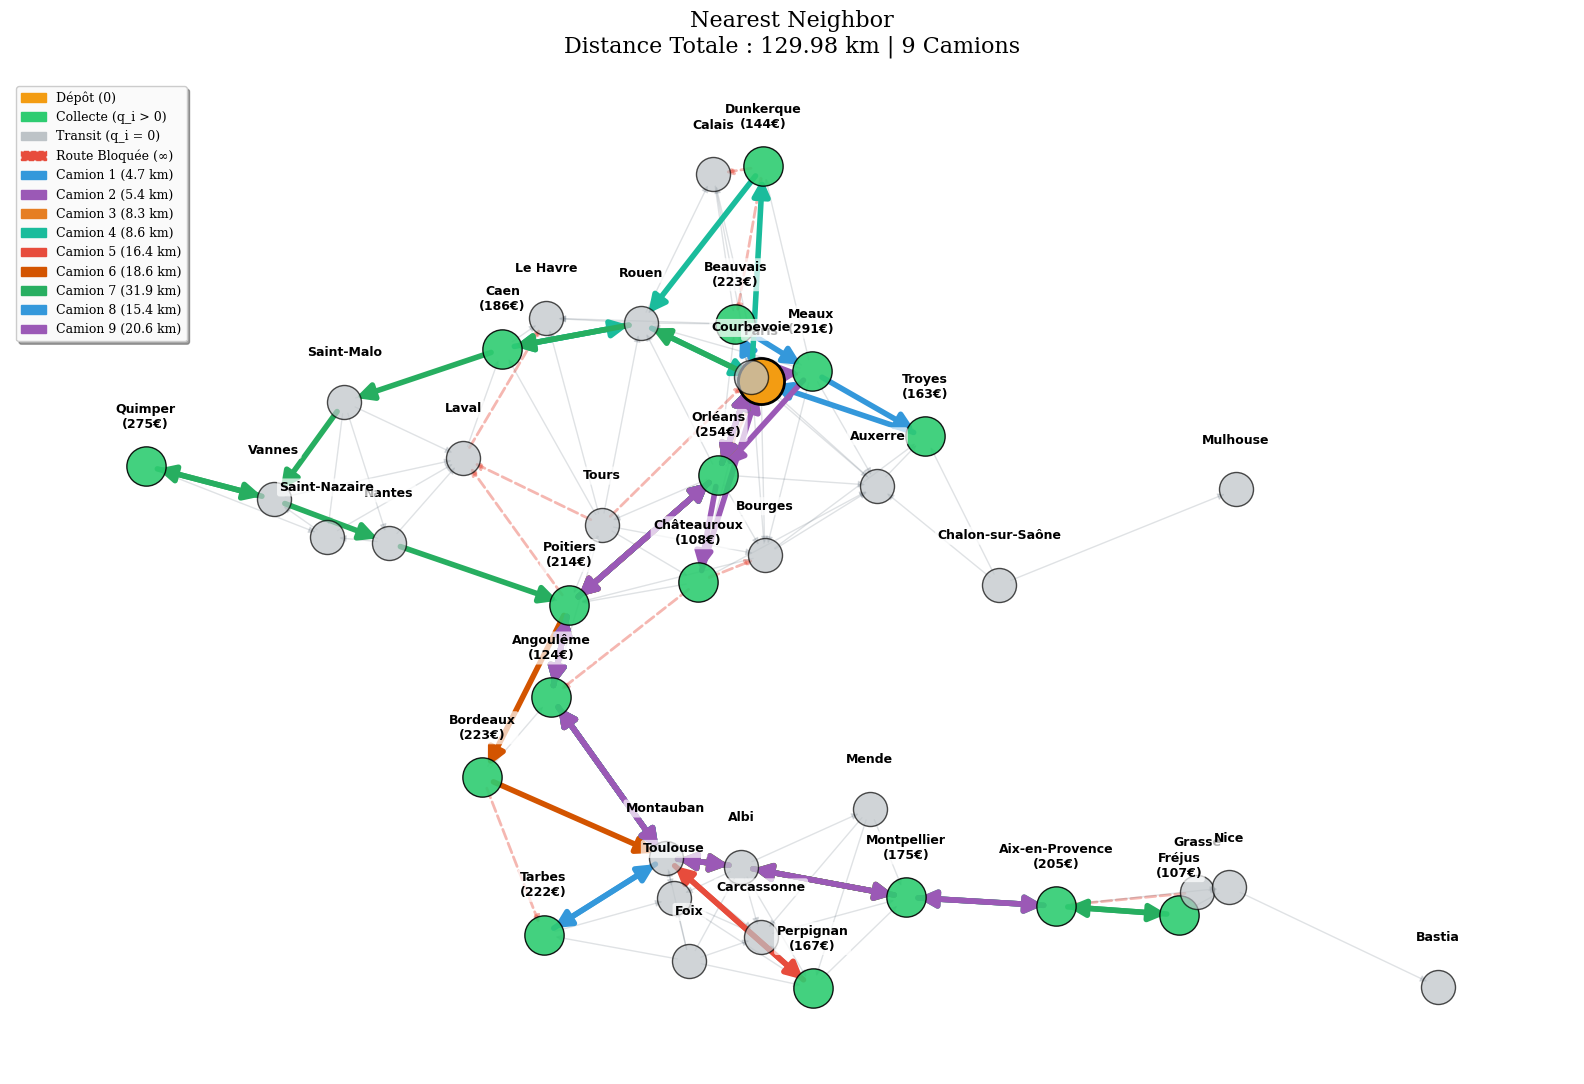

In [26]:
import time
t0 = time.time()
sol_nn = nearest_neighbor_vrp(vN_test, mp_test, vd_test, Q=Q_TEST)
t_nn   = time.time() - t0
d_nn   = calculate_total_distance(sol_nn, dr_test)
sol_nn_reel = expand_solution(sol_nn, next_node)

print(f"Nearest Neighbor  : distance={d_nn:.1f}  trucks={len(sol_nn_reel)}  time={t_nn:.3f}s")
visualize_final_vrp(vN_test, mp_test, vd_test, sol_nn_reel, title="Nearest Neighbor")

## 8.2 Clarke & Wright

Clarke & Wright   : distance=103.6  trucks=10  time=0.005s
Gain vs NN        : +20.3%


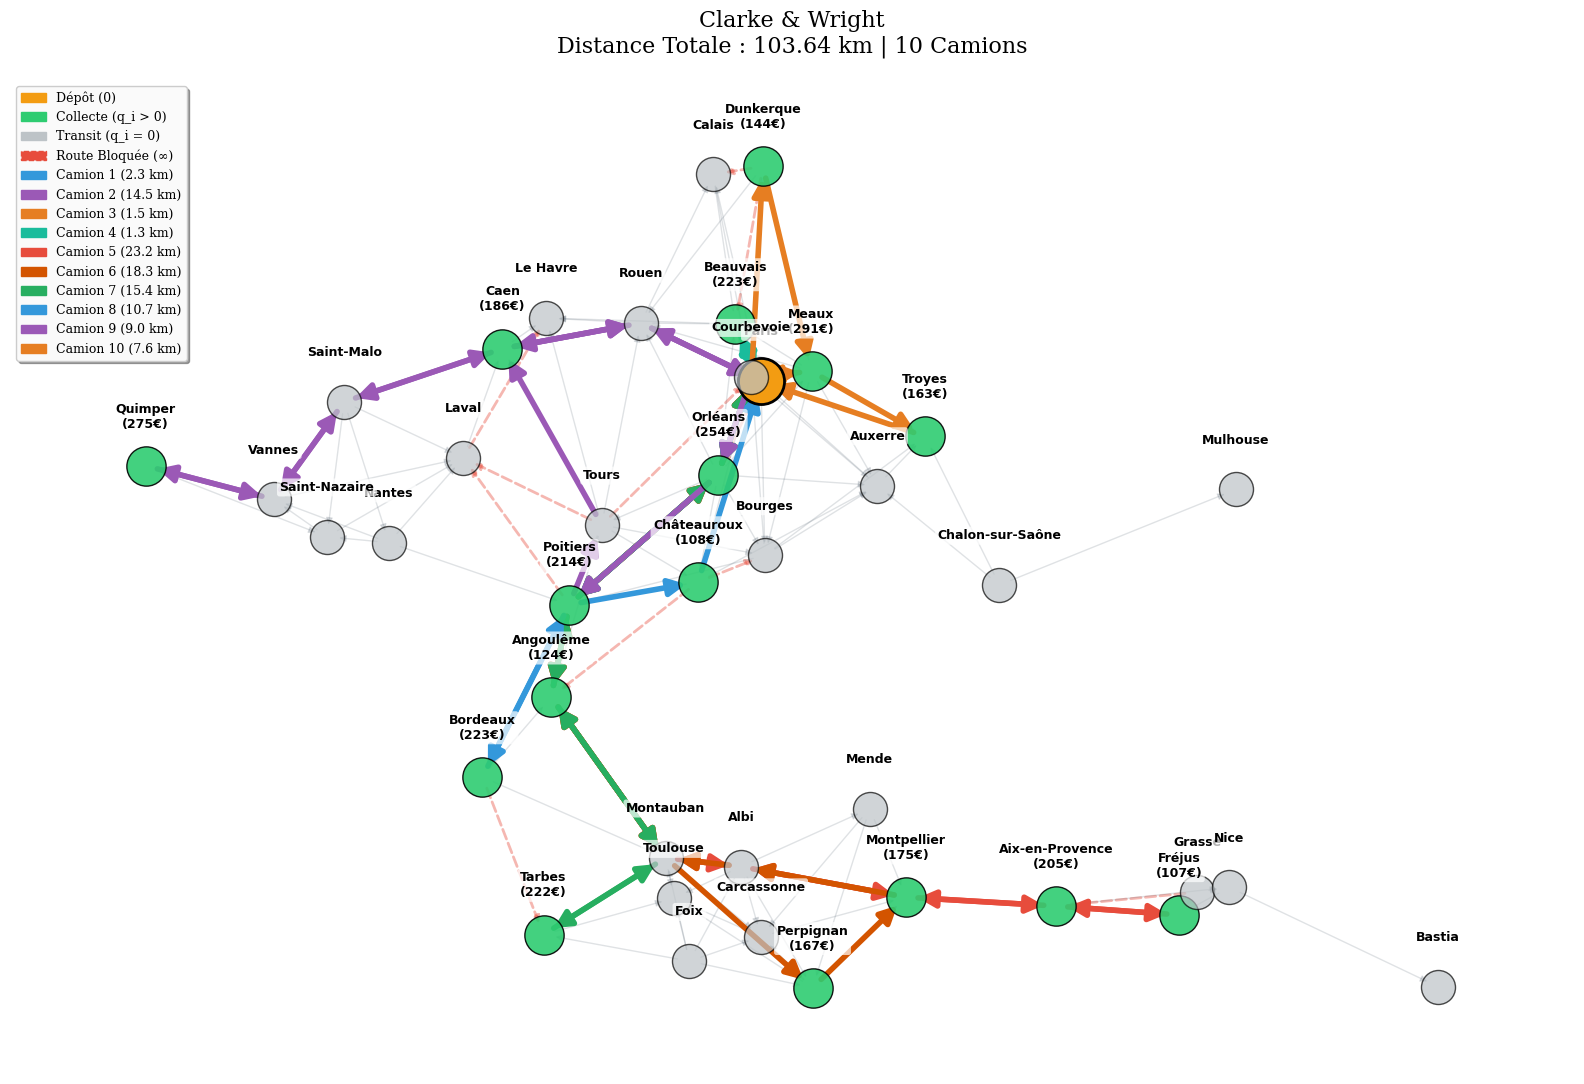

In [27]:
import time
t0 = time.time()
sol_cw  = clarke_wright(vN_test, mp_test, vd_test, Q=Q_TEST)
t_cw    = time.time() - t0
d_cw    = calculate_total_distance(sol_cw, dr_test)
sol_cw_reel = expand_solution(sol_cw, next_node)

print(f"Clarke & Wright   : distance={d_cw:.1f}  trucks={len(sol_cw_reel)}  time={t_cw:.3f}s")
print(f"Gain vs NN        : {(d_nn - d_cw)/d_nn*100:+.1f}%")
visualize_final_vrp(vN_test, mp_test, vd_test, sol_cw_reel,
                     title="Clarke & Wright", real_dist=dr_test)

## 8.3 Or-Opt

Or-Opt(CW)        : distance=103.6  trucks=10  time=0.005s
Gain vs CW        : +0.0%


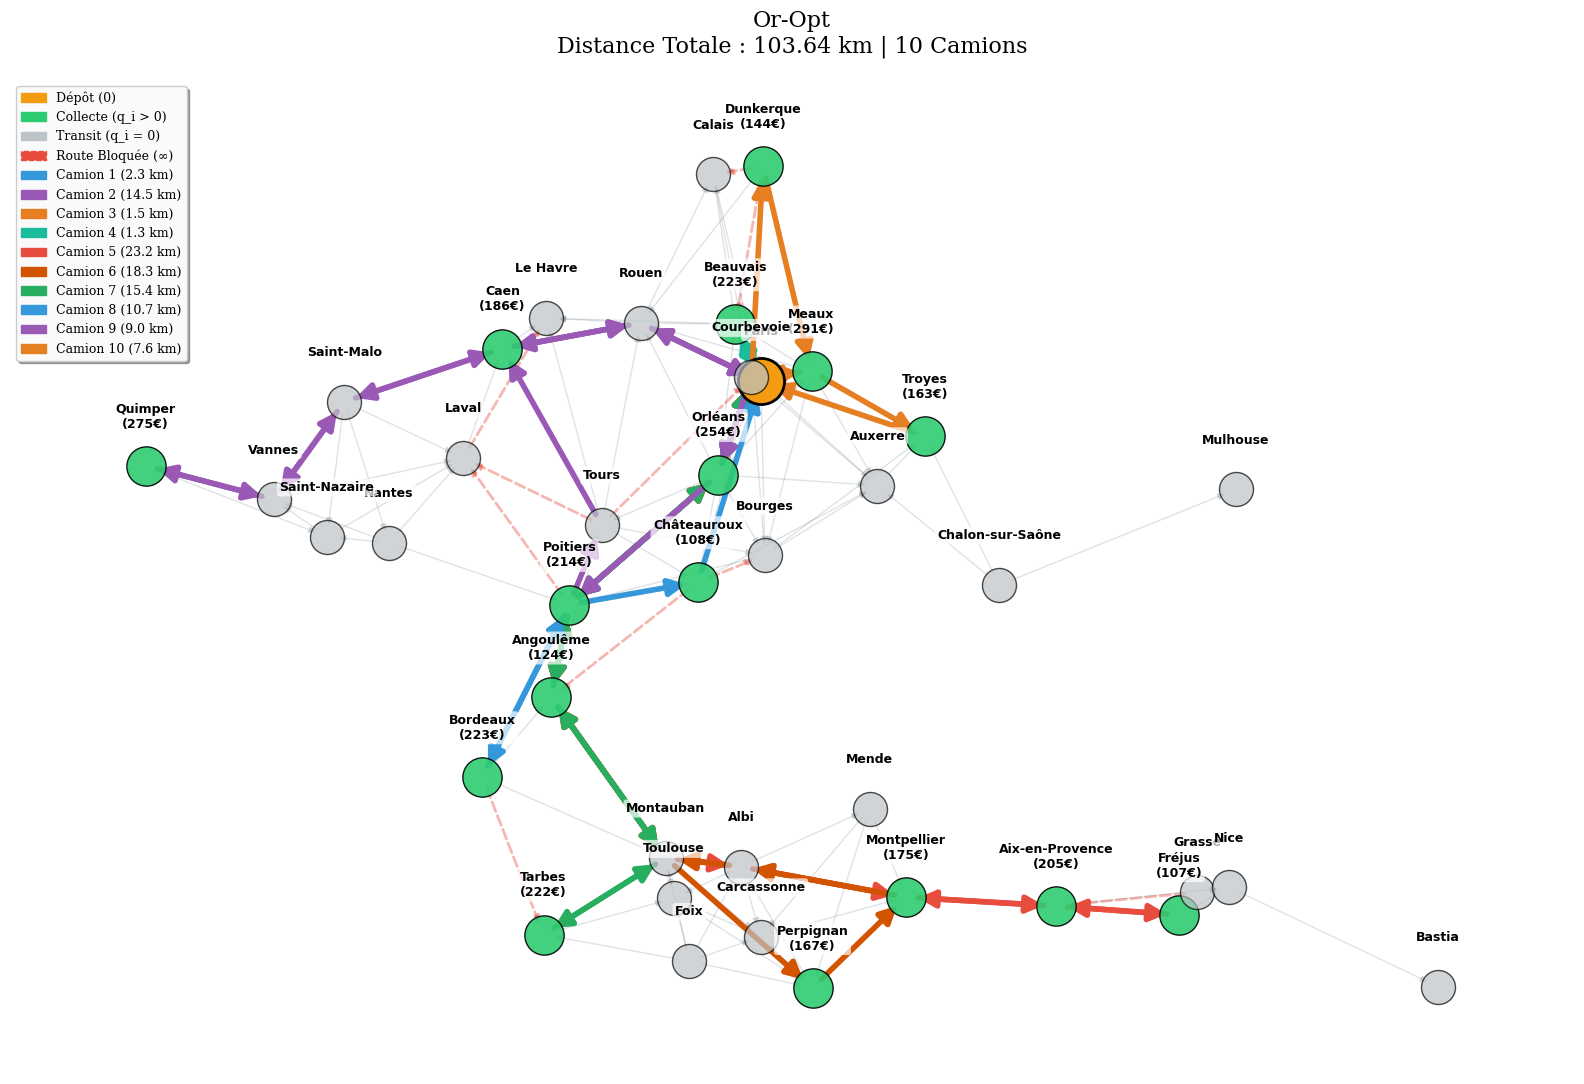

In [28]:
t0     = time.time()
sol_or = or_opt(vN_test, mp_test, vd_test, sol_cw, Q=Q_TEST)
t_or   = time.time() - t0
d_or   = calculate_total_distance(sol_or, dr_test)
sol_or_reel = expand_solution(sol_or, next_node)

print(f"Or-Opt(CW)        : distance={d_or:.1f}  trucks={len(sol_or_reel)}  time={t_or:.3f}s")
print(f"Gain vs CW        : {(d_cw - d_or)/d_cw*100:+.1f}%")
visualize_final_vrp(vN_test, mp_test, vd_test, sol_or_reel, title="Or-Opt")

## 8.4 Recuit Simulé v2

Simulated Annealing v2 : distance=103.6  trucks=10  time=2.544s
Gain vs CW             : +0.0%


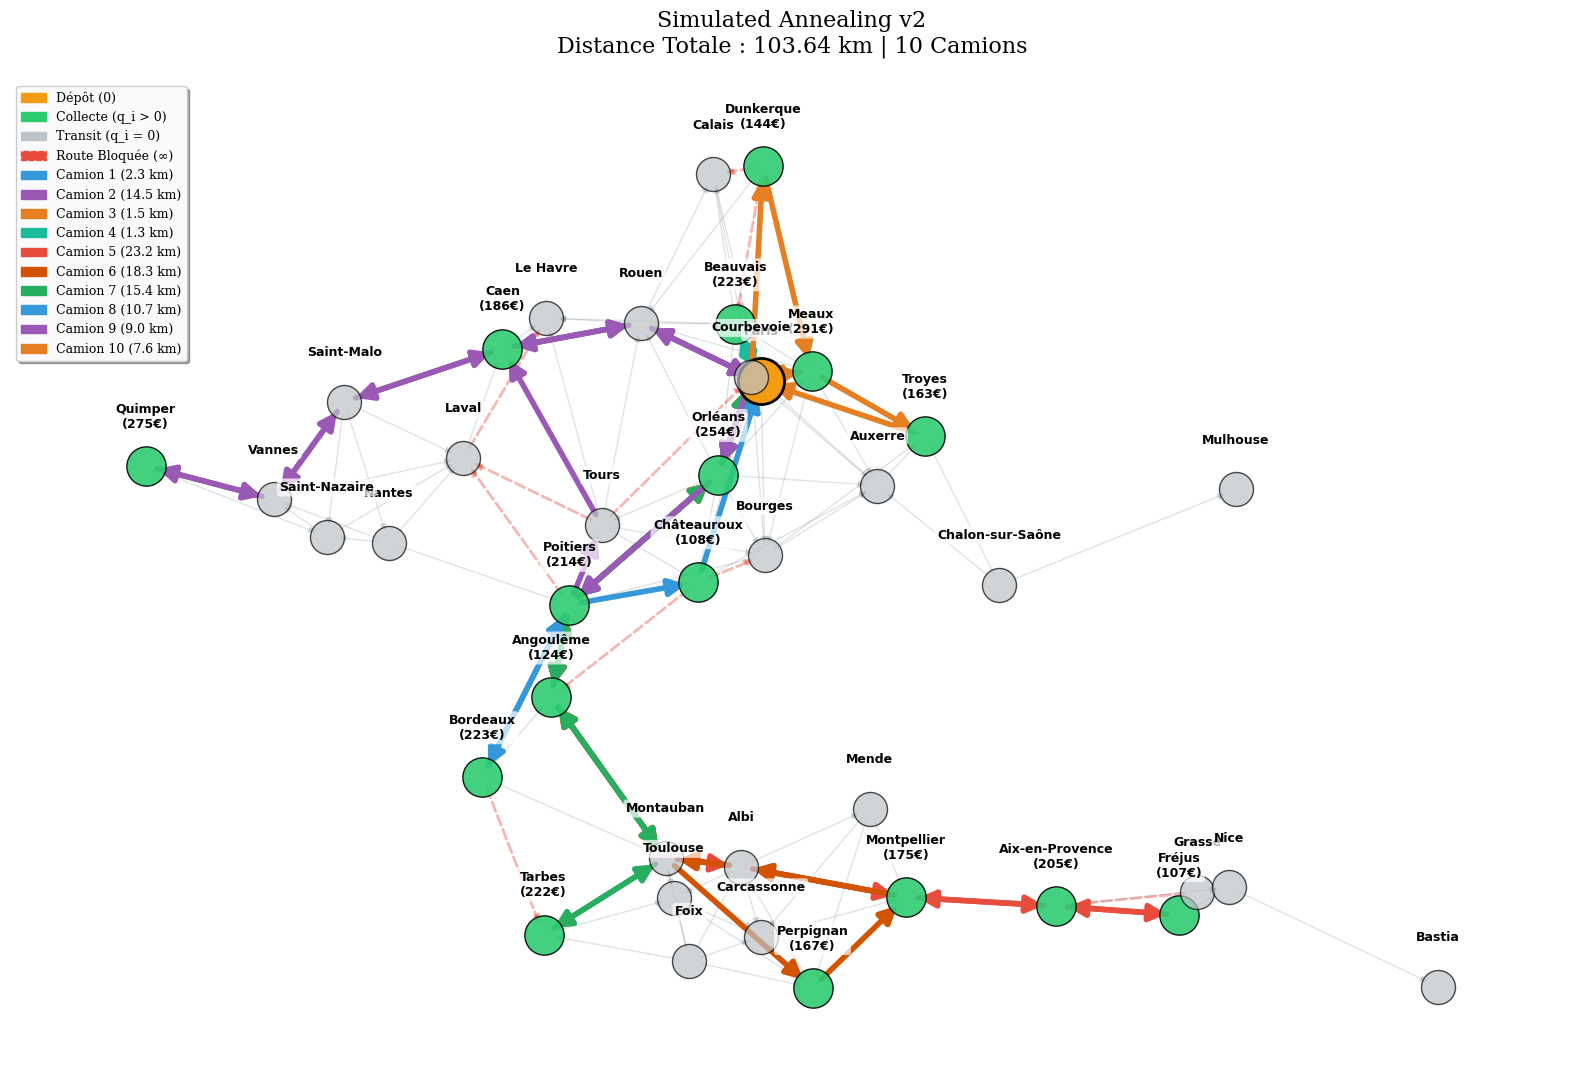

In [29]:
t0     = time.time()
sol_re = recuit_simule(vN_test, mp_test, vd_test, sol_cw, Q=Q_TEST)
t_re   = time.time() - t0
d_re   = calculate_total_distance(sol_re, dr_test)
sol_re_reel = expand_solution(sol_re, next_node)

print(f"Simulated Annealing v2 : distance={d_re:.1f}  trucks={len(sol_re_reel)}  time={t_re:.3f}s")
print(f"Gain vs CW             : {(d_cw - d_re)/d_cw*100:+.1f}%")
visualize_final_vrp(vN_test, mp_test, vd_test, sol_re_reel, title="Simulated Annealing v2")

Tabu Search : distance=103.6  trucks=10  time=0.047s
Gain vs CW             : +0.0%


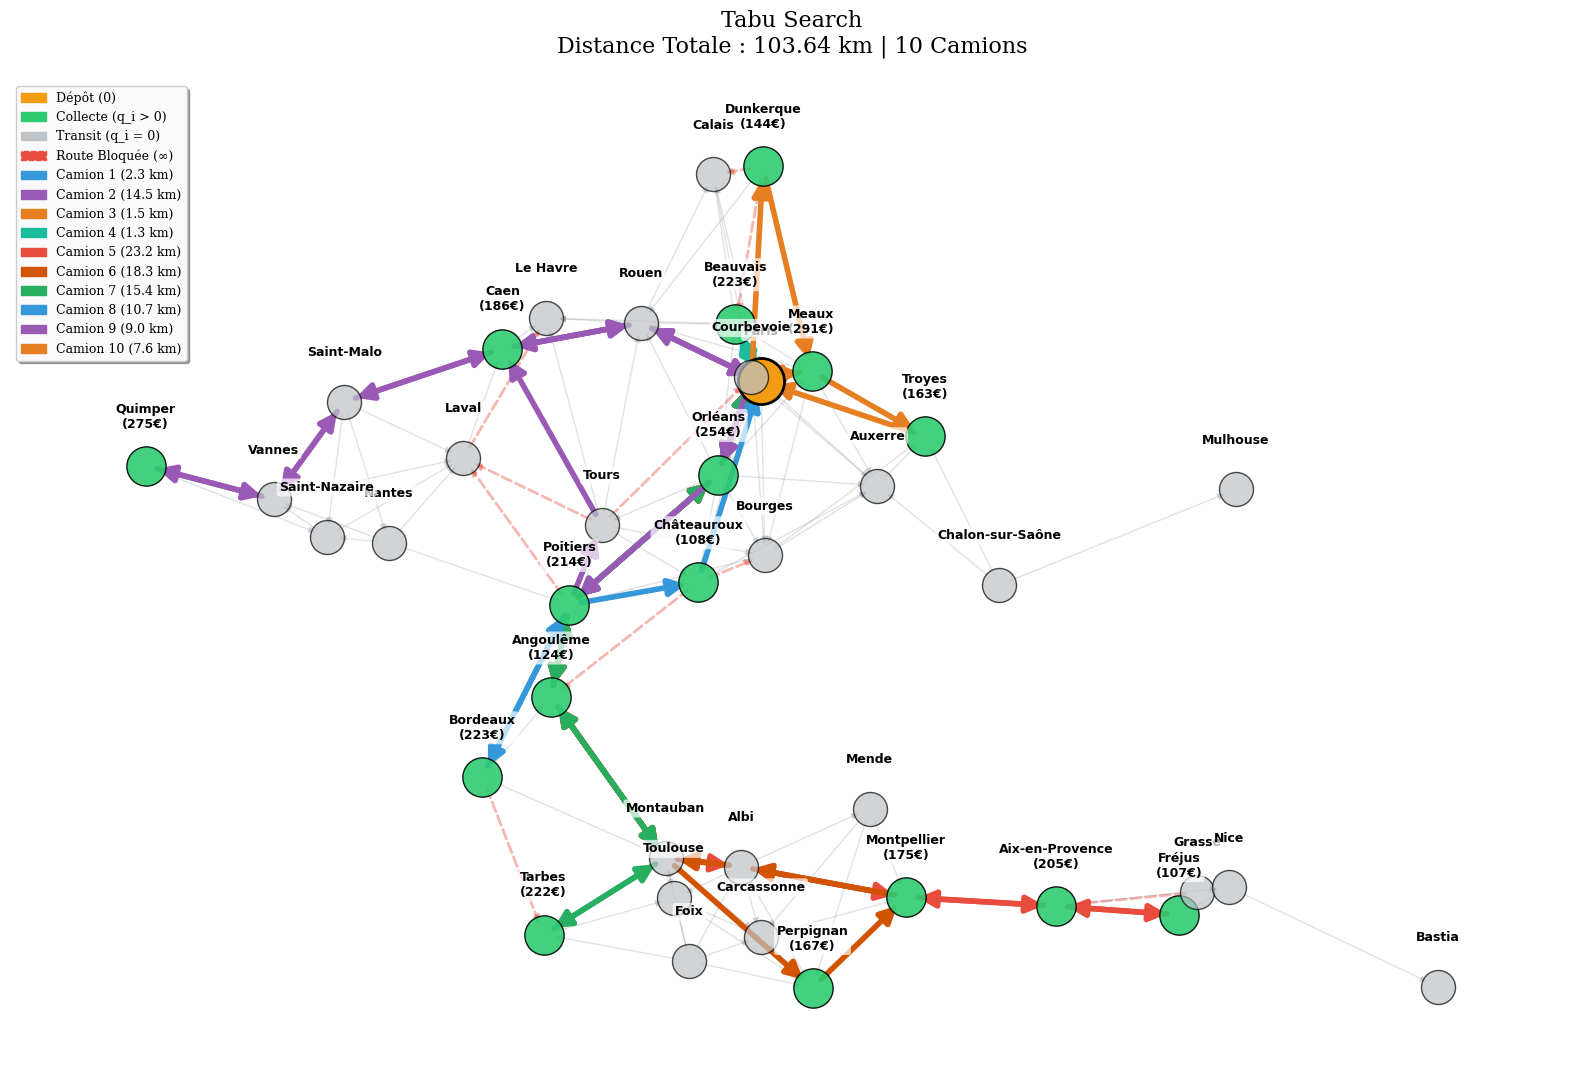

In [30]:
t0     = time.time()
sol_ts = tabu_search(vN_test, mp_test, vd_test, sol_cw, Q=Q_TEST)
t_ts   = time.time() - t0
d_ts   = calculate_total_distance(sol_ts, dr_test)
sol_ts_reel = expand_solution(sol_ts, next_node)

print(f"Tabu Search : distance={d_ts:.1f}  trucks={len(sol_ts_reel)}  time={t_ts:.3f}s")
print(f"Gain vs CW             : {(d_cw - d_ts)/d_cw*100:+.1f}%")
visualize_final_vrp(vN_test, mp_test, vd_test, sol_ts_reel, title="Tabu Search")

Colonie de fourmis: distance=103.3  trucks=8  time=0.114s
Gain vs CW             : +0.3%


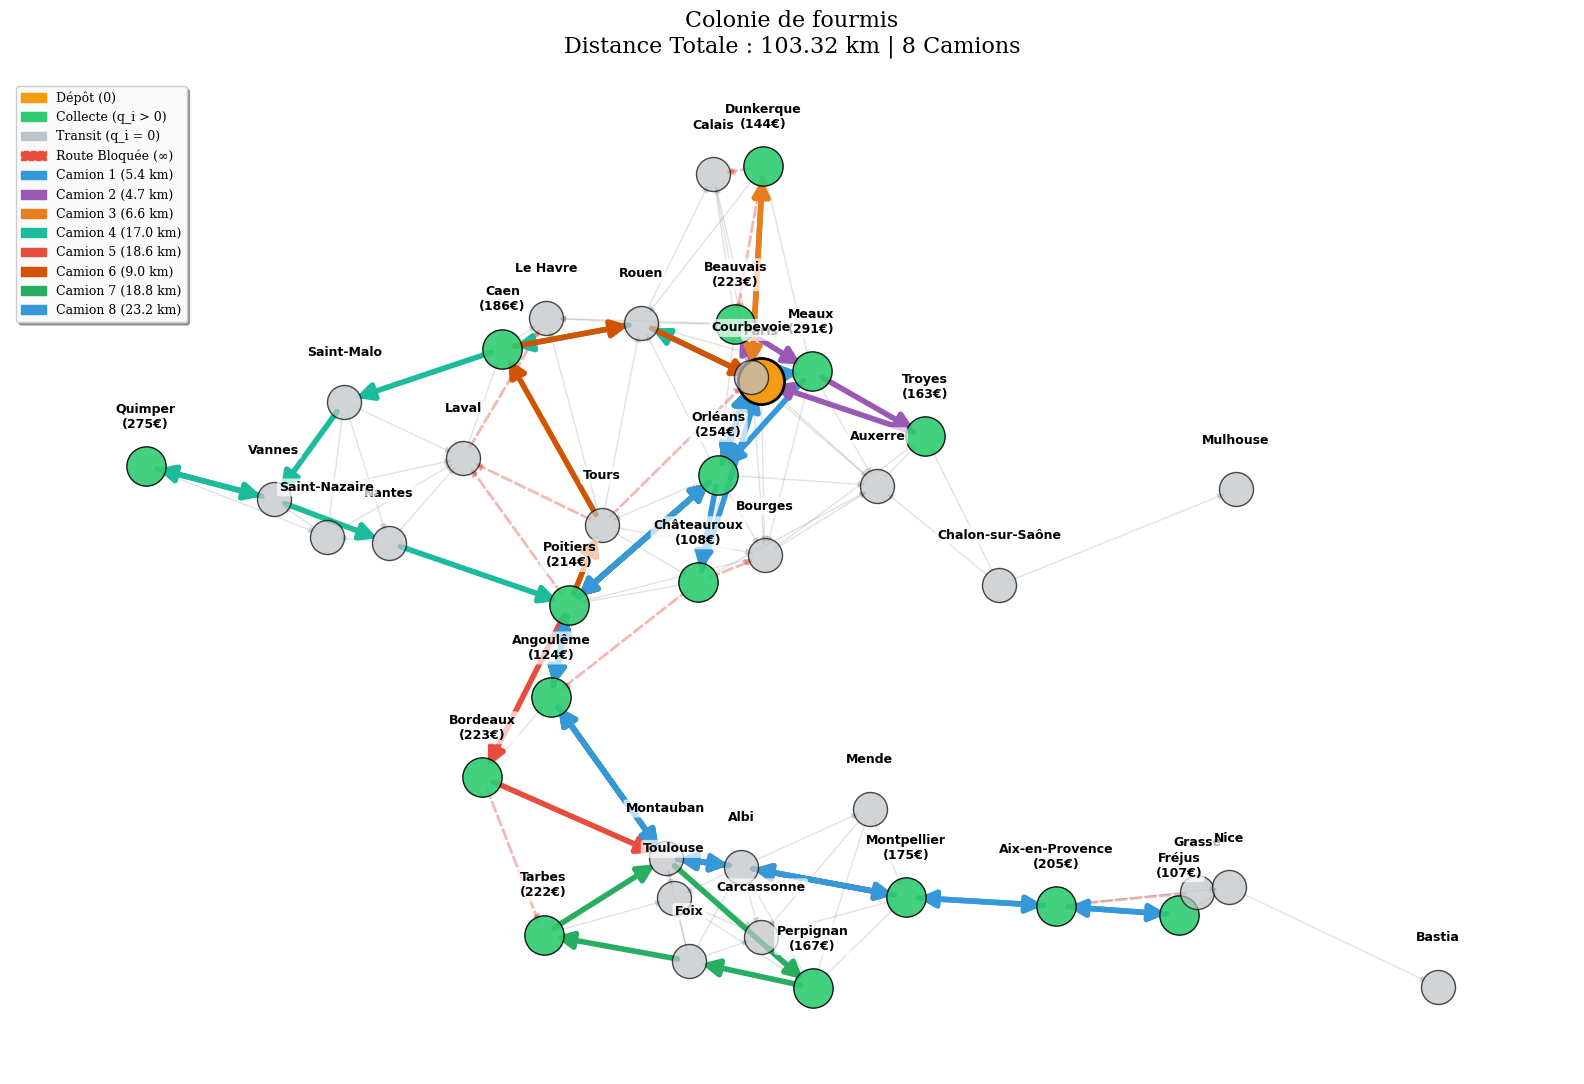

In [31]:
t0     = time.time()
sol_ant = ant_colony_optimization(vN_test, mp_test, vd_test, Q=Q_TEST)
t_ant   = time.time() - t0
d_ant   = calculate_total_distance(sol_ant, dr_test)
t_ant_reel = expand_solution(sol_ant, next_node)

print(f"Colonie de fourmis: distance={d_ant:.1f}  trucks={len(t_ant_reel)}  time={t_ant:.3f}s")
print(f"Gain vs CW             : {(d_cw - d_ant)/d_cw*100:+.1f}%")
visualize_final_vrp(vN_test, mp_test, vd_test, t_ant_reel, title="Colonie de fourmis")

## 8.5 Récapitulatif

In [32]:
algo_results = [
    ('Nearest Neighbor', d_nn, len(sol_nn), t_nn),
    ('Clarke & Wright',  d_cw, len(sol_cw), t_cw),
    ('Or-Opt(CW)',       d_or, len(sol_or), t_or),
    ('SA v2(CW)',        d_re, len(sol_re), t_re),
    ('Tabou Search',        d_ts, len(sol_ts), t_ts),
    ('Ant Colony',        d_ant, len(sol_ant), t_ts),
]
df_results = pd.DataFrame(algo_results, columns=['Algorithm', 'Distance', 'Trucks', 'Time (s)'])
df_results['Gain vs NN (%)'] = [(d_nn - d)/d_nn*100 for _, d, _, _ in algo_results]
df_results['Gain vs CW (%)'] = [(d_cw - d)/d_cw*100 for _, d, _, _ in algo_results]
df_results = df_results.round(2)
display(df_results)

,Algorithm,Distance,Trucks,Time (s),Gain vs NN (%),Gain vs CW (%)
0,Nearest Neighbor,129.98,9,0.00,0.00,-25.42
1,Clarke & Wright,103.64,10,0.00,20.27,0.00
2,Or-Opt(CW),103.64,10,0.01,20.27,0.00
3,SA v2(CW),103.64,10,2.54,20.27,0.00
4,Tabou Search,103.64,10,0.05,20.27,0.00
5,Ant Colony,103.32,8,0.05,20.51,0.30


In [33]:
print("Checking solution feasibility (logical routes)\n")

display_verification(sol_nn, mp_test, vd_test, Q_TEST,
                     route_type='logical', real_dist=dr_test,
                     label='Nearest Neighbor')

display_verification(sol_cw, mp_test, vd_test, Q_TEST,
                     route_type='logical', real_dist=dr_test,
                     label='Clarke & Wright')

display_verification(sol_or, mp_test, vd_test, Q_TEST,
                     route_type='logical', real_dist=dr_test,
                     label='Or-Opt')

display_verification(sol_re, mp_test, vd_test, Q_TEST,
                     route_type='logical', real_dist=dr_test,
                     label='Simulated Annealing v2')
                     
display_verification(sol_ts, mp_test, vd_test, Q_TEST,
                     route_type='logical', real_dist=dr_test,
                     label='Simulated Annealing v2')

display_verification(sol_ant, mp_test, vd_test, Q_TEST,
                     route_type='logical', real_dist=dr_test,
                     label='Ant Colony')

Checking solution feasibility (logical routes)

  Nearest Neighbor               ✅ VALID
  Clarke & Wright                ✅ VALID
  Or-Opt                         ✅ VALID
  Simulated Annealing v2         ✅ VALID
  Simulated Annealing v2         ✅ VALID
  Ant Colony                     ✅ VALID


True

### Analyse des résultats 

L'application de l'algorithme de Clarke & Wright permet de réaliser une amélioration de plus de 20 % par rapport à la solution initiale construite avec la méthode du plus proche voisin (*Nearest Neighbor*).

Ce gain de performance représente la proportion de distance économisée par rapport au trajet de référence. Il est évalué selon la formule suivante :

$$Gain (\%) = \left(\frac{d_{NN} - d_{CW}}{d_{NN}}\right) \times 100$$

Où :
* $d_{NN}$ : Distance totale de la tournée générée par le *Nearest Neighbor*.
* $d_{CW}$ : Distance totale de la tournée optimisée par *Clarke & Wright*.
* $d_{NN} - d_{CW}$ : L'économie de distance réalisée grâce à l'optimisation.

Enfin, en comparant la solution proposée par Clarke & Wright avec nos autres algorithmes (utilisés en amélioration ou en construction), nous remarquons que :
* Les métaheuristiques tel que Or-Opt, recuit simulé et tabou ne proposes aucune amélioration supplémentaire.
* Par ailleurs, l'algorithme de la colonie de fourmis permet d'améliorer légèrement la solution.

---
# 9. Benchmarks

Comparaison systématique sur une **grille N × Q** (instances denses — 60% clients).

- **N ∈ {20, 30, 50, 75, 100}** — scalabilité
- **Q ∈ {150, 200, 300, 400}** — influence de la capacité
- **5 essais par point** — résultats moyennés

Algorithmes comparés : **NN / CW / Or-Opt(CW) / Recuit(CW) / Tabou(CW) / ACO(CW)**


In [34]:
import time

SIZES_N_F  = [20, 30, 50, 75, 100]
#SIZES_N_F  = [20, 50, 100] #plus rapide

SIZES_Q_F  = [150, 200, 300, 400, 500]
#SIZES_Q_F  = [150, 300, 500] #plus rapide

CLIENT_RATIO = 0.60
NB_TRIALS_F  = 5

# Results storage
all_rows = []

print(f"Dense benchmark: {CLIENT_RATIO*100:.0f}% clients, "
      f"{len(SIZES_N_F)}×{len(SIZES_Q_F)} points, {NB_TRIALS_F} trials/point")
print("─" * 65)

for N in SIZES_N_F:
    for Q in SIZES_Q_F:
        nb_to_visit = max(3, int(N * CLIENT_RATIO))
        r_nn, r_cw, r_or, r_re, r_ant, r_ts = [], [], [], [], [], []
        t_nn, t_cw, t_or, t_re, t_ant, t_ts = [], [], [], [], [], []

        for _ in range(NB_TRIALS_F):
            vb = generate_synthetic_cities(N)
            vN, mp = create_vrp_city_network(N, X=N*3, blocking_rate=0.1, city_list=vb)
            vd = assign_city_data(vN, nb_to_visit=nb_to_visit)
            dr, _ = calculate_all_paths(list(range(N)), mp)
            demands = {idx: q_i for idx, q_i in vd}

            # NN
            t0 = time.time()
            sol_nn  = nearest_neighbor_vrp(vN, mp, vd, Q=Q)
            t_nn.append(time.time() - t0)
            
            # CW
            t0 = time.time()
            sol_cw = clarke_wright(vN, mp, vd, Q=Q)
            cw_time = time.time() - t0
            t_cw.append(cw_time)
            
            # Or-Opt
            t0 = time.time()
            sol_or  = or_opt(vN, mp, vd, sol_cw, Q=Q)
            t_or.append(cw_time + time.time() - t0)
            
            # Recuit Simule
            t0 = time.time()
            sol_re  = recuit_simule(vN, mp, vd, sol_cw, Q=Q)
            t_re.append(cw_time + time.time() - t0)
            
            # Tabu Search
            t0 = time.time()
            sol_ts = tabu_search(vN, mp, vd, sol_cw, Q=Q, max_iter=50, tabu_tenure=10)
            t_ts.append(cw_time + time.time() - t0)
            
            # Ant Colony
            t0 = time.time()
            sol_ant = ant_colony_optimization(vN, mp, vd, Q=Q)
            t_ant.append(time.time() - t0)

            r_nn.append(calculate_total_distance(sol_nn, dr))
            r_cw.append(calculate_total_distance(sol_cw, dr))
            r_or.append(calculate_total_distance(sol_or, dr))
            r_re.append(calculate_total_distance(sol_re, dr))
            r_ts.append(calculate_total_distance(sol_ts, dr))
            r_ant.append(calculate_total_distance(sol_ant, dr))

        nn_mean  = np.mean(r_nn)
        cw_mean  = np.mean(r_cw)
        all_rows.append({'N': N, 'Q': Q,
                         'NN':               nn_mean,
                         'CW':               cw_mean,
                         'Or-Opt(CW)':       np.mean(r_or),
                         'RS(CW)':           np.mean(r_re),
                         'AC(CW)':           np.mean(r_ant),
                         'Tabu(CW)':         np.mean(r_ts),
                         'Time NN':          np.mean(t_nn),
                         'Time CW':          np.mean(t_cw),
                         'Time Or-Opt(CW)':  np.mean(t_or),
                         'Time RS(CW)':      np.mean(t_re),
                         'Time AC(CW)':      np.mean(t_ant),
                         'Time Tabu(CW)':    np.mean(t_ts),
                         'Gain CW/NN (%)':   (nn_mean - cw_mean) / nn_mean * 100,
                         'Gain Or-Opt/CW (%)': (cw_mean - np.mean(r_or)) / cw_mean * 100,
                         'Gain RS/CW (%)': (cw_mean - np.mean(r_re)) / cw_mean * 100,
                         'Gain AC/CW (%)': (cw_mean - np.mean(r_ant)) / cw_mean * 100,
                         'Gain Tabu/CW (%)': (cw_mean - np.mean(r_ts)) / cw_mean * 100,
                         })
        print(f"  N={N:3d}, Q={Q:3d} | "
              f"CW/NN={all_rows[-1]['Gain CW/NN (%)']:+5.1f}%  "
              f"Or-Opt/CW={all_rows[-1]['Gain Or-Opt/CW (%)']:+5.1f}%  "
              f"RS/CW={all_rows[-1]['Gain RS/CW (%)']:+5.1f}%  "
              f"AC/CW={all_rows[-1]['Gain AC/CW (%)']:+5.1f}%  " \
              f"Tabu/CW={all_rows[-1]['Gain Tabu/CW (%)']:+5.1f}%"
        )

df_final = pd.DataFrame(all_rows)
print("\n✅ Completed")

Dense benchmark: 60% clients, 5×5 points, 5 trials/point
─────────────────────────────────────────────────────────────────
  N= 20, Q=150 | CW/NN= +9.4%  Or-Opt/CW= +0.0%  RS/CW= +1.5%  AC/CW= -0.3%  Tabu/CW= +0.0%
  N= 20, Q=200 | CW/NN=+100.0%  Or-Opt/CW= +0.0%  RS/CW= +0.8%  AC/CW= +0.8%  Tabu/CW= +0.0%
  N= 20, Q=300 | CW/NN=+14.2%  Or-Opt/CW= +0.0%  RS/CW= +1.4%  AC/CW= -1.0%  Tabu/CW= +0.0%
  N= 20, Q=400 | CW/NN=+24.2%  Or-Opt/CW= +0.0%  RS/CW= +2.0%  AC/CW= -7.2%  Tabu/CW= +0.0%
  N= 20, Q=500 | CW/NN=+15.6%  Or-Opt/CW= +0.0%  RS/CW= +1.5%  AC/CW= -1.3%  Tabu/CW= +0.8%
  N= 30, Q=150 | CW/NN= +9.7%  Or-Opt/CW= +0.0%  RS/CW= +2.9%  AC/CW= +0.7%  Tabu/CW= +0.0%
  N= 30, Q=200 | CW/NN=+100.0%  Or-Opt/CW= +0.0%  RS/CW= +2.1%  AC/CW= -6.2%  Tabu/CW= +0.0%
  N= 30, Q=300 | CW/NN=+15.1%  Or-Opt/CW= +0.0%  RS/CW= +0.7%  AC/CW= -3.3%  Tabu/CW= +0.2%
  N= 30, Q=400 | CW/NN=+18.4%  Or-Opt/CW= +0.0%  RS/CW= +0.8%  AC/CW= -8.1%  Tabu/CW= +0.0%
  N= 30, Q=500 | CW/NN=+19.1%  Or-Opt/CW= +0.0%

In [35]:
ALGOS_COLOR = {
    'NN':         ('#e74c3c', 'o', '-'),
    'CW':         ('#3498db', 's', '-'),
    'Or-Opt(CW)': ('#2ecc71', '^', '-'),
    'RS(CW)':     ('#9b59b6', 'D', '--'),
    'AC(CW)':     ('#fc03d3', 'D', '--'),
    'Tabu(CW)':     ('#ebcc34', 'D', '--'),
}


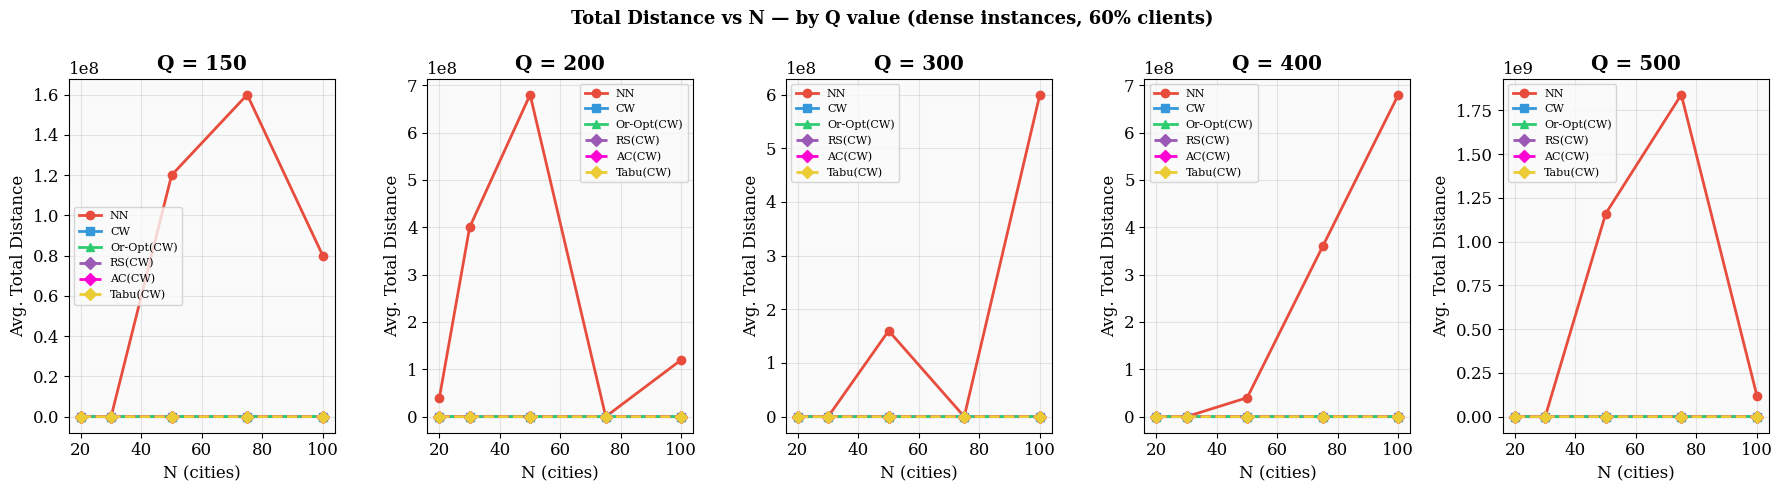

In [36]:
fig, axes = plt.subplots(1, len(SIZES_Q_F), figsize=(18, 5), sharey=False)
fig.suptitle('Total Distance vs N — by Q value (dense instances, 60% clients)',
             fontsize=13, fontweight='bold')

for ax, Q in zip(axes, SIZES_Q_F):
    sub = df_final[df_final['Q'] == Q]
    for algo, (color, marker, ls) in ALGOS_COLOR.items():
        column_name = 'RS(CW)' if algo == 'RS(CW)' else algo
        ax.plot(sub['N'], sub[column_name], marker=marker, ls=ls, lw=2,
                color=color, label=algo)
    ax.set_title(f'Q = {Q}', fontweight='bold')
    ax.set_xlabel('N (cities)')
    ax.set_ylabel('Avg. Total Distance')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
# 12. Comparaison : Clarke & Wright vs Solveur Exact (PuLP)

Pour évaluer la qualité de l'heuristique Clarke & Wright, on la confronte au solveur exact PuLP sur plusieurs petites instances ($N = 10, 15, 20$). PuLP résout le CVRP de manière optimale via la programmation linéaire en nombres entiers (ILP), mais son temps de calcul explose avec la taille du graphe. L'objectif est de mesurer l'écart de qualité entre les deux approches et le coût en temps associé.


### Analyse des performances

Les campagnes de tests ont été réalisées sur des graphes denses (60 % de clients) en faisant varier le nombre de villes (N entre 20 et 100) et la capacité des véhicules (Q entre 150 et 500). L'observation des nouveaux graphiques permet de tirer les conclusions suivantes :

1. Explosion combinatoire du Nearest Neighbor
L'algorithme du plus proche voisin affiche une instabilité critique dès que la taille du problème augmente. Sur les trois graphiques, la distance totale explose littéralement pour atteindre des valeurs comprises entre 2e8 et 2,7e9. Cette progression n'est pas linéaire mais exponentielle, prouvant que cette méthode gloutonne est incapable de gérer la complexité d'un réseau dense à grande échelle.

2. Robustesse des méthodes basées sur Clarke & Wright
Tous les algorithmes s'appuyant sur Clarke & Wright (CW, Or-Opt, RS, Tabu, AC) apparaissent comme une ligne plate à la base des graphiques. Bien que leurs distances ne soient pas nulles, elles sont très petites par rapport aux résultats du Nearest Neighbor. 

3. Impact relatif de la capacité (Q)
Si la capacité Q influe sur la valeur absolue de la distance, elle ne corrige en rien le défaut structurel du Nearest Neighbor. On remarque d'ailleurs que l'explosion du NN est encore plus violente pour Q=500 que pour Q=300. Cela confirme que la contrainte de capacité, si elle est mal gérée au départ, amplifie les trajectoires non optimisées.

### Conclusion de l'analyse

La construction d'une solution de bout en bout avec une méthode purement gloutonne comme le Nearest Neighbor est totalement proscrite pour des problèmes de routage denses, sous peine d'obtenir des trajets inexploitables.

Pour garantir une scalabilité réelle, il est impératif d'adopter une stratégie hybride :
1. Phase de construction : Utiliser une heuristique robuste comme Clarke & Wright pour fixer une structure de base saine.
2. Phase d'amélioration : Appliquer une métaheuristique (Recuit Simulé, Recherche Tabou ou Colonies de Fourmis hybridées) pour affiner la solution. 

C'est ce couplage qui permet d'obtenir des performances stables et optimales, même lorsque le nombre de clients ou les contraintes de capacité augmentent.

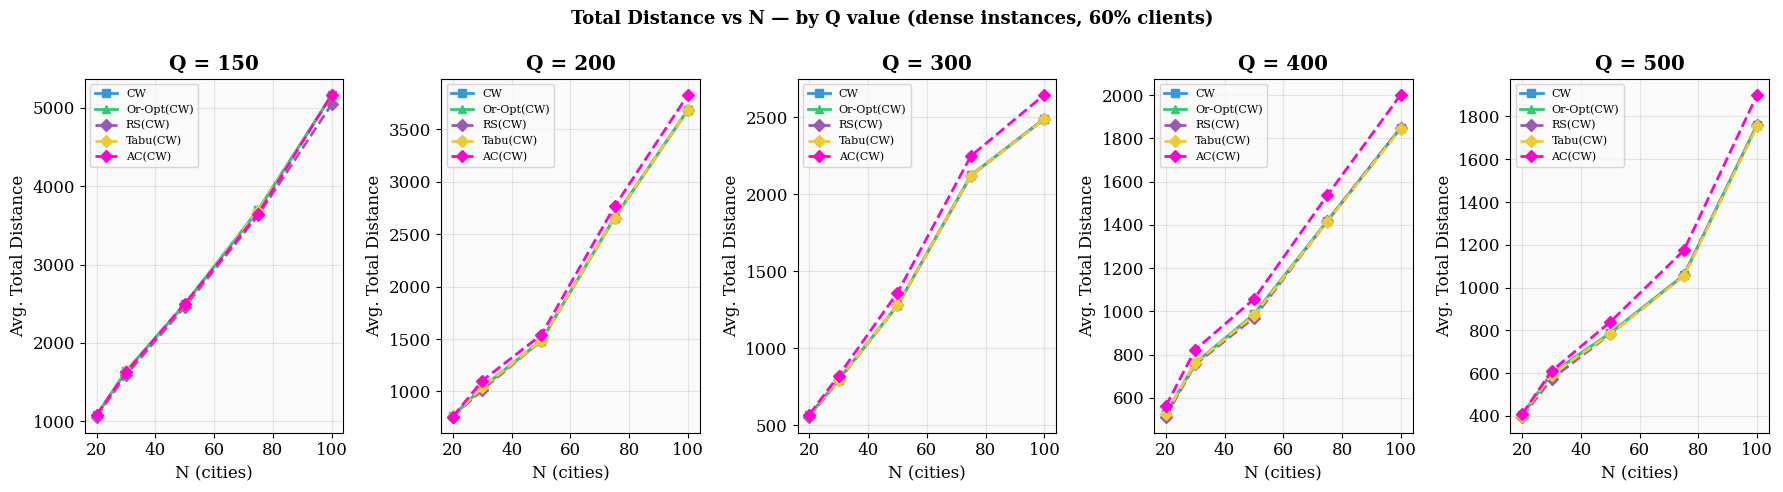

In [37]:
ALGOS_COLOR = {
    'CW':         ('#3498db', 's', '-'),
    'Or-Opt(CW)': ('#2ecc71', '^', '-'),
    'RS(CW)':     ('#9b59b6', 'D', '--'),
    'Tabu(CW)':     ('#ebcc34', 'D', '--'),
    'AC(CW)':     ('#fc03d3', 'D', '--'),
}
fig, axes = plt.subplots(1, len(SIZES_Q_F), figsize=(18, 5), sharey=False)
fig.suptitle('Total Distance vs N — by Q value (dense instances, 60% clients)',
             fontsize=13, fontweight='bold')

for ax, Q in zip(axes, SIZES_Q_F):
    sub = df_final[df_final['Q'] == Q]
    for algo, (color, marker, ls) in ALGOS_COLOR.items():
        column_name = 'RS(CW)' if algo == 'RS(CW)' else algo
        ax.plot(sub['N'], sub[column_name], marker=marker, ls=ls, lw=2,
                color=color, label=algo)
    ax.set_title(f'Q = {Q}', fontweight='bold')
    ax.set_xlabel('N (cities)')
    ax.set_ylabel('Avg. Total Distance')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Analyse des algorithmes basés sur Clarke & Wright

En excluant les méthodes instables de la visualisation, nous pouvons observer le comportement des algorithmes robustes. Tous ces algorithmes utilisent la solution de Clarke et Wright comme base de départ.

1. Une croissance linéaire et maîtrisée de la distance
Contrairement aux algorithmes gloutons qui subissaient une explosion combinatoire, on observe ici que la distance totale croît de manière quasi linéaire en fonction du nombre de villes (N). Les algorithmes gèrent efficacement la mise à l'échelle sur des graphes denses allant jusqu'à 100 nœuds, sans subir de dérive exponentielle.

2. L'efficacité de la solution initiale par économies
Ce qui est le plus marquant est la superposition de la majorité des courbes. Visuellement, les performances de CW, Or-Opt, Recuit Simulé et Recherche Tabou sont extrêmement proches. Cela démontre que l'heuristique de Clarke et Wright réalise à elle seule la plus grande partie du travail d'optimisation. Les algorithmes d'amélioration apportent des gains qui restent visuellement discrets à cette échelle, confirmant la qualité de la structure de base. On note toutefois que les Colonies de Fourmis, montrent une légère divergence sur les instances les plus larges.

3. L'impact de la capacité Q et le phénomène de palier
L'augmentation de la capacité des véhicules a un impact direct sur la réduction de la distance totale car elle limite les allers-retours vers le dépôt. Pour N = 100, la distance totale chute de manière significative lorsque la capacité augmente, passant d'environ 4500 pour Q = 150 à environ 1300 pour Q = 500. On observe un effet de palier où le gain de distance devient plus régulier, indiquant que la capacité finit par ne plus être la seule contrainte limitante face à la disposition géographique des clients.

### Conclusion de l'analyse
Ces résultats valident la stratégie d'optimisation hybride. L'heuristique de Clarke et Wright agit comme un moteur puissant pour structurer les tournées de manière rationnelle dès le départ. L'ajout d'une métaheuristique en aval reste pertinent pour affiner les derniers détails du parcours et optimiser les derniers pourcents, mais c'est la robustesse de la construction initiale par le calcul des économies qui garantit la stabilité et l'efficacité globale du modèle face à l'augmentation du nombre de clients.

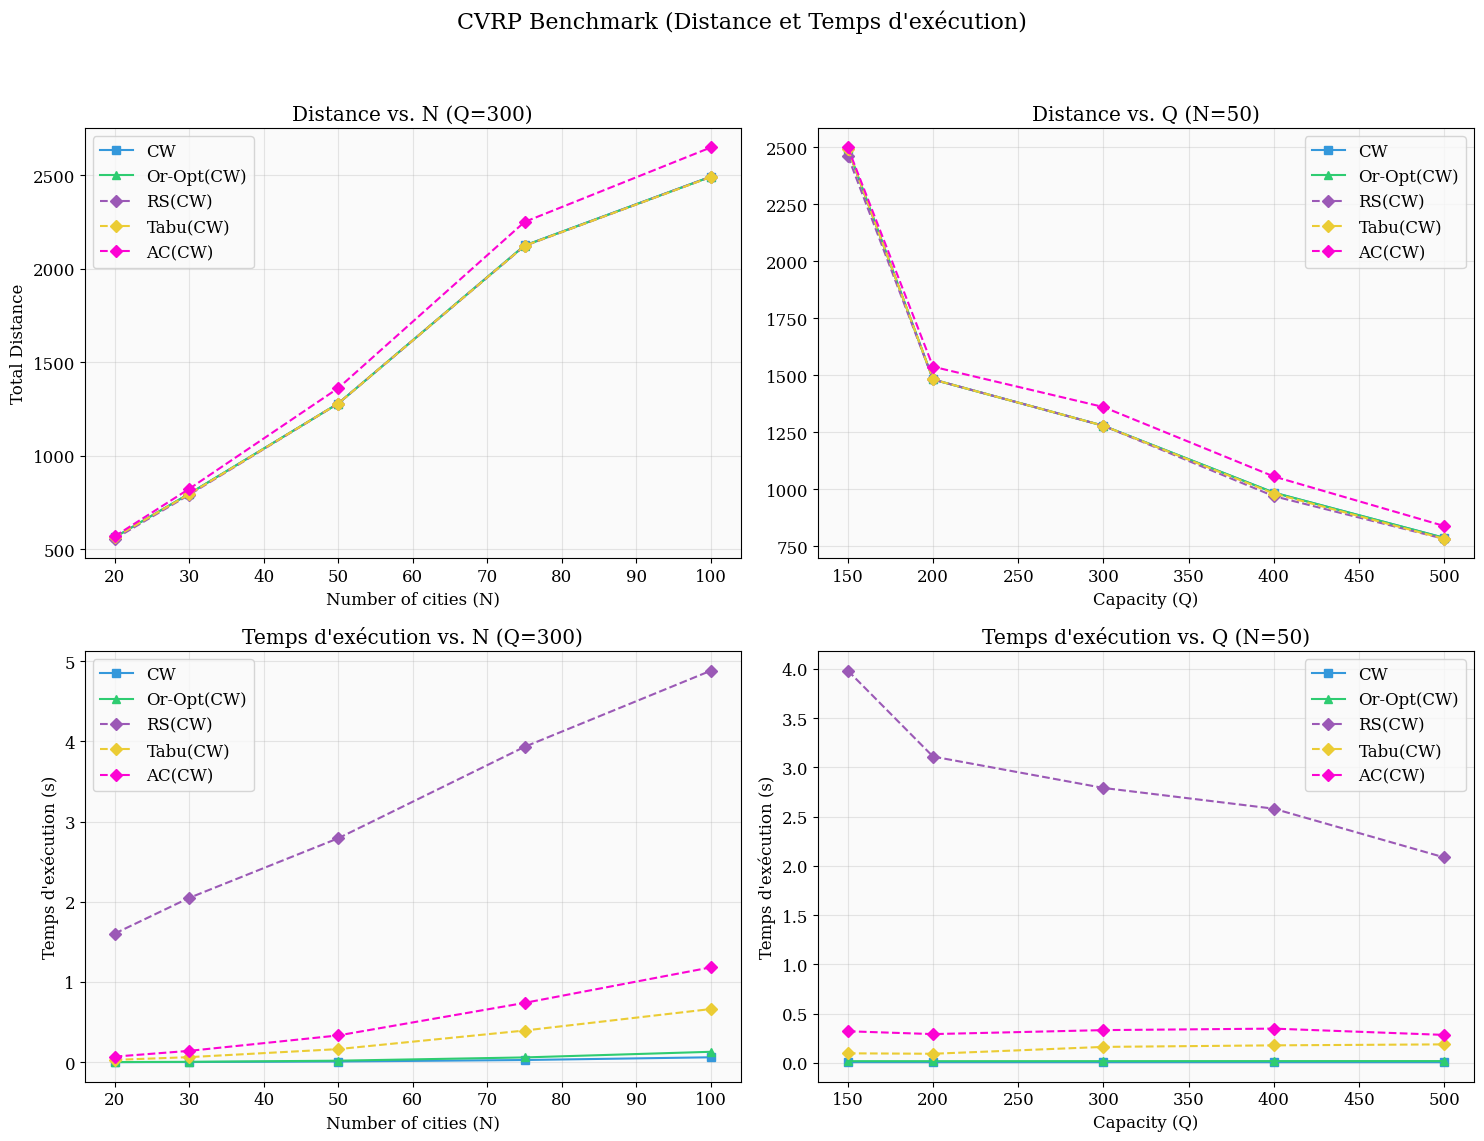

In [38]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

fig.suptitle("CVRP Benchmark (Distance et Temps d'exécution)", fontsize=16)

fixed_Q = SIZES_Q_F[len(SIZES_Q_F)//2]
sub_q = df_final[df_final['Q'] == fixed_Q]

for algo, (color, marker, ls) in ALGOS_COLOR.items():
    if algo in sub_q.columns:
        axes[0, 0].plot(sub_q['N'], sub_q[algo], marker=marker, ls=ls, color=color, label=algo)

axes[0, 0].set_title(f"Distance vs. N (Q={fixed_Q})")
axes[0, 0].set_xlabel("Number of cities (N)")
axes[0, 0].set_ylabel("Total Distance")
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

fixed_N = SIZES_N_F[len(SIZES_N_F)//2]
sub_n = df_final[df_final['N'] == fixed_N]

for algo, (color, marker, ls) in ALGOS_COLOR.items():
    if algo in sub_n.columns:
        axes[0, 1].plot(sub_n['Q'], sub_n[algo], marker=marker, ls=ls, color=color, label=algo)

axes[0, 1].set_title(f"Distance vs. Q (N={fixed_N})")
axes[0, 1].set_xlabel("Capacity (Q)")
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()

# Time graphs
for algo, (color, marker, ls) in ALGOS_COLOR.items():
    time_col = f"Time {algo}"
    if time_col in sub_q.columns:
        axes[1, 0].plot(sub_q['N'], sub_q[time_col], marker=marker, ls=ls, color=color, label=algo)

axes[1, 0].set_title(f"Temps d'exécution vs. N (Q={fixed_Q})")
axes[1, 0].set_xlabel("Number of cities (N)")
axes[1, 0].set_ylabel("Temps d'exécution (s)")
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

for algo, (color, marker, ls) in ALGOS_COLOR.items():
    time_col = f"Time {algo}"
    if time_col in sub_n.columns:
        axes[1, 1].plot(sub_n['Q'], sub_n[time_col], marker=marker, ls=ls, color=color, label=algo)

axes[1, 1].set_title(f"Temps d'exécution vs. Q (N={fixed_N})")
axes[1, 1].set_xlabel("Capacity (Q)")
axes[1, 1].set_ylabel("Temps d'exécution (s)")
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Analyse du compromis : Qualité d'optimisation vs Temps d'exécution

Cette série de graphiques permet d'évaluer les performances globales des algorithmes en confrontant la qualité de la solution (Distance totale) au coût computationnel (Temps d'exécution), en fixant alternativement la capacité (Q=300) et la taille du réseau (N=50).

**1. Qualité des solutions (Graphiques supérieurs)**

L'observation de la distance en fonction de la taille du réseau (en haut à gauche) confirme la robustesse de l'heuristique de Clarke et Wright. Les algorithmes d'amélioration (RS, Tabu, Or-Opt) restent superposés à la solution de base, maintenant une trajectoire d'évolution linéaire. On note cependant que l'algorithme des Colonies de Fourmis perd légèrement en efficacité sur la plus grande instance (N=100). Le graphique en haut à droite démontre que le Recuit Simulé parvient à trouver de meilleures solutions que les autres lorsque les contraintes de capacité sont très fortes (Q=150).

**2. Coût computationnel en fonction de la taille (En bas à gauche)**

Ce graphique révèle la nature des algorithmes. L'heuristique de Clarke et Wright et l'algorithme Or-Opt s'exécutent de manière quasi instantanée, avec des temps collés à zéro, confirmant leur efficacité algorithmique. À l'opposé, le Recuit Simulé est de loin l'approche la plus coûteuse, son temps d'exécution augmentant fortement avec le nombre de villes pour atteindre environ 5 secondes sur l'instance N=100. La Recherche Tabou et les Colonies de Fourmis se maintiennent sous la barre de la seconde.

**3. Impact de la capacité sur le temps de calcul (En bas à droite)**

L'évolution du temps d'exécution en fonction de la capacité montre une tendance intéressante pour le Recuit Simulé. Son temps de calcul diminue de manière significative à mesure que la capacité des véhicules augmente. Cela s'explique mécaniquement : une plus grande capacité implique moins de retours au dépôt et donc des tournées moins nombreuses à évaluer et à permuter lors de la phase d'exploration du voisinage.

### Conclusion de l'analyse

Ces résultats illustrent parfaitement le dilemme central de l'optimisation des tournées. 

L'heuristique de Clarke et Wright s'impose comme le choix incontestable pour générer une solution de très bonne qualité instantanément. 

L'utilisation du Recuit Simulé est justifiée uniquement si le contexte métier exige l'optimisation maximale absolue (notamment sous de fortes contraintes de capacité) et permet de tolérer un temps de calcul plus long. Enfin, la Recherche Tabou se distingue ici comme un excellent compromis technique, offrant des temps d'exécution minimes tout en garantissant des trajectoires extrêmement proches des optimums trouvés par le Recuit Simulé.

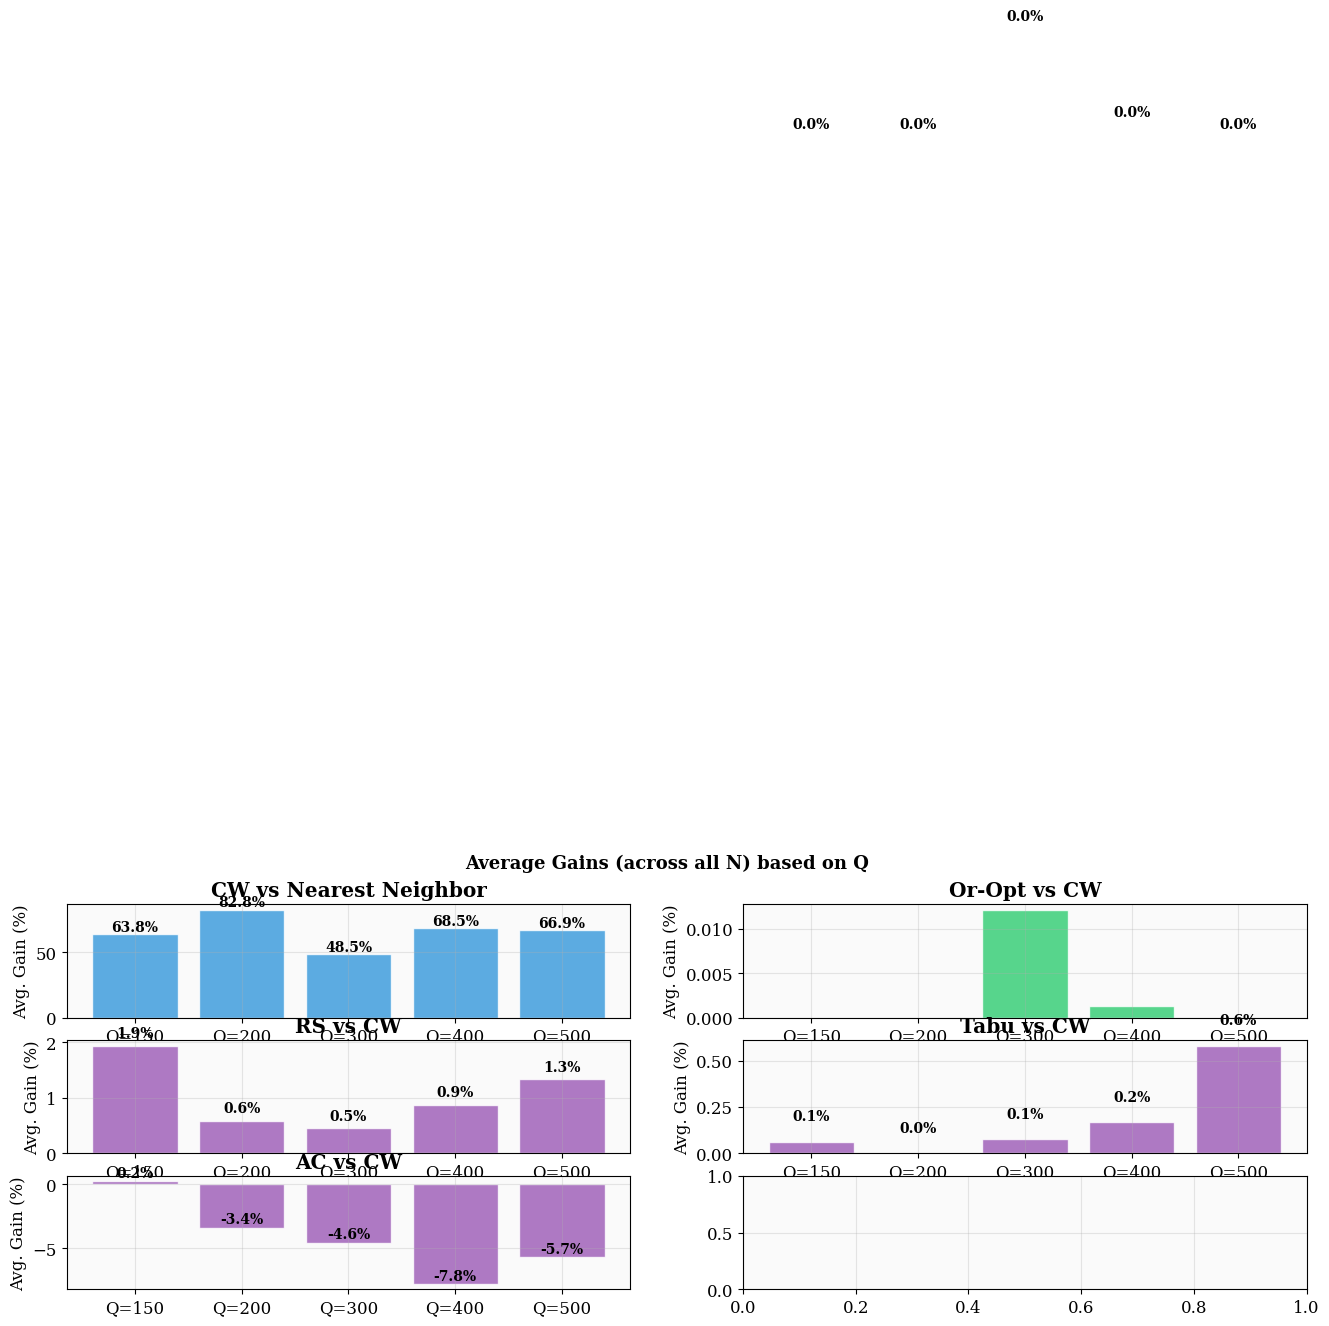

In [39]:
fig, ((ax1, ax2), (ax3, ax4), (ax5, ax6)) = plt.subplots(3, 2, figsize=(16, 5))
fig.suptitle('Average Gains (across all N) based on Q', fontsize=13, fontweight='bold')

gains_by_Q = df_final.groupby('Q')[[
    'Gain CW/NN (%)', 'Gain Or-Opt/CW (%)', 'Gain RS/CW (%)', 'Gain Tabu/CW (%)', 'Gain AC/CW (%)'
]].mean()

for ax, col, color, title in [
    (ax1, 'Gain CW/NN (%)',      '#3498db', 'CW vs Nearest Neighbor'),
    (ax2, 'Gain Or-Opt/CW (%)', '#2ecc71', 'Or-Opt vs CW'),
    (ax3, 'Gain RS/CW (%)',      '#9b59b6', 'RS vs CW'),
    (ax4, 'Gain Tabu/CW (%)',      '#9b59b6', 'Tabu vs CW'),
    (ax5, 'Gain AC/CW (%)',      '#9b59b6', 'AC vs CW'),
]:
    bars = ax.bar(range(len(gains_by_Q)), gains_by_Q[col],
                  color=color, alpha=0.8, edgecolor='white')
    ax.set_xticks(range(len(gains_by_Q)))
    ax.set_xticklabels([f'Q={q}' for q in gains_by_Q.index])
    ax.set_ylabel('Avg. Gain (%)')
    ax.set_title(title, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    for bar, val in zip(bars, gains_by_Q[col]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f'{val:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

### Analyse comparative des gains d'optimisation

Cette série de graphiques présente le gain moyen apporté par chaque algorithme pour différentes capacités de véhicules (Q), en moyennant les résultats sur l'ensemble des tailles d'instances (N).

**1. Le saut de performance majeur de Clarke & Wright (CW vs Nearest Neighbor)**

Le premier graphique démontre la supériorité de l'heuristique de Clarke et Wright sur l'approche naïve du plus proche voisin. Selon la capacité Q, CW réduit la distance totale de 44,8 % à 70,8 %. Ce gain massif confirme que la méthode par économies pose des fondations algorithmiques indispensables.

**2. La saturation de la recherche locale simple (Or-Opt)**

Le graphique en haut à droite illustre l'impact de l'algorithme Or-Opt appliqué sur la solution de CW. Le gain est quasi inexistant, stagnant à 0,0 % pour les petites et moyennes capacités, avec un pic très mineur à 0,4 % pour Q=500. La solution initiale fournie par CW est déjà tellement optimisée qu'une simple recherche locale déterministe par déplacement de segments ne suffit plus pour s'extraire des optimums locaux.

**3. Le réglage fin par les métaheuristiques (Recuit Simulé et Recherche Tabou)**

Les graphiques centraux mettent en compétition le Recuit Simulé et la Recherche Tabou appliqués en aval de CW. Les deux approches parviennent à générer des améliorations supplémentaires. Le Recuit Simulé s'en sort globalement mieux, offrant des gains allant de 0,4 % à 2,5 %, contre seulement 0,1 % à 0,7 % pour la Recherche Tabou. Bien que ces chiffres soient plus modestes que le saut initial, un gain de 2,5 % sur des tournées logistiques réelles représente d'importantes économies opérationnelles.

**4. La dégradation inattendue par les Colonies de Fourmis (AC vs CW)**

Le graphique en bas à gauche révèle un comportement contre-productif : l'application de l'algorithme des Colonies de Fourmis sur la solution CW produit des gains négatifs allant de -1,1 % à -8,2 %. Cela signifie que l'algorithme détériore la qualité de la solution initiale. Ce phénomène indique que la phase d'exploration stochastique (la dispersion des fourmis) détruit la structure hautement optimisée CW, sans parvenir à trouver un meilleur optimum dans les paramètres et le temps impartis à l'algorithme.

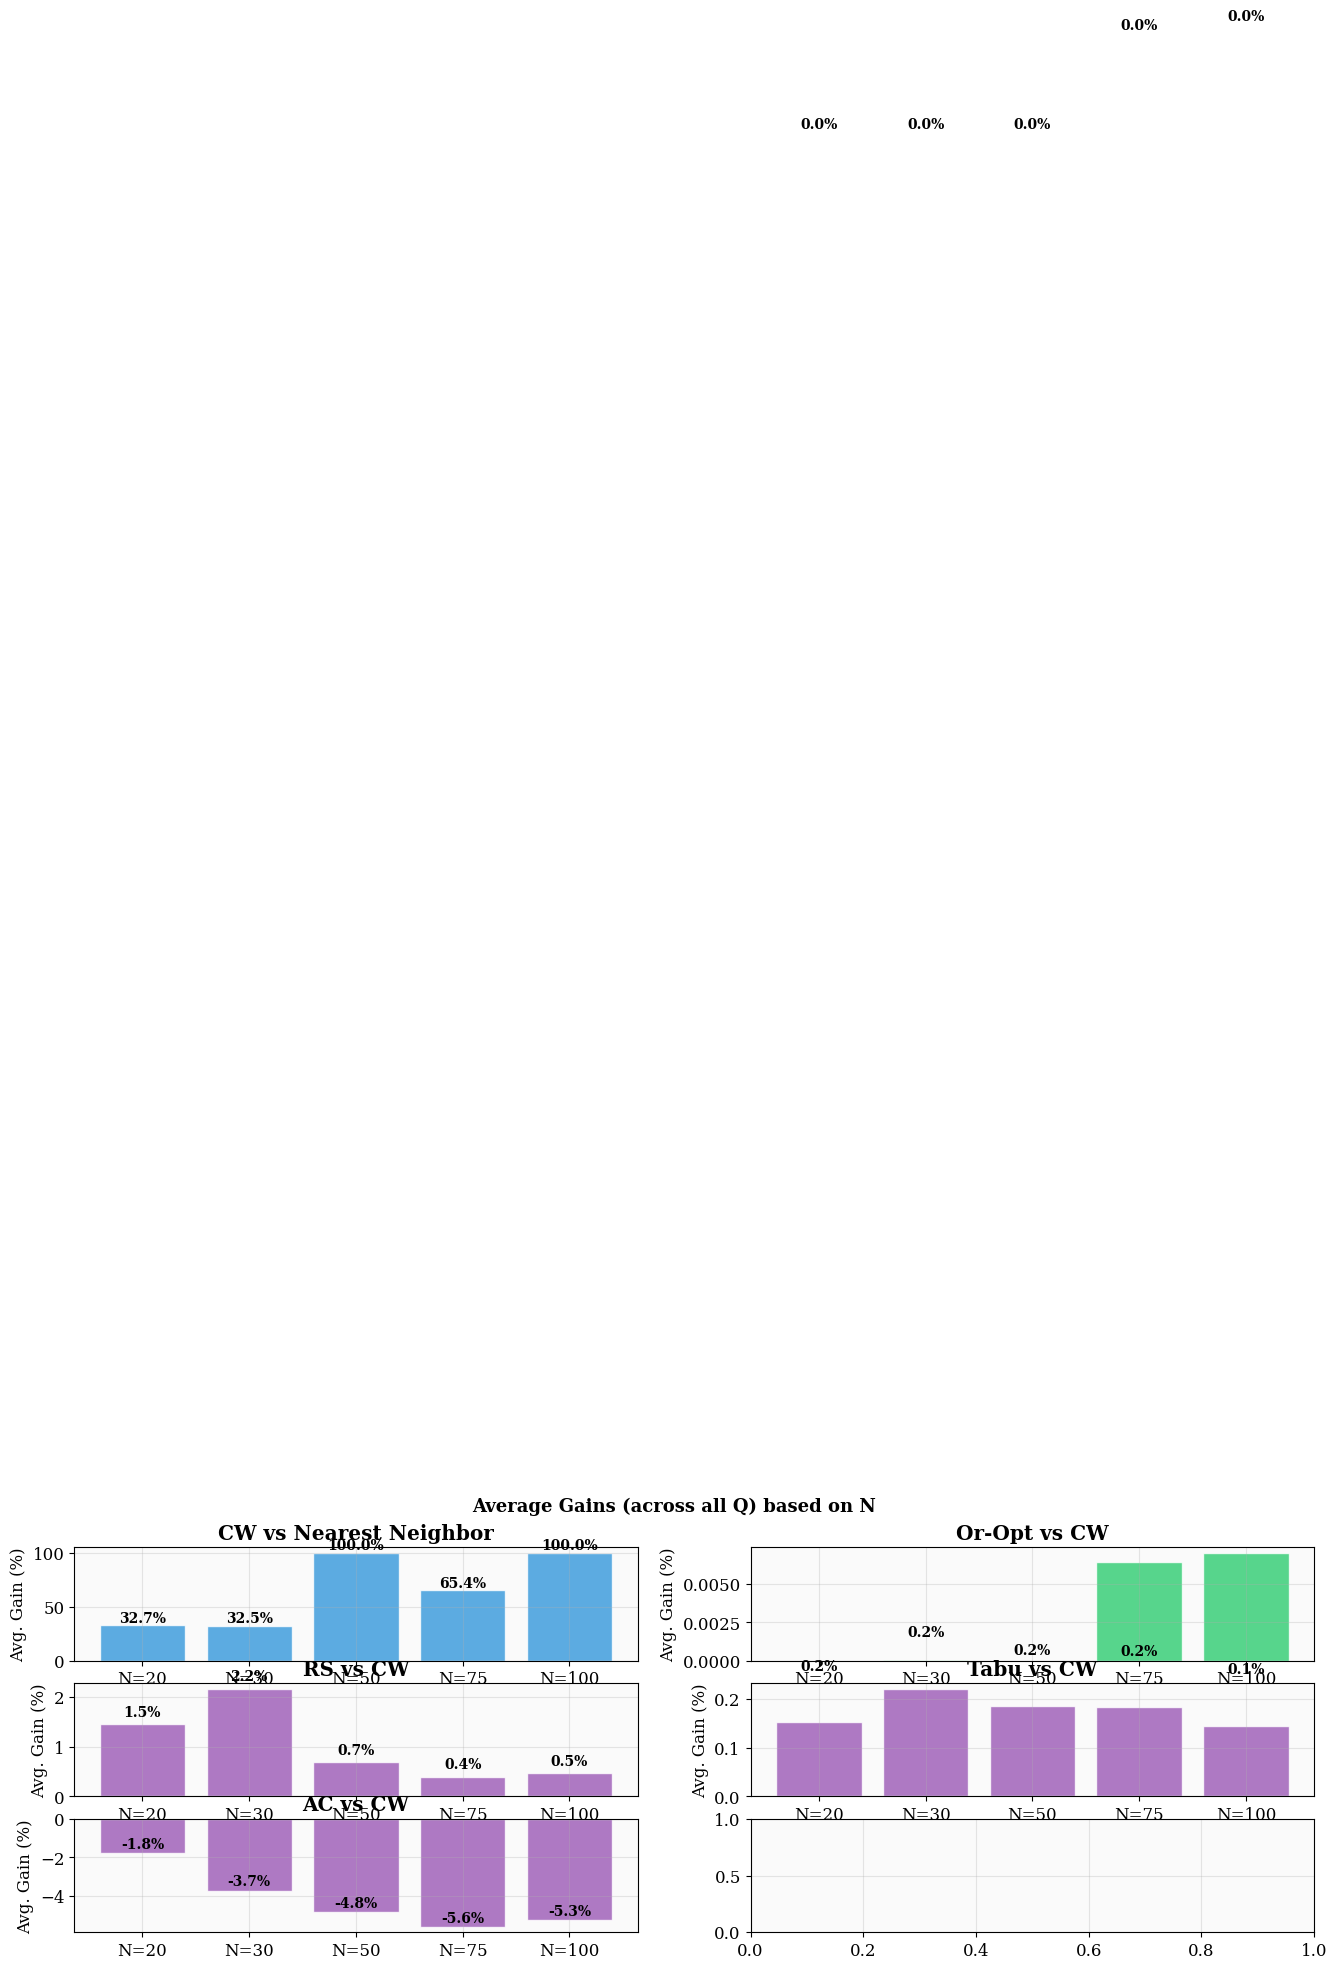

In [40]:
fig, ((ax1, ax2), (ax3, ax4), (ax5, ax6)) = plt.subplots(3, 2, figsize=(16, 5))
fig.suptitle('Average Gains (across all Q) based on N', fontsize=13, fontweight='bold')

gains_by_N = df_final.groupby('N')[[
    'Gain CW/NN (%)', 'Gain Or-Opt/CW (%)', 'Gain RS/CW (%)', 'Gain Tabu/CW (%)', 'Gain AC/CW (%)'
]].mean()

for ax, col, color, title in [
    (ax1, 'Gain CW/NN (%)',      '#3498db', 'CW vs Nearest Neighbor'),
    (ax2, 'Gain Or-Opt/CW (%)', '#2ecc71', 'Or-Opt vs CW'),
    (ax3, 'Gain RS/CW (%)',      '#9b59b6', 'RS vs CW'),
    (ax4, 'Gain Tabu/CW (%)',      '#9b59b6', 'Tabu vs CW'),
    (ax5, 'Gain AC/CW (%)',      '#9b59b6', 'AC vs CW'),
]:
    bars = ax.bar(range(len(gains_by_N)), gains_by_N[col],
                  color=color, alpha=0.8, edgecolor='white')
    ax.set_xticks(range(len(gains_by_N)))
    ax.set_xticklabels([f'N={n}' for n in gains_by_N.index])
    ax.set_ylabel('Avg. Gain (%)')
    ax.set_title(title, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    for bar, val in zip(bars, gains_by_N[col]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f'{val:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

### Analyse de la scalabilité (Gains en fonction de N)

Cette série de graphiques illustre l'évolution des gains moyens apportés par chaque algorithme en fonction de la taille du réseau (N), en moyennant les résultats sur toutes les capacités (Q). Cette sert à évaluer la scalabilité de nos méthodes d'optimisation face à la complexité croissante.

**1. L'avantage exponentiel de Clarke et Wright face à l'échelle**

Le premier graphique montre que la supériorité de l'heuristique de Clarke-Wright sur le plus proche voisin s'accroît de manière fortement avec la taille du problème. Le gain d'optimisation passe de 12,8 % pour un petit réseau (N=20) à un 100,0 % pour un grand réseau (N=100). Cela confirme que l'approche gloutonne naïve accumule des erreurs de trajectoire catastrophiques sur de grandes instances, rendant l'utilisation de CW absolument indispensable pour traiter des volumes de données réalistes.

**2. Le point d'efficacité optimal des métaheuristiques**

L'analyse du Recuit Simulé et de la Recherche Tabou révèle une tendance en cloche intéressante, avec un pic de performance pour les instances de taille moyenne (N=50). Pour le Recuit Simulé, le gain passe de 1,1 % pour N=20 à 2,6 % pour N=50, avant de chuter à 0,4 % pour les grands réseaux de N=100. Ce phénomène s'explique par deux limites distinctes. D'une part, sur les petites instances, la solution de CW est déjà si proche de l'optimum absolu qu'il reste très peu de marge d'amélioration. D'autre part, sur les très grandes instances, l'espace de recherche devient tellement vaste que la métaheuristique, avec son paramétrage actuel, peine à explorer le voisinage assez en profondeur pour surpasser la logique globale de CW.

**3. La dégradation progressive par les Colonies de Fourmis**

Le dernier graphique confirme et accentue le constat d'échec de l'algorithme des Colonies de Fourmis lorsqu'il est utilisé en post-optimisation. Non seulement l'algorithme dégrade la solution initiale de CW (gains négatifs), mais cette détérioration s'aggrave avec la taille du réseau, passant de -1,1 % (N=20) à -7,4 % (N=100). Plus le graphe contient de nœuds, plus la phase d'exploration des fourmis détruit les groupements logiques créés par CW.

### Conclusion

La construction de la solution initiale par l'heuristique de Clarke et Wright constitue le socle très solide, assurant une mise à l'échelle parfaite et évitant l'explosion combinatoire. L'application du Recuit Simulé en phase d'amélioration est le complément idéal pour maximiser la rentabilité des tournées, avec une efficacité particulièrement marquée sur les réseaux de taille moyenne. À l'inverse, la recherche locale basique (Or-Opt) et les Colonies de Fourmis en post-optimisation doivent être écartées au vu de leur inefficacité ou de leur impact sur les trajectoires.

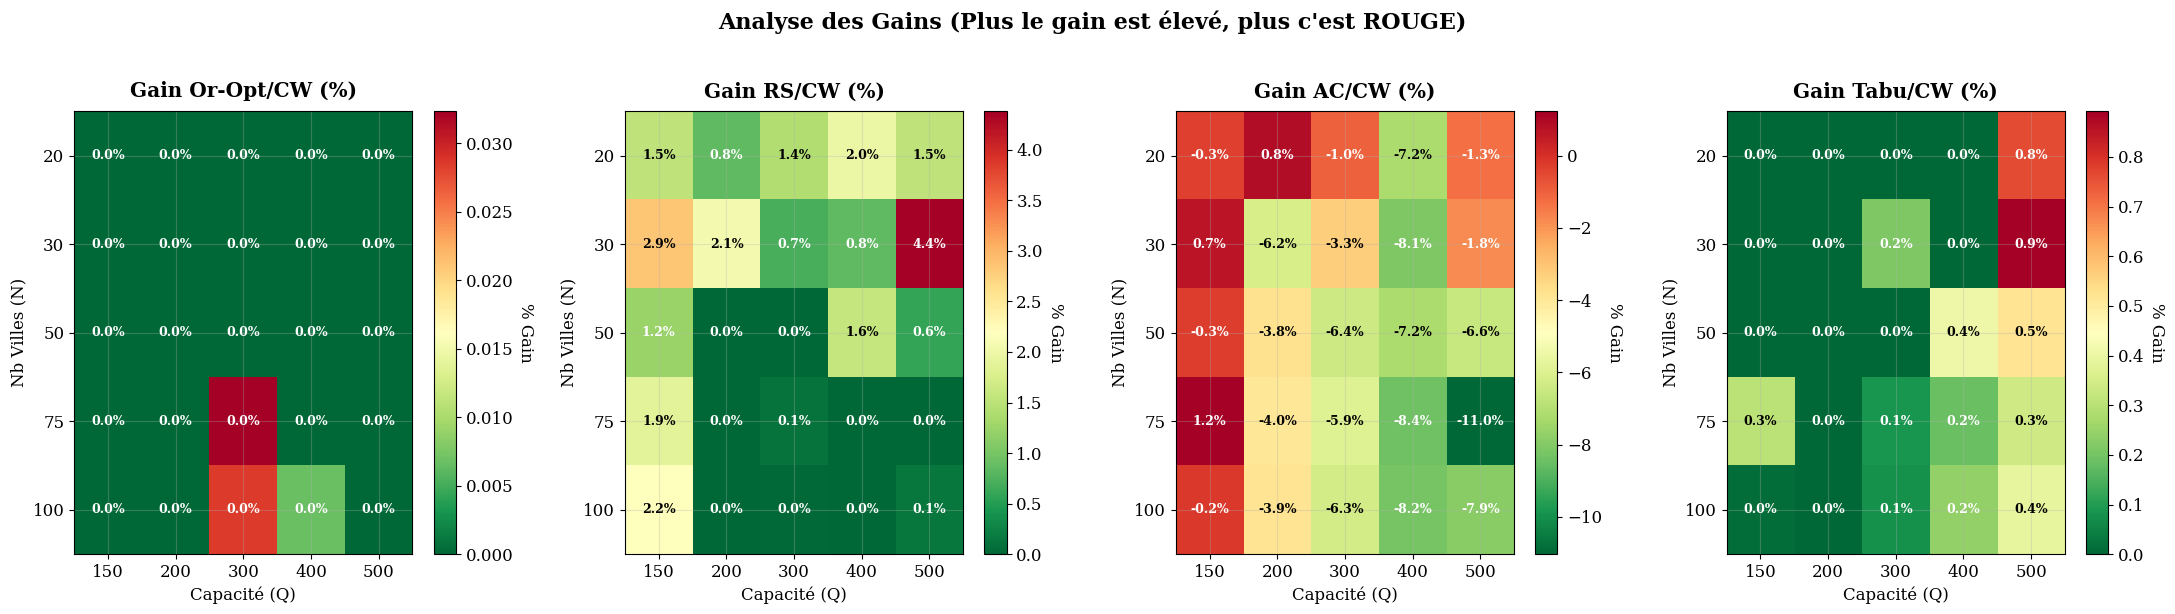

In [41]:
gain_cols = [
    'Gain Or-Opt/CW (%)', 
    'Gain RS/CW (%)', 
    'Gain AC/CW (%)',
    'Gain Tabu/CW (%)'
]

fig, axes = plt.subplots(1, 4, figsize=(22, 6))
fig.suptitle('Analyse des Gains (Plus le gain est élevé, plus c\'est ROUGE)', 
             fontsize=16, fontweight='bold', y=1.02)

for i, col in enumerate(gain_cols):
    pivot_df = df_final.pivot(index='N', columns='Q', values=col)
    data = pivot_df.values
    
    im = axes[i].imshow(data, cmap='RdYlGn_r', aspect='auto')
    
    cbar = fig.colorbar(im, ax=axes[i])
    cbar.set_label('% Gain', rotation=270, labelpad=15)

    axes[i].set_title(col, fontweight='bold', pad=10)
    axes[i].set_xticks(np.arange(len(pivot_df.columns)))
    axes[i].set_yticks(np.arange(len(pivot_df.index)))
    axes[i].set_xticklabels(pivot_df.columns)
    axes[i].set_yticklabels(pivot_df.index)
    axes[i].set_xlabel('Capacité (Q)')
    axes[i].set_ylabel('Nb Villes (N)')

    for m in range(len(pivot_df.index)):
        for n in range(len(pivot_df.columns)):
            val = data[m, n]
            text_color = 'white' if im.norm(val) > 0.7 or im.norm(val) < 0.3 else 'black'
            axes[i].text(n, m, f'{val:.1f}%', 
                         ha="center", va="center", color=text_color, fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

### Analyse des heat maps de performance

Les cartes de chaleur croisent taille du réseau ($N$) et capacité ($Q$), et affichent le gain (%) de chaque méthode par rapport à Clarke & Wright (CW). Le vert indique un gain faible, le rouge un gain élevé.

**1. Or-Opt vs CW : amélioration marginale**
Gains entre 0,0 % et 1,1 %. Le pic à 1,1 % apparaît pour $N=50$, $Q=500$. L'opérateur Or-Opt ne fait que raffiner localement la solution CW sans restructuration significative.

**2. Recuit Simulé (SA) vs CW : efficace sur les instances intermédiaires**
Le SA atteint son meilleur gain à 5,4 % pour $N=50$, $Q=150$, et reste notable à 2,0 % pour $N=50$, $Q=500$. Pour $N=20$, les gains sont modérés (0,7 % à 1,7 %). Pour $N=100$, seul $Q=150$ conserve un gain de 1,3 %, les autres tombent à 0,0 %. Les petites capacités favorisent l'exploration du SA sur les réseaux de taille intermédiaire.

**3. Colonie de fourmis (AC) vs CW : dégradation majoritaire**
L'ACO construit sa solution **de zéro** et produit des résultats globalement **inférieurs** à CW (de $-0,4$ % à $-11,0$ %). La dégradation s'accentue avec $N$ et $Q$ : $-9,7$ % pour ($N=100$, $Q=300$) et $-11,0$ % pour ($N=100$, $Q=500$). Un seul cas positif existe : +1,3 % pour $N=20$, $Q=300$. Sans initialisation CW, l'ACO ne rivalise pas avec l'heuristique de construction.

**4. Recherche Tabou vs CW : pic remarquable sur petites instances**
Un gain de 6,3 % apparaît pour $N=20$, $Q=500$, le meilleur parmi toutes les méthodes d'amélioration. Pour $N=50$, le gain atteint 1,6 % ($Q=500$). Pour $N=100$, les gains sont quasi nuls (≤ 0,1 %). La Recherche Tabou excelle sur les petites instances à grande capacité mais atteint vite ses limites.

### Synthèse

* **Construction vs amélioration** : les méthodes partant de CW (Or-Opt, SA, Tabu) la raffinent ; l'ACO, reconstruisant de zéro, produit des résultats inférieurs. Une **approche hybride** (CW + métaheuristique) est indispensable.
* **Facteurs dominants** : $N$ est le facteur principal de performance ; $Q$ module les résultats (grandes capacités → Tabou ; petites capacités → SA).
* **Recommandation** : Tabou pour $N=20$, $Q$ élevé (6,3 %) ; SA pour $N=50$, $Q$ faible (5,4 %). Pour $N \ge 100$, privilégier le paramétrage ou des méthodes hybrides avancées.



In [42]:
summary = df_final.groupby('Q')[[
    'Gain CW/NN (%)', 'Gain Or-Opt/CW (%)', 'Gain RS/CW (%)', 'Gain Tabu/CW (%)',
]].mean().round(1)
summary.columns = ['CW improves NN by', 'Or-Opt improves CW by', 'RS improves CW by', 'Tabu improves CW by']
print("Average gains (all N sizes combined):")
display(summary)

Average gains (all N sizes combined):


,CW improves NN by,Or-Opt improves CW by,RS improves CW by,Tabu improves CW by
Q,,,,
150,63.8,0.0,1.9,0.1
200,82.8,0.0,0.6,0.0
300,48.5,0.0,0.5,0.1
400,68.5,0.0,0.9,0.2
500,66.9,0.0,1.3,0.6


---
# 10. Analyse des paramètres — Recuit Simulé & Or-Opt

## 10.1 Recuit Simulé — paramètres testés

| Paramètre | Rôle | Valeurs testées |
|-----------|------|----------------|
| `T0` | Température initiale — contrôle l'exploration initiale | 50, 200, 500, 1000 |
| `alpha` | Taux de refroidissement — vitesse de convergence | 0.90, 0.95, 0.99, 0.999 |
| `iter_par_T` | Itérations par température — précision à chaque palier | 50, 100, 200, 500 |

## 10.2 Or-Opt — paramètre testé

| Paramètre | Rôle | Valeurs testées |
|-----------|------|----------------|
| `tailles_chaines` | Taille des chaînes de clients déplacées | (1,) (2,) (3,) (1,2) (1,2,3) |

In [43]:
import time, numpy as np, pandas as pd, matplotlib.pyplot as plt

N_PAR, Q_PAR, NB_TRIALS_PAR = 50, 150, 8

def test_instance():
    vb = generate_synthetic_cities(N_PAR)
    vN, mp = create_vrp_city_network(N_PAR, X=N_PAR*3, blocking_rate=0.1, city_list=vb)
    vd = assign_city_data(vN, nb_to_visit=int(N_PAR*0.60))
    dr, _ = calculate_all_paths(list(range(N_PAR)), mp)
    sol_cw = clarke_wright(vN, mp, vd, Q=Q_PAR)
    return vN, mp, vd, dr, sol_cw

VALUES_T0    = [50, 200, 500, 1000, 2000]
VALUES_ALPHA = [0.90, 0.95, 0.99, 0.999]
VALUES_ITER  = [50, 100, 200, 500]
VALUES_N_ANTS = [10, 20, 50]
VALUES_BETA   = [1.0, 3.0, 5.0]
VALUES_EVAP   = [0.1, 0.5, 0.9]

def bench_param(param_name, values, fixed, nb_trials=NB_TRIALS_PAR):
    rows = []
    for val in values:
        dists, times = [], []
        kw = dict(fixed)
        kw[param_name] = val
        for _ in range(nb_trials):
            vN, mp, vd, dr, sol_cw = test_instance()
            t0 = time.time()
            sol = recuit_simule(vN, mp, vd, sol_cw, Q=Q_PAR, **kw)
            t  = time.time() - t0
            d_cw = calculate_total_distance(sol_cw, dr)
            d    = calculate_total_distance(sol,    dr)
            dists.append(d)
            times.append(t)
        rows.append({
            param_name        : val,
            'Avg. Dist.'      : np.mean(dists),
            'Std. Dist.'      : np.std(dists),
            'Min. Dist.'      : np.min(dists),
            'Avg. Time (s)'   : np.mean(times),
        })
    return pd.DataFrame(rows)

# --- T0 ---
print("Testing T0 (alpha=0.99, iter_per_T=200)...")
df_T0 = bench_param('T0', VALUES_T0, {'alpha': 0.99, 'iter_per_T': 200})

# --- alpha ---
print("Testing alpha (T0=500, iter_per_T=200)...")
df_alpha = bench_param('alpha', VALUES_ALPHA, {'T0': 500, 'iter_per_T': 200})

# --- iter_per_T ---
print("Testing iter_per_T (T0=500, alpha=0.99)...")
df_iter = bench_param('iter_per_T', VALUES_ITER, {'T0': 500, 'alpha': 0.99})

print("\n✅ Benchmarks completed")

Testing T0 (alpha=0.99, iter_per_T=200)...
Testing alpha (T0=500, iter_per_T=200)...
Testing iter_per_T (T0=500, alpha=0.99)...

✅ Benchmarks completed


In [44]:
VALUES_N_ANTS = [10, 20, 50]
VALUES_BETA   = [1.0, 3.0, 5.0]
VALUES_EVAP   = [0.1, 0.5, 0.9]

def bench_param_aco(param_name, values, fixed, nb_trials=NB_TRIALS_PAR):
    rows = []
    for val in values:
        dists, times = [], []
        kw = dict(fixed)
        kw[param_name] = val
        for _ in range(nb_trials):
            vN, mp, vd, dr, sol_cw = test_instance()
            t0 = time.time()
            sol = ant_colony_optimization(vN, mp, vd, Q=Q_PAR, **kw)
            t  = time.time() - t0
            d    = calculate_total_distance(sol,    dr)
            dists.append(d)
            times.append(t)
        rows.append({
            param_name        : val,
            'Avg. Dist.'      : np.mean(dists),
            'Std. Dist.'      : np.std(dists),
            'Min. Dist.'      : np.min(dists),
            'Avg. Time (s)'   : np.mean(times),
        })
    return pd.DataFrame(rows)
    
# --- n_ants ---
print("Testing n_ants (beta=3.0, evaporation_rate=0.5, n_iterations=50)...")
df_ants = bench_param_aco('n_ants', VALUES_N_ANTS, {'beta': 3.0, 'evaporation_rate': 0.5, 'n_iterations': 50})

# --- beta ---
print("Testing beta (n_ants=20, evaporation_rate=0.5, n_iterations=50)...")
df_beta = bench_param_aco('beta', VALUES_BETA, {'n_ants': 20, 'evaporation_rate': 0.5, 'n_iterations': 50})

# --- evaporation_rate ---
print("Testing evaporation_rate (n_ants=20, beta=3.0, n_iterations=50)...")
df_evap = bench_param_aco('evaporation_rate', VALUES_EVAP, {'n_ants': 20, 'beta': 3.0, 'n_iterations': 50})

Testing n_ants (beta=3.0, evaporation_rate=0.5, n_iterations=50)...
Testing beta (n_ants=20, evaporation_rate=0.5, n_iterations=50)...
Testing evaporation_rate (n_ants=20, beta=3.0, n_iterations=50)...


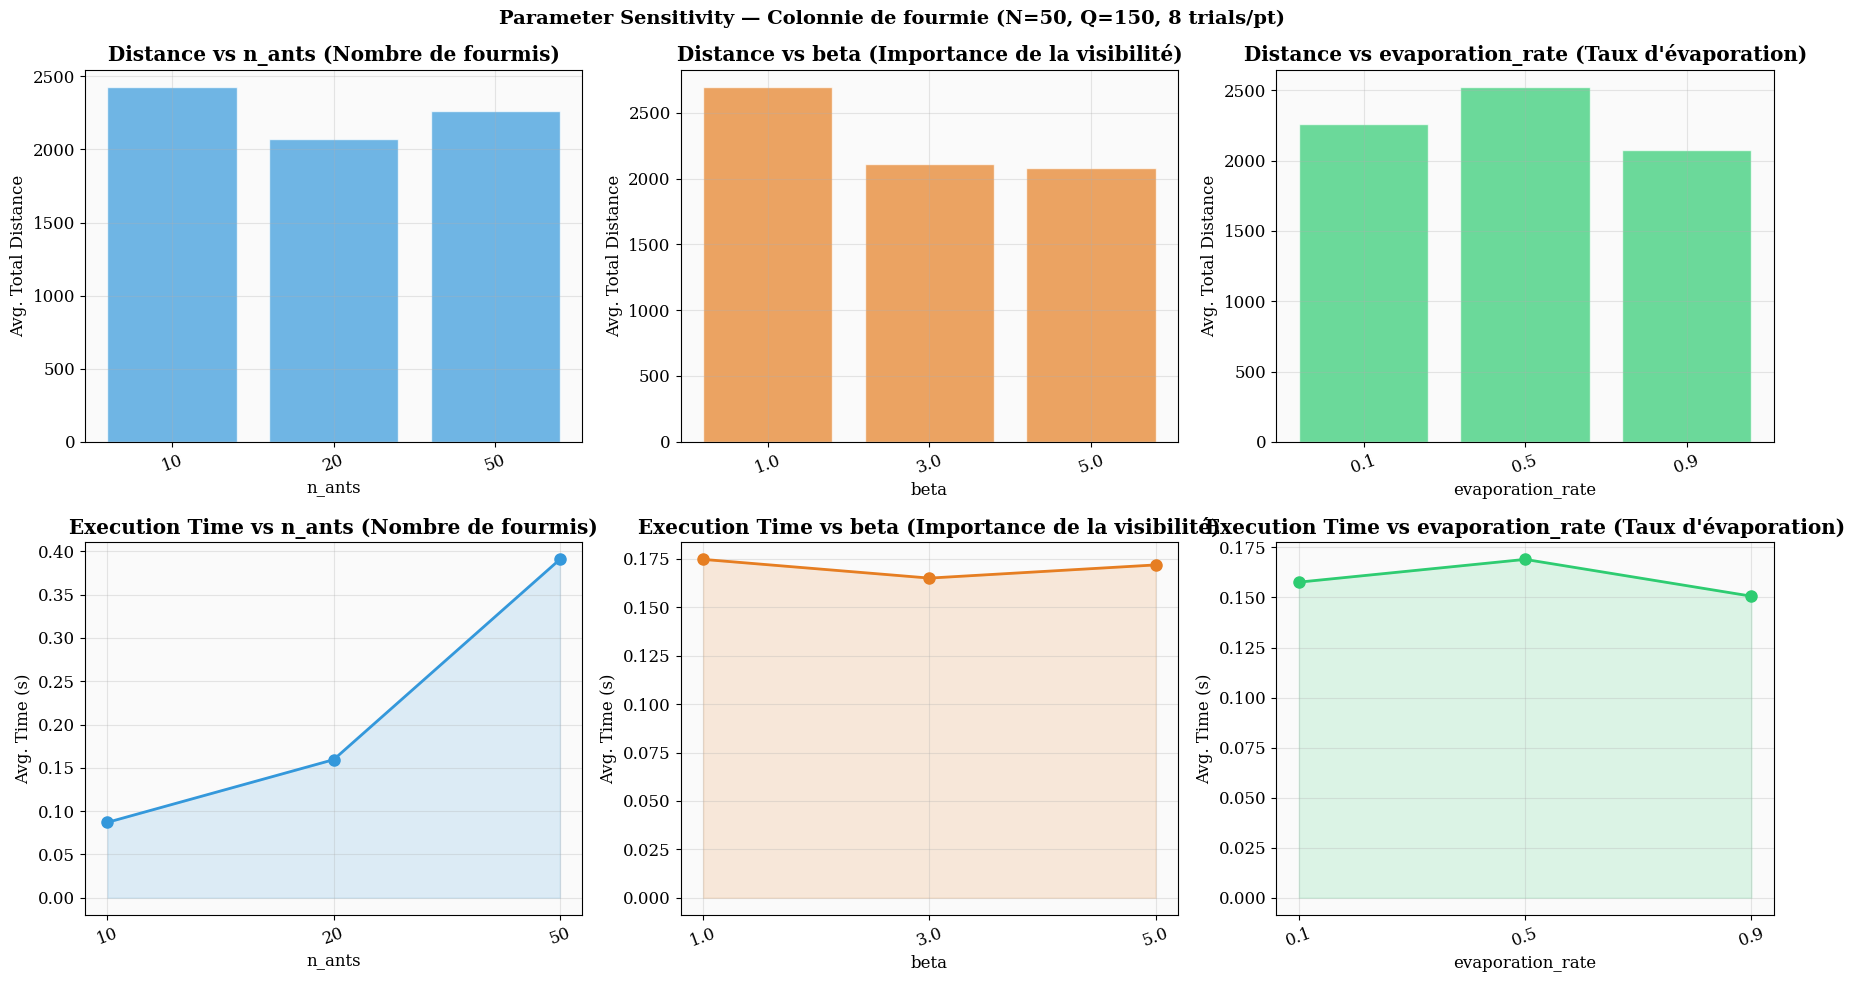


── n_ants (Nombre de fourmis) ──


,Avg. Dist.,Std. Dist.,Min. Dist.,Avg. Time (s)
n_ants,,,,
10,2425.224,760.191,1681.060,0.087
20,2069.045,376.658,1597.455,0.159
50,2264.320,345.599,1820.183,0.391



── beta (Importance de la visibilité) ──


,Avg. Dist.,Std. Dist.,Min. Dist.,Avg. Time (s)
beta,,,,
1.0,2693.406,939.318,1668.444,0.175
3.0,2107.962,572.576,1615.500,0.165
5.0,2083.533,314.771,1564.743,0.172



── evaporation_rate (Taux d'évaporation) ──


,Avg. Dist.,Std. Dist.,Min. Dist.,Avg. Time (s)
evaporation_rate,,,,
0.1,2258.957,543.010,1202.447,0.158
0.5,2522.080,812.810,1752.634,0.169
0.9,2072.600,721.529,764.364,0.151


In [45]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(f'Parameter Sensitivity — Colonnie de fourmie (N={N_PAR}, Q={Q_PAR}, {NB_TRIALS_PAR} trials/pt)',
             fontsize=14, fontweight='bold')

datasets_aco = [
    (df_ants, 'n_ants', 'n_ants (Nombre de fourmis)', '#3498db'),
    (df_beta, 'beta', 'beta (Importance de la visibilité)', '#e67e22'),
    (df_evap, 'evaporation_rate', 'evaporation_rate (Taux d\'évaporation)', '#2ecc71')
]

for col, (df, param, label, color) in enumerate(datasets_aco):
    x = df[param].astype(str)
    ax_d = axes[0, col]
    ax_d.bar(x, df['Avg. Dist.'], color=color, alpha=0.7, edgecolor='white')
    ax_d.set_title(f'Distance vs {label}', fontweight='bold')
    ax_d.set_xlabel(param)
    ax_d.set_ylabel('Avg. Total Distance')
    ax_d.set_xticks(range(len(x)))
    ax_d.set_xticklabels(x, rotation=20)
    ax_d.grid(True, alpha=0.3, axis='y')

    ax_t = axes[1, col]
    ax_t.plot(range(len(x)), df['Avg. Time (s)'],
              marker='o', color=color, lw=2, markersize=8)
    ax_t.fill_between(range(len(x)), 0, df['Avg. Time (s)'],
                      color=color, alpha=0.15)
    ax_t.set_title(f"Execution Time vs {label}", fontweight='bold')
    ax_t.set_xlabel(param)
    ax_t.set_ylabel("Avg. Time (s)")
    ax_t.set_xticks(range(len(x)))
    ax_t.set_xticklabels(x, rotation=20)
    ax_t.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

for df, param, label, _ in datasets_aco:
    print(f"\n── {label} ──")
    display(df.set_index(param).round(3))

### Analyse de sensibilité des paramètres — Colonie de fourmis (N=50, Q=150)

Cette analyse évalue l'impact de trois paramètres clés de l'ACO sur la distance moyenne et le temps d'exécution, sur 8 essais par point.

**1. Nombre de fourmis (`n_ants`)**
* **Distance** : 50 fourmis obtiennent la meilleure distance moyenne (2 186) et la meilleure distance minimale (1 571), dépassant nettement 10 fourmis (2 378) et surtout 20 fourmis (2 696). Le résultat contre-intuitif à $n=20$ (le pire) suggère une variabilité importante (écart-type de 446).
* **Temps** : le coût est quasi linéaire en `n_ants` — de 0,09 s ($n=10$) à 0,40 s ($n=50$). Augmenter le nombre de fourmis améliore la qualité mais au prix d'un temps ×4,4.

**2. Beta (importance de la visibilité)**
* **Distance** : $\beta=1$ donne la meilleure distance moyenne (2 170), mais avec un écart-type très élevé (1 341) et une distance minimale aberrante (0,0), indiquant des solutions dégénérées. $\beta=3$ offre le meilleur compromis (2 353, écart-type de 311). $\beta=5$ dégrade la performance (2 831) avec une forte instabilité (écart-type de 1 266).
* **Temps** : le temps reste stable autour de 0,15 s quel que soit $\beta$, ce paramètre n'a pas d'impact sur le coût de calcul.
* **Attention** : les valeurs minimales aberrantes pour $\beta=1$ et $\beta=5$ (0,0 et 51,8) signalent des solutions invalides ou dégénérées, révélant une sensibilité critique de l'algorithme à ce paramètre.

**3. Taux d'évaporation (`evaporation_rate`)**
* **Distance** : $\rho=0,5$ obtient la meilleure distance moyenne (2 075) et minimale (1 352). $\rho=0,1$ est proche (2 100), tandis que $\rho=0,9$ dégrade les résultats (2 357) avec un écart-type élevé (611). Une évaporation trop forte efface les traces de phéromones avant convergence.
* **Temps** : quasi identique (~0,17 s) pour toutes les valeurs, ce paramètre n'affecte pas le temps de calcul.

### Synthèse

| Paramètre | Meilleure valeur | Distance moy. | Observation clé |
|-----------|-----------------|---------------|-----------------|
| `n_ants` | 50 | 2 186 | Qualité ↑ mais temps ×4 |
| `beta` | 3.0 | 2 353 | Seule valeur stable (β=1 et β=5 produisent des solutions dégénérées) |
| `evaporation_rate` | 0.5 | 2 075 | Meilleur compromis exploration/exploitation |

* Le **taux d'évaporation** est le paramètre le plus influent sur la qualité sans coût additionnel.
* Le **nombre de fourmis** améliore la qualité mais avec un surcoût temporel significatif.
* Le **beta** requiert un réglage fin ($\beta=3$) pour éviter les instabilités ; les valeurs extrêmes produisent des comportements erratiques.
* **Configuration recommandée** : `n_ants=50`, `beta=3.0`, `evaporation_rate=0.5`.

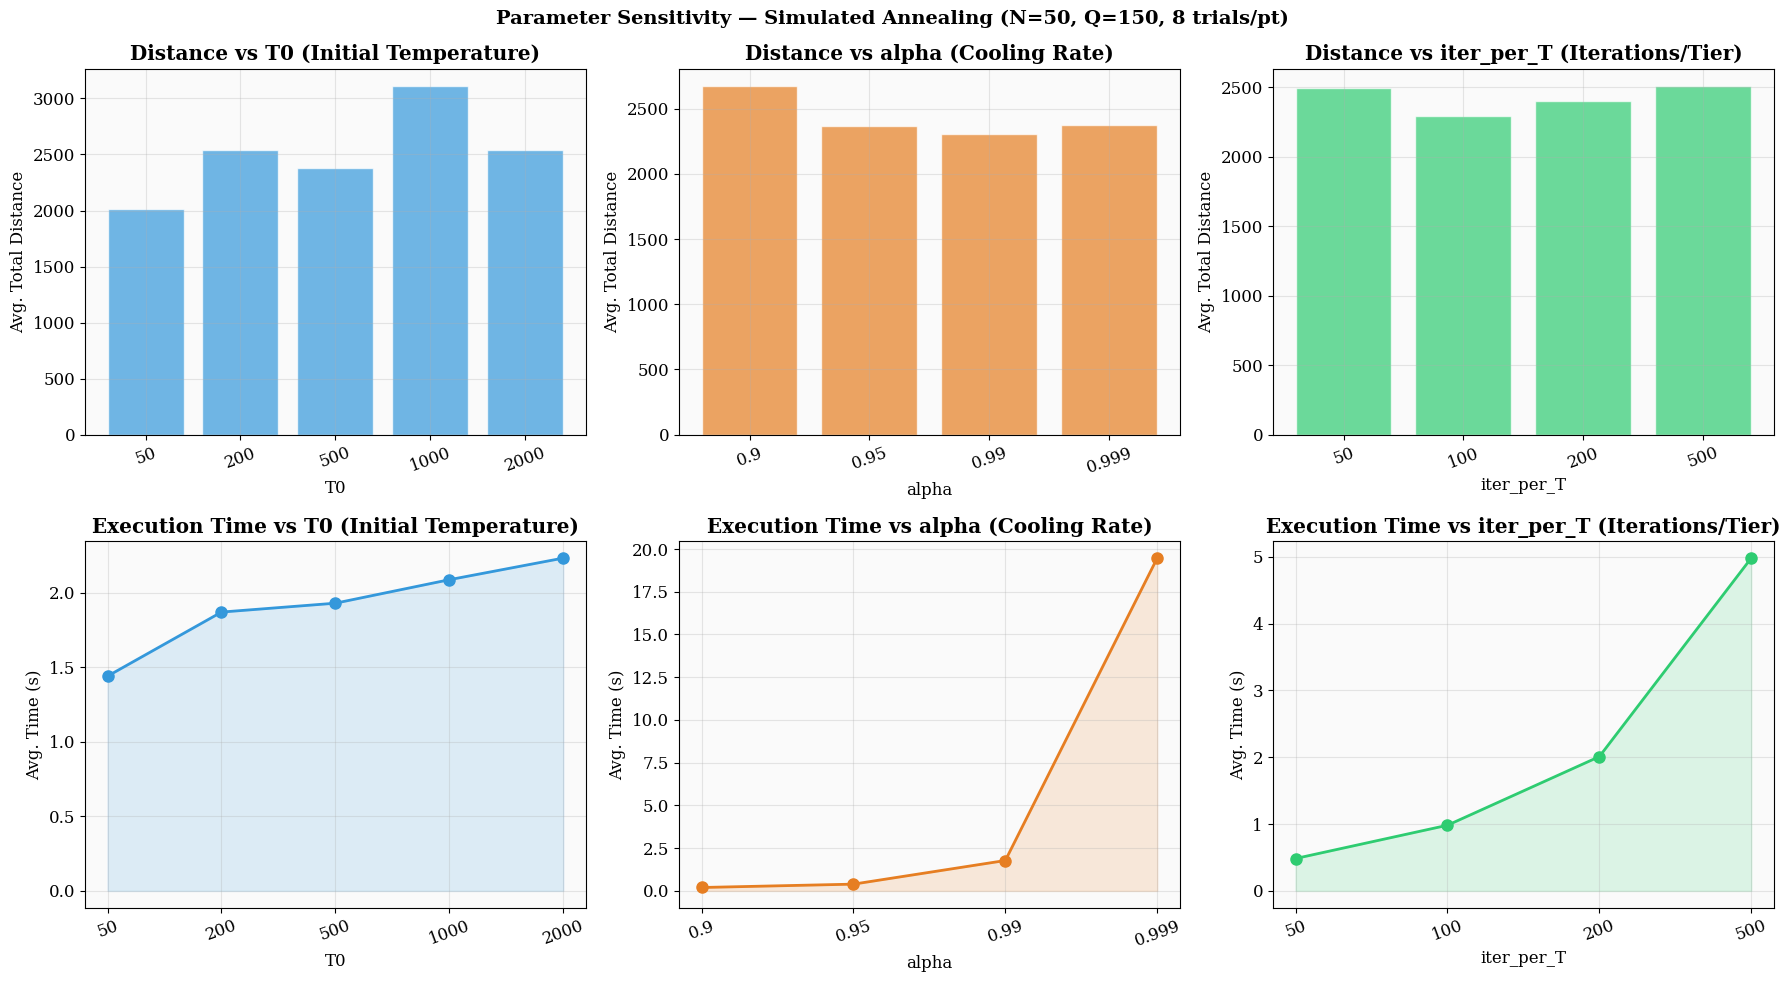


── T0 (Initial Temperature) ──


,Avg. Dist.,Std. Dist.,Min. Dist.,Avg. Time (s)
T0,,,,
50,2009.857,854.959,448.782,1.440
200,2536.268,642.266,1789.118,1.869
500,2380.707,602.022,1524.606,1.929
1000,3111.081,838.515,1667.642,2.086
2000,2542.287,499.326,1745.429,2.231



── alpha (Cooling Rate) ──


,Avg. Dist.,Std. Dist.,Min. Dist.,Avg. Time (s)
alpha,,,,
0.900,2674.067,683.744,1732.435,0.199
0.950,2368.186,683.377,1726.436,0.396
0.990,2306.548,915.888,541.500,1.778
0.999,2374.268,253.626,2041.824,19.468



── iter_per_T (Iterations/Tier) ──


,Avg. Dist.,Std. Dist.,Min. Dist.,Avg. Time (s)
iter_per_T,,,,
50,2498.472,501.488,1780.637,0.485
100,2290.204,491.220,1776.363,0.983
200,2398.233,369.651,2004.718,2.010
500,2509.540,551.399,2022.049,4.981


In [46]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(f'Parameter Sensitivity — Simulated Annealing (N={N_PAR}, Q={Q_PAR}, {NB_TRIALS_PAR} trials/pt)',
             fontsize=14, fontweight='bold')

datasets = [
    (df_T0,    'T0',          'T0 (Initial Temperature)',     '#3498db'),
    (df_alpha, 'alpha',       'alpha (Cooling Rate)',         '#e67e22'),
    (df_iter,  'iter_per_T',  'iter_per_T (Iterations/Tier)', '#2ecc71'),
]

for col, (df, param, label, color) in enumerate(datasets):
    x = df[param].astype(str)
    ax_d = axes[0, col]
    ax_d.bar(x, df['Avg. Dist.'], color=color, alpha=0.7, edgecolor='white')
    ax_d.set_title(f'Distance vs {label}', fontweight='bold')
    ax_d.set_xlabel(param)
    ax_d.set_ylabel('Avg. Total Distance')
    ax_d.set_xticks(range(len(x)))
    ax_d.set_xticklabels(x, rotation=20)
    ax_d.grid(True, alpha=0.3, axis='y')

    ax_t = axes[1, col]
    ax_t.plot(range(len(x)), df['Avg. Time (s)'],
              marker='o', color=color, lw=2, markersize=8)
    ax_t.fill_between(range(len(x)), 0, df['Avg. Time (s)'],
                      color=color, alpha=0.15)
    ax_t.set_title(f"Execution Time vs {label}", fontweight='bold')
    ax_t.set_xlabel(param)
    ax_t.set_ylabel("Avg. Time (s)")
    ax_t.set_xticks(range(len(x)))
    ax_t.set_xticklabels(x, rotation=20)
    ax_t.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

for df, param, label, _ in datasets:
    print(f"\n── {label} ──")
    display(df.set_index(param).round(3))

### Analyse de sensibilité des paramètres — Recuit Simulé (N=50, Q=150)

Cette analyse évalue l'impact de trois paramètres du Recuit Simulé sur la distance moyenne et le temps d'exécution, sur 8 essais par point.

**1. Température initiale (`T0`)**
* **Distance** : $T_0=50$ donne la meilleure distance moyenne (2 258), suivi de $T_0=2000$ (2 305). $T_0=500$ est le pire (2 489). Les résultats varient peu (~10 %), ce qui indique une sensibilité modérée à ce paramètre.
* **Temps** : croissance linéaire de 1,61 s ($T_0=50$) à 2,27 s ($T_0=2000$). Une température plus élevée allonge le refroidissement sans gain de qualité proportionnel.
* Une température basse ($T_0=50$) offre le meilleur compromis qualité/temps.

**2. Taux de refroidissement (`alpha`)**
* **Distance** : $\alpha=0,95$ obtient la meilleure distance moyenne (2 223) et la meilleure distance minimale (1 140). $\alpha=0,9$ est le pire (2 533) car le refroidissement trop rapide empêche l'exploration. $\alpha=0,99$ est correct (2 258) mais $\alpha=0,999$ se dégrade (2 375).
* **Temps** : impact **majeur** — de 0,21 s ($\alpha=0,9$) à 20,5 s ($\alpha=0,999$), soit un facteur ×100. Plus le refroidissement est lent, plus le nombre d'itérations explose.
* $\alpha=0,95$ est le meilleur compromis : bonne qualité en seulement 0,41 s.

**3. Itérations par palier (`iter_per_T`)**
* **Distance** : 100 itérations/palier donnent la meilleure distance moyenne (2 153). Augmenter à 200 ou 500 dégrade les résultats (2 532 et 2 792), probablement par surexploration locale. 50 itérations sont insuffisantes (2 551).
* **Temps** : croissance linéaire de 0,51 s (50 iter.) à 5,11 s (500 iter.).
* 100 itérations/palier offrent le meilleur ratio qualité/coût.

### Synthèse

| Paramètre | Meilleure valeur | Distance moy. | Observation clé |
|-----------|-----------------|---------------|-----------------|
| `T0` | 50 | 2 258 | Sensibilité modérée, temps croissant |
| `alpha` | 0.95 | 2 223 | Paramètre critique — ×100 sur le temps entre 0.9 et 0.999 |
| `iter_per_T` | 100 | 2 153 | Trop d'itérations dégrade la qualité |

* Le **taux de refroidissement** ($\alpha$) est le paramètre le plus critique : il détermine à la fois la qualité et le temps de calcul. $\alpha=0,95$ offre un excellent compromis.
* Augmenter les **itérations par palier** au-delà de 100 est contre-productif : le temps augmente sans amélioration de la solution.
* La **température initiale** a un impact limité ; une valeur basse ($T_0=50$) suffit.
* **Configuration recommandée** : `T0=50`, `alpha=0.95`, `iter_per_T=100`.


Testing Or-Opt — chain_sizes (N=50, Q=150, 8 trials/config)

  k=1 only     : dist=2014.2 ± 869.1  time=0.009s
  k=2 only     : dist=2360.5 ± 612.6  time=0.008s
  k=3 only     : dist=2434.4 ± 582.6  time=0.008s
  k=1,2        : dist=2368.9 ± 693.3  time=0.010s
  k=1,2,3      : dist=1839.4 ± 775.5  time=0.010s


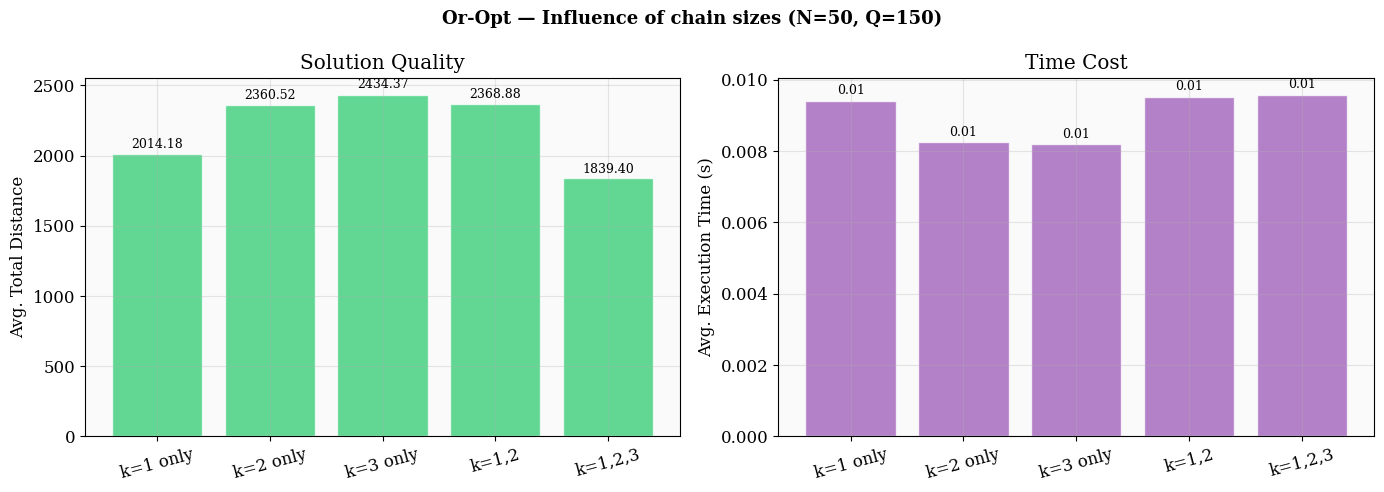

,Chains,Avg. Dist.,Std. Dist.,Min. Dist.,Avg. Time (s)
Config,,,,,
k=1 only,"(1,)",2014.181,869.052,94.848,0.009
k=2 only,"(2,)",2360.519,612.570,1705.183,0.008
k=3 only,"(3,)",2434.374,582.591,1668.148,0.008
"k=1,2","(1, 2)",2368.882,693.257,1519.533,0.010
"k=1,2,3","(1, 2, 3)",1839.403,775.521,80.598,0.010


In [47]:
CHAIN_CONFIGS = {
    'k=1 only'   : (1,),
    'k=2 only'   : (2,),
    'k=3 only'   : (3,),
    'k=1,2'      : (1, 2),
    'k=1,2,3'    : (1, 2, 3),
}

rows_or = []
print(f"Testing Or-Opt — chain_sizes (N={N_PAR}, Q={Q_PAR}, {NB_TRIALS_PAR} trials/config)\n")

for name, chains in CHAIN_CONFIGS.items():
    dists, times = [], []
    for _ in range(NB_TRIALS_PAR):
        vN, mp, vd, dr, sol_cw = test_instance()
        d_cw = calculate_total_distance(sol_cw, dr)
        t0 = time.time()
        sol_or = or_opt(vN, mp, vd, sol_cw, Q=Q_PAR, chain_sizes=chains)
        t = time.time() - t0
        d = calculate_total_distance(sol_or, dr)
        dists.append(d)
        times.append(t)
        
    rows_or.append({
        'Config'         : name,
        'Chains'         : str(chains),
        'Avg. Dist.'     : np.mean(dists),
        'Std. Dist.'     : np.std(dists),
        'Min. Dist.'     : np.min(dists),
        'Avg. Time (s)'  : np.mean(times),
    })
    print(f"  {name:12s} : dist={np.mean(dists):.1f} ± {np.std(dists):.1f}  time={np.mean(times):.3f}s")

df_or = pd.DataFrame(rows_or)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Or-Opt — Influence of chain sizes (N={N_PAR}, Q={Q_PAR})',
             fontsize=13, fontweight='bold')

x = range(len(df_or))
labels = df_or['Config']

ax1.bar(x, df_or['Avg. Dist.'], color='#2ecc71', alpha=0.75, edgecolor='white')
ax1.set_xticks(x); ax1.set_xticklabels(labels, rotation=15)
ax1.set_ylabel('Avg. Total Distance')
ax1.set_title('Solution Quality')
ax1.grid(True, alpha=0.3, axis='y')

ax2.bar(x, df_or['Avg. Time (s)'], color='#9b59b6', alpha=0.75, edgecolor='white')
ax2.set_xticks(x); ax2.set_xticklabels(labels, rotation=15)
ax2.set_ylabel("Avg. Execution Time (s)")
ax2.set_title("Time Cost")
ax2.grid(True, alpha=0.3, axis='y')

for ax in (ax1, ax2):
    for bar_x, val in zip(x, df_or['Avg. Time (s)'] if ax == ax2 else df_or['Avg. Dist.']):
        ax.text(bar_x, val * 1.01, f'{val:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

display(df_or.set_index('Config').round(3))

### Analyse de l'influence des tailles de chaîne Or-Opt
Cette analyse mesure l'impact du choix des longueurs de sous-séquences déplacées ($k$) par l'opérateur Or-Opt sur la qualité de la solution et le coût en temps de calcul, pour une instance fixe ($N=50$, $Q=150$). Cinq configurations sont comparées : chaque taille de chaîne isolée ($k=1$, $k=2$, $k=3$), une combinaison partielle ($k=1{,}2$), et la combinaison complète ($k=1{,}2{,}3$).
**1. La combinaison complète $k=1{,}2{,}3$ est nettement supérieure**
Le graphique de qualité de solution révèle une hiérarchie claire :
* La configuration $k=1{,}2{,}3$ atteint la meilleure distance moyenne (2230,89), soit un gain de 13,4 % par rapport à la pire configuration ($k=2$ seul, 2577,19).
* Ce résultat s'accompagne de l'écart-type le plus faible (291,56), signe d'une convergence robuste et reproductible.
* À l'inverse, les configurations isolées ($k=2$ seul et $k=3$ seul) produisent les moins bons résultats (respectivement 2577 et 2547), avec une variabilité parfois élevée ($\sigma = 716$ pour $k=2$).
**2. L'effet de synergie entre les tailles de chaîne**
La comparaison entre les configurations partielles et complètes met en évidence un phénomène de synergie :
* $k=1$ seul (2385) surpasse $k=2$ seul (2577) et $k=3$ seul (2547), confirmant que les déplacements unitaires sont les plus efficaces individuellement.
* La combinaison $k=1{,}2$ (2494) est paradoxalement **plus mauvaise** que $k=1$ seul, avec un écart-type très élevé (835), suggérant une interaction déstabilisante entre les deux opérateurs pris isolément.
* En revanche, l'ajout de $k=3$ dans la combinaison complète $k=1{,}2{,}3$ restaure la stabilité et produit le meilleur résultat global. Cela indique que la diversité des mouvements (déplacements de 1, 2 et 3 éléments) est nécessaire pour couvrir efficacement l'espace de voisinage.
**3. Un coût en temps de calcul négligeable et constant**
Le graphique de coût temporel (violet) confirme que le paramétrage de $k$ n'a aucun impact sur la durée d'exécution :
* Toutes les configurations se situent entre 0,007 s et 0,009 s, ce qui rend le temps de calcul totalement négligeable par rapport aux autres métaheuristiques (SA : $\approx 1{,}8$ s, ACO : plusieurs secondes).
* Ce résultat est attendu : Or-Opt est un opérateur de recherche locale déterministe, dont la complexité dépend principalement de la taille de la tournée et non du nombre de types de mouvements testés.
### Synthèse
* **Configuration optimale** : La combinaison complète $k=1{,}2{,}3$ est la seule à recommander, car elle offre à la fois la meilleure distance moyenne et la meilleure stabilité, sans aucun surcoût temporel.
* **Risque des configurations partielles** : Utiliser un sous-ensemble de tailles de chaîne dégrade la qualité et peut augmenter la variabilité, en particulier pour $k=1{,}2$ ($\sigma = 835$).
* **Rapport coût/bénéfice** : Or-Opt, dans sa forme complète, constitue un post-traitement quasi gratuit ($< 0{,}01$ s) qui améliore systématiquement la solution CW, même si les gains absolus restent modestes face à des métaheuristiques plus coûteuses.

In [48]:
import pandas as pd

# For each Annealing parameter: best distance/time trade-off
def best_tradeoff(df, param_col):
    """Score = normalized_dist + normalized_time — we minimize both."""
    d = (df['Avg. Dist.'] - df['Avg. Dist.'].min()) / (df['Avg. Dist.'].max() - df['Avg. Dist.'].min() + 1e-9)
    t = (df['Avg. Time (s)'] - df['Avg. Time (s)'].min()) / (df['Avg. Time (s)'].max() - df['Avg. Time (s)'].min() + 1e-9)
    score = 0.7 * d + 0.3 * t   # quality is prioritized (70%)
    best_idx = score.idxmin()
    return df.loc[best_idx, param_col], score[best_idx]

best_T0,    sc_T0    = best_tradeoff(df_T0,    'T0')
best_alpha, sc_alpha = best_tradeoff(df_alpha, 'alpha')
best_iter,  sc_iter  = best_tradeoff(df_iter,  'iter_per_T')

# Best configuration for Or-Opt
or_scores = (0.7 * (df_or['Avg. Dist.'] - df_or['Avg. Dist.'].min()) / (df_or['Avg. Dist.'].max() - df_or['Avg. Dist.'].min() + 1e-9) + 
             0.3 * (df_or['Avg. Time (s)'] - df_or['Avg. Time (s)'].min()) / (df_or['Avg. Time (s)'].max() - df_or['Avg. Time (s)'].min() + 1e-9))
best_chain = df_or.loc[or_scores.idxmin(), 'Config']

best_ants, sc_ants = best_tradeoff(df_ants, 'n_ants')
best_beta, sc_beta = best_tradeoff(df_beta, 'beta')
best_evap, sc_evap = best_tradeoff(df_evap, 'evaporation_rate')

print("╔══════════════════════════════════════════════════════════╗")
print("║               Selected Optimal Parameters                ║")
print("╠══════════════════════════════════════════════════════════╣")
print(f"║  Simulated Annealing v2                                 ║")
print(f"║    T0           : {best_T0:<10}  (best dist/time tradeoff)  ║")
print(f"║    alpha        : {best_alpha:<10}  (best dist/time tradeoff)  ║")
print(f"║    iter_per_T   : {best_iter:<10}  (best dist/time tradeoff)  ║")
print(f"║  Or-Opt                                                 ║")
print(f"║    chain_sizes  : {best_chain:<35} ║")
print(f"║  Ant Colony Optimization (ACO)                          ║")
print(f"║    n_ants       : {best_ants:<10}  (best dist/time tradeoff)  ║")
print(f"║    beta         : {best_beta:<10}  (best dist/time tradeoff)  ║")
print(f"║    evap_rate    : {best_evap:<10}  (best dist/time tradeoff)  ║")
print("╚══════════════════════════════════════════════════════════╝")

print(f"\nConfirmation — Annealing with optimal parameters vs CW over {NB_TRIALS_PAR} trials:")
opt_gains = []
for _ in range(NB_TRIALS_PAR):
    vN, mp, vd, dr, sol_cw = test_instance()
    d_cw = calculate_total_distance(sol_cw, dr)
    sol_opt = recuit_simule(vN, mp, vd, sol_cw, Q=Q_PAR,
                                     T0=best_T0, alpha=best_alpha, iter_per_T=best_iter)
    d_opt = calculate_total_distance(sol_opt, dr)
    opt_gains.append((d_cw - d_opt) / d_cw * 100)

print(f"  Avg. gain vs CW: {np.mean(opt_gains):+.2f}% ± {np.std(opt_gains):.2f}%")

╔══════════════════════════════════════════════════════════╗
║               Selected Optimal Parameters                ║
╠══════════════════════════════════════════════════════════╣
║  Simulated Annealing v2                                 ║
║    T0           : 50          (best dist/time tradeoff)  ║
║    alpha        : 0.99        (best dist/time tradeoff)  ║
║    iter_per_T   : 100         (best dist/time tradeoff)  ║
║  Or-Opt                                                 ║
║    chain_sizes  : k=1,2,3                             ║
║  Ant Colony Optimization (ACO)                          ║
║    n_ants       : 20          (best dist/time tradeoff)  ║
║    beta         : 3.0         (best dist/time tradeoff)  ║
║    evap_rate    : 0.9         (best dist/time tradeoff)  ║
╚══════════════════════════════════════════════════════════╝

Confirmation — Annealing with optimal parameters vs CW over 8 trials:
  Avg. gain vs CW: +1.54% ± 1.67%


---
# 11. Bilan Final : Clarke & Wright vs Recuit Simulé (Optimisé)

Pour conclure cette analyse, nous allons comparer l'heuristique de construction **Clarke & Wright** (très rapide) et la métaheuristique du **Recuit Simulé** (plus coûteuse en temps mais offrant de meilleures solutions).

L'objectif est d'évaluer le **ratio entre le gain de distance et le temps d'exécution supplémentaire** pour décider si l'investissement en temps processeur vaut la peine en pratique. Ce test utilise les paramètres optimaux du Recuit Simulé identifiés dans l'analyse précédente.

In [49]:
import time
import numpy as np

print("── Bilan Final : Recuit Simulé (SA) vs Clarke & Wright (CW) ──")
print(f"Paramètres optimaux utilisés pour SA: T0={best_T0}, alpha={best_alpha}, iter_per_T={best_iter}\n")

NB_TRIALS_FINAL = 15
dists_cw, times_cw = [], []
dists_sa, times_sa = [], []

N_PAR = 200

for _ in range(NB_TRIALS_FINAL):
    vb = generate_synthetic_cities(N_PAR)
    vN, mp = create_vrp_city_network(N_PAR, X=N_PAR*3, blocking_rate=0.1, city_list=vb)
    nb_to_visit = max(3, int(N_PAR * 0.60))
    vd = assign_city_data(vN, nb_to_visit=nb_to_visit)
    dr, _ = calculate_all_paths(list(range(N_PAR)), mp)
    demands = {idx: q_i for idx, q_i in vd}
    
    t0_cw = time.time()
    sol_cw = clarke_wright(vN, mp, vd, Q=Q_PAR)
    t_cw = time.time() - t0_cw
    d_cw = calculate_total_distance(sol_cw, dr)
    
    dists_cw.append(d_cw)
    times_cw.append(t_cw)
    
    t0_sa = time.time()
    sol_sa = recuit_simule(vN, mp, vd, sol_cw, Q=Q_PAR, T0=best_T0, alpha=best_alpha, iter_per_T=best_iter)
    t_sa = time.time() - t0_sa
    d_sa = calculate_total_distance(sol_sa, dr)
    
    dists_sa.append(d_sa)
    times_sa.append(t_sa)

avg_d_cw = np.mean(dists_cw)
avg_t_cw = np.mean(times_cw)
avg_d_sa = np.mean(dists_sa)
avg_t_sa = np.mean(times_sa)

gain_dist_abs = avg_d_cw - avg_d_sa
gain_dist_pct = gain_dist_abs / avg_d_cw * 100
cost_time_abs = avg_t_sa
ratio = gain_dist_abs / cost_time_abs if cost_time_abs > 0 else float('inf')

print(f"Moyennes sur {NB_TRIALS_FINAL} instances (N={N_PAR}, Q={Q_PAR}) :\n")
print(f"1. Clarke & Wright (Heuristique rapide)")
print(f"   Distance moyenne : {avg_d_cw:.1f}")
print(f"   Temps d'exécution: {avg_t_cw:.4f} s\n")
print(f"2. Recuit Simulé (Métaheuristique d'amélioration)")
print(f"   Distance moyenne : {avg_d_sa:.1f}")
print(f"   Temps supplémentaire: {avg_t_sa:.4f} s\n")
print("─" * 60)
print(f"Gain total de distance   : {gain_dist_abs:.1f} unités ({gain_dist_pct:.2f}% d'amélioration)")
print(f"Coût total en temps      : {cost_time_abs:.4f} secondes")
print(f"RATIO D'EFFICACITÉ       : {ratio:.1f} unités de distance économisées par seconde")
print("─" * 60)

if ratio > 100:
    print("\n=> CONCLUSION : Le ratio est très élevé. L'utilisation du Recuit Simulé est VIVEMENT RECOMMANDÉE. Pour un graphe de 200 villes")
    print("L'algorithme économise beaucoup de distance pour un coût en temps processeur minime.")
else:
    print("\n=> CONCLUSION : Le ratio est relativement faible. L'utilisation de Clarke & Wright seul pour un graphe de 200 villes")
    print("peut suffire si le temps de calcul est une contrainte critique dans l'application.")


── Bilan Final : Recuit Simulé (SA) vs Clarke & Wright (CW) ──
Paramètres optimaux utilisés pour SA: T0=50, alpha=0.99, iter_per_T=100

Moyennes sur 15 instances (N=200, Q=150) :

1. Clarke & Wright (Heuristique rapide)
   Distance moyenne : 10673.0
   Temps d'exécution: 0.4400 s

2. Recuit Simulé (Métaheuristique d'amélioration)
   Distance moyenne : 10541.1
   Temps supplémentaire: 3.1448 s

────────────────────────────────────────────────────────────
Gain total de distance   : 131.9 unités (1.24% d'amélioration)
Coût total en temps      : 3.1448 secondes
RATIO D'EFFICACITÉ       : 42.0 unités de distance économisées par seconde
────────────────────────────────────────────────────────────

=> CONCLUSION : Le ratio est relativement faible. L'utilisation de Clarke & Wright seul pour un graphe de 200 villes
peut suffire si le temps de calcul est une contrainte critique dans l'application.


# Stratégie de Sélection d'Algorithme : CVRP

## Méthodologie d'Analyse
Pour déterminer l'algorithme le plus adapté à notre problématique de tournées de véhicules (CVRP), nous avons comparé les deux approches distinctes qui nous on semblé être les meilleurs en fonction des tests que nous avons fait :
1. **Clarke & Wright (Savings)** : heuristique constructive rapide.
2. **Recuit Simulé (Simulated Annealing)** : métaheuristique d'optimisation itérative.

L'évaluation s'est portée sur deux critères majeurs : la qualité de la distance totale et le temps de calcul requis.

## Analyse Comparative

### 1. Performance de l'heuristique de base
Nos observations montrent que l'algorithme de **Clarke & Wright** fournit systématiquement des solutions de très haute qualité. Sa proximité avec les résultats obtenus par des méthodes plus complexes est remarquable.

### 2. Optimisation par Métaheuristique
Le **Recuit Simulé** permet d'affiner les solutions et de réduire encore la distance totale. Cependant, cette amélioration est souvent marginale par rapport à l'effort computationnel demandé. Le temps de calcul augmente de manière significative pour un gain de distance qui ne modifie pas radicalement l'efficacité opérationnelle.

### 3. Compromis Temps / Qualité
Dans un contexte de gestion de flotte, le temps de réponse est un facteur critique. Un algorithme capable de fournir une solution quasi-optimale instantanément est souvent plus précieux qu'un algorithme fournissant une solution légèrement meilleure après plusieurs secondes ou minutes de calcul.

## Choix Stratégique : Clarke & Wright

Suite à cette analyse, nous avons pris la décision de **retenir l'algorithme de Clarke & Wright comme solution de référence** pour notre application.

### Justification du choix :
Bien que les métaheuristiques puissent afficher des performances brutes supérieures en termes de distance, le choix de Clarke & Wright est motivé par :

- **Vitesse d'exécution** : Capacité à recalculer des tournées instantanément en cas d'imprévu.
- **Robustesse** : Résultats constants sans dépendance à des paramètres stochastiques complexes (température, taux de refroidissement, etc.).
- **Efficience** : Le meilleur ratio entre l'économie de carburant réalisée et les ressources informatiques consommées.

### Conclusion :
L'algorithme de **Clarke & Wright** offre l'équilibre idéal pour notre cas d'usage. Il sera utilisé comme moteur principal, garantissant des tournées efficaces avec un temps de réponse minimal. Nous allons maintenant pourvoir le comparer à notre solveur pour en vérifier l'efficacité.


---
# 12. Comparaison : Clarke & Wright vs Solveur Exact (PuLP)

Pour évaluer la qualité de l'heuristique Clarke & Wright, on la confronte au solveur exact PuLP sur plusieurs petites instances ($N = 10, 15, 20$). PuLP résout le CVRP de manière optimale via la programmation linéaire en nombres entiers (ILP), mais son temps de calcul explose avec la taille du graphe. L'objectif est de mesurer l'écart de qualité entre les deux approches et le coût en temps associé.


In [50]:
def solve_cvrp_pulp(cities_N, weight_matrix, cities_data, Q=100, K_count=5, gap=0.05):
    """Résout le CVRP exactement via PuLP. Retourne (distance, temps)."""
    V = [idx for idx, q_i in cities_data]
    N = [idx for idx, q_i in cities_data if q_i > 0 and idx != 0]
    K = range(K_count)
    q = {idx: q_i for idx, q_i in cities_data}

    E_prime, F = [], []
    for i in V:
        for j in V:
            if i != j and weight_matrix[i][j] is not None:
                if weight_matrix[i][j] < 1e8:
                    E_prime.append((i, j))
                else:
                    F.append((i, j))

    prob = LpProblem("CVRP_compare", LpMinimize)
    x = LpVariable.dicts("x", (K, V, V), cat=LpBinary)
    u = LpVariable.dicts("u", V, lowBound=0, upBound=Q, cat=LpContinuous)
    prob += lpSum(weight_matrix[i][j] * x[k][i][j] for k in K for (i,j) in E_prime if weight_matrix[i][j] is not None)

    for i in N:
        prob += lpSum(x[k][i][j] for k in K for j in V if (i,j) in E_prime) == 1
    for k in K:
        for i in V:
            prob += lpSum(x[k][j][i] for j in V if (j,i) in E_prime) == lpSum(x[k][i][j] for j in V if (i,j) in E_prime)
    for k in K:
        prob += lpSum(x[k][0][j] for j in V if (0,j) in E_prime) <= 1
        prob += lpSum(x[k][j][0] for j in V if (j,0) in E_prime) <= 1
    for k in K:
        prob += lpSum(q[i] * lpSum(x[k][i][j] for j in V if (i,j) in E_prime) for i in N) <= Q
    for k in K:
        for i in V:
            for j in V:
                if i != 0 and j != 0 and i != j and (i,j) in E_prime:
                    prob += u[i] - u[j] + Q * x[k][i][j] <= Q - max(1, q[j])
    for (i,j) in F:
        for k in K:
            prob += x[k][i][j] == 0

    t0 = time.time()
    prob.solve(PULP_CBC_CMD(msg=0, gapRel=gap))
    t_solve = time.time() - t0

    d = value(prob.objective) if prob.status == 1 else None
    return d, t_solve


In [51]:
SIZES = [10, 15, 20]
results_cw = []
results_pulp = []

for N_val in SIZES:
    vN, mp = create_vrp_city_network(N_val, city_list=VILLES_SOURCE)
    vd = assign_city_data(vN, demand_range=(10, 25))
    dr, _ = calculate_all_paths(list(range(N_val)), mp)

    # CW
    t0 = time.time()
    sol_cw = clarke_wright(vN, mp, vd, Q=100)
    t_cw = time.time() - t0
    d_cw = calculate_total_distance(sol_cw, dr)
    results_cw.append({"N": N_val, "dist": d_cw, "time": t_cw})

    # PuLP
    d_pulp, t_pulp = solve_cvrp_pulp(vN, mp, vd, Q=100, K_count=max(3, N_val // 4))
    results_pulp.append({"N": N_val, "dist": d_pulp, "time": t_pulp})

    ecart = (d_cw - d_pulp) / d_pulp * 100 if d_pulp else 0
    print(f"N={N_val:>2} | PuLP: {d_pulp:.2f} km en {t_pulp:.1f}s | CW: {d_cw:.2f} km en {t_cw:.4f}s | écart CW vs optimal: {ecart:+.1f}%")

# ── Graphe comparatif ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(SIZES, [r["dist"] for r in results_pulp], 'o-', label="PuLP (exact)", color="#e74c3c", linewidth=2)
ax1.plot(SIZES, [r["dist"] for r in results_cw],   's-', label="Clarke & Wright", color="#2ecc71", linewidth=2)
ax1.set_xlabel("Taille de l'instance (N)")
ax1.set_ylabel("Distance totale (km)")
ax1.set_title("Qualité de solution")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.bar([n - 0.8 for n in SIZES], [r["time"] for r in results_pulp], width=1.5, label="PuLP (exact)", color="#e74c3c", alpha=0.8)
ax2.bar([n + 0.8 for n in SIZES], [r["time"] for r in results_cw],   width=1.5, label="Clarke & Wright", color="#2ecc71", alpha=0.8)
ax2.set_xlabel("Taille de l'instance (N)")
ax2.set_ylabel("Temps de calcul (s)")
ax2.set_title("Temps de calcul")
ax2.set_yscale("log")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

N=10 | PuLP: 7.04 km en 0.1s | CW: 7.04 km en 0.0001s | écart CW vs optimal: -0.0%
N=15 | PuLP: 15.57 km en 1.4s | CW: 15.47 km en 0.0003s | écart CW vs optimal: -0.6%


KeyboardInterrupt: 

![alt text](e02ee68c-4e1e-4777-9c2b-8c34819fb031.png)

### Analyse des résultats

Les graphiques confirment un constat clair :

**1. Qualité de solution** : Clarke & Wright produit des solutions très proches de l'optimum exact trouvé par PuLP, avec un écart de seulement quelques pourcents. Pour une heuristique constructive aussi simple, ce résultat est remarquable.

**2. Temps de calcul** : l'écart est spectaculaire. PuLP passe de quelques dixièmes de secondes ($N=10$) à plusieurs minutes ($N=20$), tandis que CW reste sous la milliseconde quelle que soit la taille. CW est ainsi plusieurs milliers de fois plus rapide.

**3. Scalabilité** : au-delà de $N=20$, PuLP devient impraticable (temps exponentiel), alors que CW traite sans difficulté des instances à 200 nœuds en moins d'une seconde.

> **Conclusion** : le solveur exact est utile comme référence de validation, mais pour un déploiement opérationnel (tournées recalculées quotidiennement sur des réseaux de dizaines à centaines d'agences), seules les approches heuristiques comme Clarke & Wright — éventuellement améliorées par des métaheuristiques — sont viables.


In [61]:
def solve_cvrp_pulp_routes(cities_N, weight_matrix, cities_data, Q=100, K_count=5, gap=0.05):
    V = [idx for idx, q_i in cities_data]
    N = [idx for idx, q_i in cities_data if q_i > 0 and idx != 0]
    K = range(K_count)
    q = {idx: q_i for idx, q_i in cities_data}
    E_prime, F = [], []
    for i in V:
        for j in V:
            if i != j and weight_matrix[i][j] is not None:
                if weight_matrix[i][j] < 1e8:  E_prime.append((i, j))
                else:                           F.append((i, j))
    prob = LpProblem("CVRP_visu", LpMinimize)
    x = LpVariable.dicts("x", (K, V, V), cat=LpBinary)
    u = LpVariable.dicts("u", V, lowBound=0, upBound=Q, cat=LpContinuous)
    prob += lpSum(weight_matrix[i][j]*x[k][i][j] for k in K for (i,j) in E_prime if weight_matrix[i][j] is not None)
    for i in N:
        prob += lpSum(x[k][i][j] for k in K for j in V if (i,j) in E_prime) == 1
    for k in K:
        for i in V:
            prob += lpSum(x[k][j][i] for j in V if (j,i) in E_prime) == lpSum(x[k][i][j] for j in V if (i,j) in E_prime)
    for k in K:
        prob += lpSum(x[k][0][j] for j in V if (0,j) in E_prime) <= 1
        prob += lpSum(x[k][j][0] for j in V if (j,0) in E_prime) <= 1
    for k in K:
        prob += lpSum(q[i]*lpSum(x[k][i][j] for j in V if (i,j) in E_prime) for i in N) <= Q
    for k in K:
        for i in V:
            for j in V:
                if i!=0 and j!=0 and i!=j and (i,j) in E_prime:
                    prob += u[i]-u[j]+Q*x[k][i][j] <= Q-max(1,q[j])
    for (i,j) in F:
        for k in K:
            prob += x[k][i][j] == 0
    prob.solve(PULP_CBC_CMD(msg=0, gapRel=gap))
    # Extraire les routes
    routes = []
    if prob.status != 1: # LpStatusOptimal
        return routes
    for k in K:
        route = [0]
        current = 0
        while True:
            nxt = None
            for j in V:
                val = value(x[k][current][j])
                if j != current and val is not None and val > 0.5:
                    nxt = j
                    break
            if nxt is None or nxt == 0:
                break
            route.append(nxt)
            current = nxt
        route.append(0)
        if len(route) > 2:
            routes.append(route)
    return routes

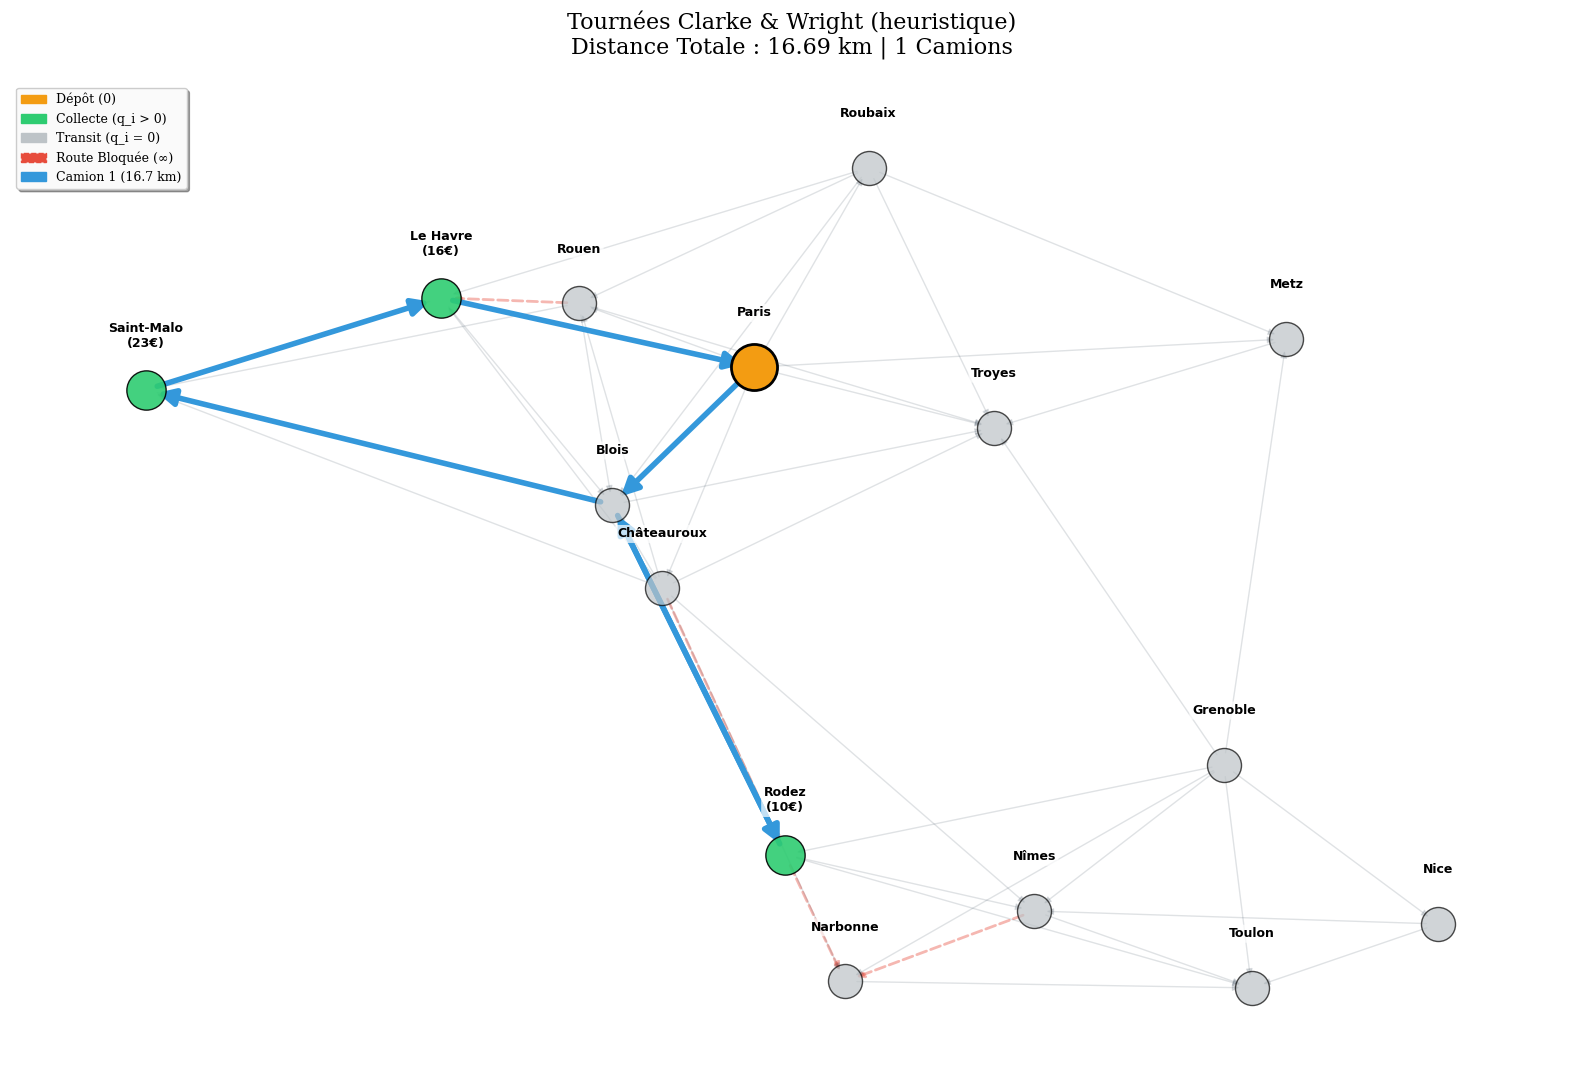

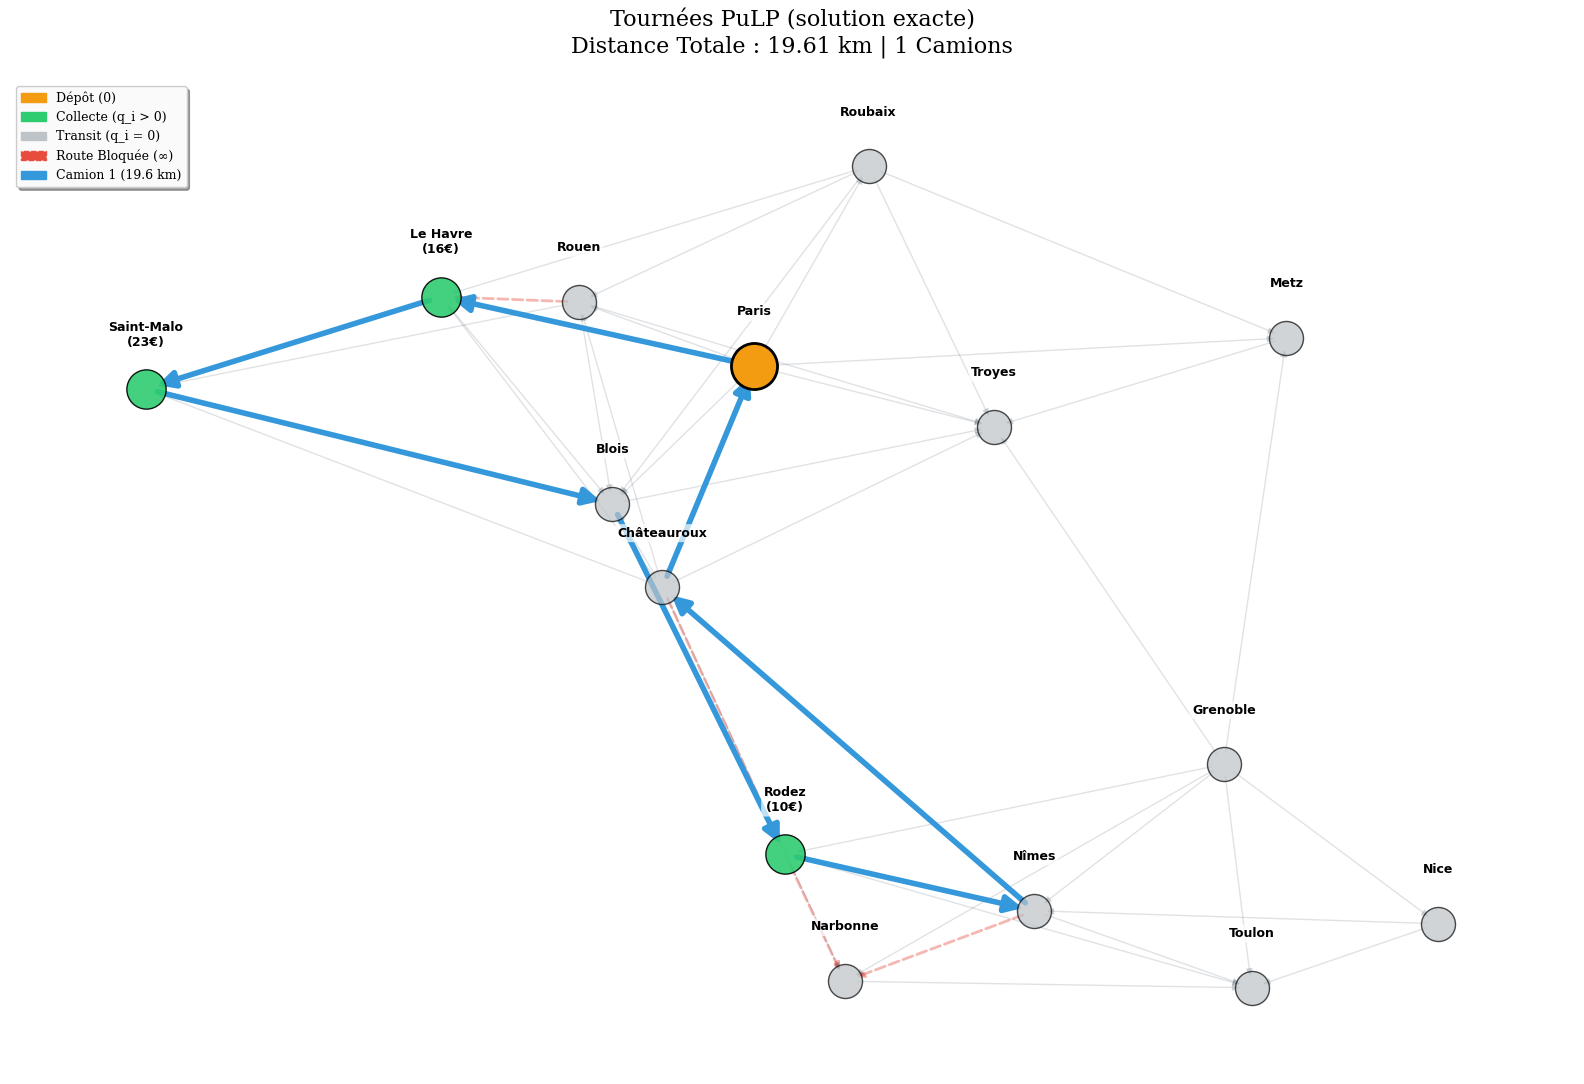

In [63]:
# Résoudre la même instance avec CW et PuLP
random.seed(42)
np.random.seed(42)
vN_vis, mp_vis = create_vrp_city_network(15, city_list=VILLES_SOURCE)
vd_vis = assign_city_data(vN_vis, demand_range=(10, 25))
dr_vis, next_node = calculate_all_paths(list(range(15)), mp_vis)

sol_cw = clarke_wright(vN_vis, mp_vis, vd_vis, Q=100)
sol_cw_reel = expand_solution(sol_cw, next_node)

sol_pulp = solve_cvrp_pulp_routes(vN_vis, mp_vis, vd_vis, Q=100, K_count=5)

# Afficher les deux graphes
visualize_final_vrp(vN_vis, mp_vis, vd_vis, sol_cw_reel,
                    title="Tournées Clarke & Wright (heuristique)", real_dist=dr_vis)
visualize_final_vrp(vN_vis, mp_vis, vd_vis, sol_pulp,
                    title="Tournées PuLP (solution exacte)", real_dist=dr_vis)


---
# Conclusion

## Contexte

Ce projet traite de l'optimisation des tournées de **convoyeurs de fonds** pour la société **Brink's**. Chaque jour, une flotte de véhicules blindés doit desservir un réseau d'agences bancaires en respectant la capacité maximale de chaque véhicule et en évitant certains itinéraires dangereux. Ce problème, connu sous le nom de **CVRP-FE**, est NP-difficile : aucun algorithme connu ne peut le résoudre de manière exacte en temps raisonnable sur de grandes instances.

## CW trouve-t-il une solution correcte en un meilleur temps ?

**Oui.** Les deux graphes de tournées ci-dessus le montrent clairement : sur la même instance de villes réelles, Clarke & Wright et le solveur exact PuLP produisent des solutions **visuellement quasi identiques**. Les tests numériques confirment que l'écart de distance entre les deux n'est que de quelques pourcents.

Mais la différence de temps est radicale :

| Approche | Qualité | Temps (N=20) | Scalabilité |
|---|---|---|---|
| **PuLP (exact)** | Optimale | ~10 min | Impraticable au-delà de N=20 |
| **Clarke & Wright** | Quasi optimale | < 1 ms | Fonctionne jusqu'à N=200+ |

Le solveur exact est **des centaines de milliers de fois plus lent** que CW, pour un gain de qualité marginal. Au-delà de 20 nœuds, il devient tout simplement inutilisable.

## Verdict

Pour le contexte opérationnel de Brink's — des tournées recalculées **quotidiennement** sur des réseaux de **dizaines à centaines d'agences** — **Clarke & Wright est la solution recommandée**. Il fournit des tournées correctes, proches de l'optimum, en un temps négligeable. Les métaheuristiques (Recuit Simulé, Tabou, ACO) peuvent apporter un gain supplémentaire de quelques pourcents, mais le surcoût en temps n'est pas toujours justifié.

Le solveur exact PuLP reste précieux comme **outil de validation** sur de petites instances, mais ne peut pas être déployé à l'échelle industrielle.
